In [2]:
import jax
from jax import numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
int4_bins = np.arange(9) - 0.5
fp4_bins = np.arange(14) * 0.5 - 0.25

In [5]:
def fp4_quant(x):
  """Abs-max quantization for fp4 with fp8 scaling factors.

  Args:
    x: A jax or numpy array with shape (block_size, num_blocks).

  Returns:
    quant: fp4 values of the same shape as the input stored in fp32 container.
    scaling_factor: fp8 values for each block stored in fp32 container. The
      values here may be zero or positive.
  """
  max_val = jnp.max(jnp.abs(x), axis=0, keepdims=True)
  raw_scale = max_val / 6.0
  scaling_factor = jnp.float32(jnp.float8_e4m3fn(raw_scale))
  scaled = jnp.where(scaling_factor != 0, x / scaling_factor, 0.0)
  quant = np.float32(jnp.float4_e2m1fn(scaled))
  return quant, scaling_factor


def nonzero_fp4_quant(x):
  """Nonzero abs-max quantization for fp4 with fp8 scaling factors.

  Args:
    x: A jax or numpy array with shape (block_size, num_blocks).

  Returns:
    quant: fp4 values of the same shape as the input stored in fp32 container.
    scaling_factor: fp8 values for each block stored in fp32 container. The
      values here should be strictly positive.
  """
  max_val = jnp.max(jnp.abs(x), axis=0, keepdims=True)
  raw_scale = max_val / 6.0
  scale_fp8 = jnp.float8_e4m3fn(raw_scale)
  min_scale = jnp.float8_e4m3fn(2**-9)
  scale_fixed = jnp.where(scale_fp8 == 0, min_scale, scale_fp8)
  scaling_factor = jnp.float32(scale_fixed)
  scaled = x / scaling_factor
  quant = np.float32(jnp.float4_e2m1fn(scaled))
  return quant, scaling_factor


def int4_quant(x):
  """Abs-max quantization for int4 with fp8 scaling factors.

  Args:
    x: A jax or numpy array with shape (block_size, num_blocks).

  Returns:
    quant: int4 values of the same shape as the input stored in fp32 container.
    scaling_factor: fp8 values for each block stored in fp32 container. The
      values here may be zero or positive.
  """
  max_val = jnp.max(jnp.abs(x), axis=0, keepdims=True)
  raw_scale = max_val / 7.0
  scaling_factor = jnp.float32(jnp.float8_e4m3fn(raw_scale))
  scaled = jnp.where(scaling_factor != 0, x / scaling_factor, 0.0)
  quant = jnp.float32(jnp.int4(jnp.clip(jnp.round(scaled), -7, 7)))
  return quant, scaling_factor


def nonzero_int4_quant(x):
  """Nonzero abs-max quantization for int4 with fp8 scaling factors.

  Args:
    x: A jax or numpy array with shape (block_size, num_blocks).

  Returns:
    quant: int4 values of the same shape as the input stored in fp32 container.
    scaling_factor: fp8 values for each block stored in fp32 container. The
      values here should be strictly positive."""
  max_val = jnp.max(jnp.abs(x), axis=0, keepdims=True)
  raw_scale = max_val / 7.0
  scale_fp8 = jnp.float8_e4m3fn(raw_scale)
  min_scale = jnp.float8_e4m3fn(2**-9)
  scale_fixed = jnp.where(scale_fp8 == 0, min_scale, scale_fp8)
  scaling_factor = jnp.float32(scale_fixed)
  scaled = x / scaling_factor
  quant = jnp.float32(jnp.int4(jnp.clip(jnp.round(scaled), -7, 7)))
  return quant, scaling_factor


def get_valid_scales():
  """Returns the valid fp8 scaling factors to use for brute-force search.

  By construction these contain all the positive fp8 values.
  """
  all_bytes = jnp.arange(256, dtype=jnp.uint8)
  all_f8 = jax.lax.bitcast_convert_type(all_bytes, jnp.float8_e4m3fn)
  all_f32 = all_f8.astype(jnp.float32)
  mask = (all_f32 > 0) & (jnp.isfinite(all_f32))
  valid = all_f32[mask]
  return jnp.unique(jnp.sort(valid))


VALID_SCALES = get_valid_scales()

def search_quant(x, quant_type):
  """Brute force search for fp8 scaling factor quantization.

  Args:
    x: A jax or numpy array with shape (block_size, num_blocks).
    quant_type: The quantized entry type. Should specify 'int4' or 'fp4'.

  Returns:
    quant: 4-bit values of the same shape as the input stored in fp32 container.
    scaling_factor: fp8 values for each block stored in fp32 container.
  """
  x_jax = jnp.array(x)
  abs_x = jnp.abs(x_jax)
  block_max = jnp.max(abs_x, axis=0)

  if quant_type == 'int4':
    max_val = 7.0
  elif quant_type == 'fp4':
    max_val = 6.0
  else:
    raise ValueError('quant_type must be "int4" or "fp4"')
  ideal_scale = block_max / max_val

  start_indices = jnp.searchsorted(VALID_SCALES, ideal_scale)
  SEARCH_DEPTH = 32
  offsets = jnp.arange(SEARCH_DEPTH) - 15  # [-15, 0, 1, ... 16]

  # Generate candidate indices for each block: shape = (num_blocks, SEARCH_DEPTH)
  candidate_indices = start_indices[:, None] + offsets[None, :]
  candidate_indices = jnp.clip(candidate_indices, 0, len(VALID_SCALES) - 1)

  # Fetch actual candidate scale values: shape = (num_blocks, SEARCH_DEPTH)
  candidates = VALID_SCALES[candidate_indices]
  # Reshape for broadcasting: shape = (1, num_blocks, SEARCH_DEPTH)
  candidates_b = candidates[None, :, :]
  # Reshape input x for broadcasting: shape = (block_size, num_blocks, 1)
  x_expanded = x_jax[:, :, None]

  scale_safe = jnp.where(candidates_b == 0, 1.0, candidates_b)
  scaled = x_expanded / scale_safe

  if quant_type == 'int4':
    quant_clipped = jnp.clip(jnp.round(scaled), -7, 7)
    val_recon = quant_clipped * scale_safe
  elif quant_type == 'fp4':
    val_f4 = scaled.astype(jnp.float4_e2m1fn)
    val_recon = val_f4.astype(jnp.float32) * scale_safe
  else:
    raise ValueError('quant_type must be "int4" or "fp4"')

  # Calculate MSE over the block dimension: shape = (num_blocks, SEARCH_DEPTH)
  mse = jnp.mean((val_recon - x_expanded) ** 2, axis=0)
  # Find the index of the scale within the SEARCH_DEPTH window that minimizes MSE
  best_idx_local = jnp.argmin(mse, axis=1)  # shape = (num_blocks,)

  # Extract the winning scale for each block: shape = (num_blocks,)
  best_scale = jnp.take_along_axis(
      candidates, best_idx_local[:, None], axis=1
  ).squeeze()

  # Perform quantization using the selected optimal scales
  final_scale_safe = jnp.where(best_scale == 0, 1.0, best_scale)
  final_scaled = x_jax / final_scale_safe
  if quant_type == 'int4':
    final_quant = jnp.clip(jnp.round(final_scaled), -7, 7)
  elif quant_type == 'fp4':
    final_quant = final_scaled.astype(jnp.float4_e2m1fn)
  else:
    raise ValueError('quant_type must be "int4" or "fp4"')

  return np.float32(final_quant), np.float32(best_scale)


def four_over_six_quant(x, nonzero_min):
  """Implements the "Four Over Six" (4/6) quantization method for E4M3 scales.

  For each block, this compares two candidate scales. max(abs(x)) maps to either
  4.0 or 6.0. It selects the scale that minimizes MSE.

  Args:
    x: A jax or numpy array with shape (block_size, num_blocks).
    nonzero_min: Whether to additionally force a nonzero scaling factor.

  Returns:
    quant: fp4 values of the same shape as the input stored in fp32 container.
    scaling_factor: fp8 values for each block stored in fp32 container.
  """
  x_jax = jnp.array(x)  # shape = (block_size, num_blocks)

  # Compute block maximums
  abs_x = jnp.abs(x_jax)
  block_max = jnp.max(abs_x, axis=0)  # shape = (num_blocks,)

  # Define the two candidate raw scales
  raw_scale_6 = block_max / 6.0
  raw_scale_4 = block_max / 4.0

  # Stack and Quantize Scales to E4M3: Shape = (2, num_blocks)
  candidates_raw = jnp.stack([raw_scale_6, raw_scale_4], axis=0)

  # Cast to fp8 and back to fp32.
  candidates = candidates_raw.astype(jnp.float8_e4m3fn).astype(jnp.float32)

  # Optionally use nonzero scaling.
  if nonzero_min:
    min_scale = 2.0**-9
    candidates = jnp.maximum(candidates, min_scale)

  # Expand x: shape = (1, block_size, num_blocks)
  x_expanded = x_jax[None, :, :]

  # Expand scales: shape = (2, 1, num_blocks)
  scales_expanded = candidates[:, None, :]

  # Quantize and Dequantize for both candidates
  val_scaled = x_expanded / scales_expanded
  val_f4 = val_scaled.astype(jnp.float4_e2m1fn)
  val_recon = val_f4.astype(jnp.float32) * scales_expanded

  # Compute MSE for each candidate: shape = (2, num_blocks)
  mse = jnp.mean((val_recon - x_expanded) ** 2, axis=1)

  # Select Best Candidate
  best_idx = jnp.argmin(mse, axis=0)  # (num_blocks,)

  # Gather best scales
  # best_idx is 0 or 1. We select from candidates (2, num_blocks)
  best_scale = jnp.take_along_axis(
      candidates, best_idx[None, :], axis=0
  ).squeeze()

  # Re-compute using the winning scale to get the final quantized tensor.
  final_scale_expanded = best_scale[None, :]  # (1, num_blocks)
  final_quant = (x_jax / final_scale_expanded).astype(jnp.float4_e2m1fn)

  return np.float32(final_quant), np.float32(best_scale)


def get_valid_scales_range(max_val):
  """Generates all valid, positive, finite values for float8_e4m3fn up to max_val."""
  # 1. Generate all possible E4M3 values
  all_bytes = jnp.arange(256, dtype=jnp.uint8)
  all_f8 = jax.lax.bitcast_convert_type(all_bytes, jnp.float8_e4m3fn)
  all_f32 = np.array(all_f8.astype(jnp.float32))

  # 2. Filter for unique, positive, finite values
  mask = (all_f32 >= 0) & (np.isfinite(all_f32))
  valid_sorted = np.unique(np.sort(all_f32[mask]))

  # 3. Clip to requested range
  return valid_sorted[valid_sorted <= max_val]


def run_error_experiment(quant_func, quant_type, title):
  """quant_type: 'int4' or 'fp4'"""
  N_PLOT_POINTS = 50000
  blocks = [4, 8, 16, 32]

  x_range = np.linspace(0.0005, 0.05, 151)
  plot_indices = [6, 45, 150]
  plot_labels_text = ["A", "B", "C"]

  MAX_SCALE = 0.05078125
  valid_scales = get_valid_scales_range(MAX_SCALE)

  min_gap = np.min(np.diff(valid_scales))
  FIXED_BAR_WIDTH = min_gap * 0.8

  right_xlim = (-0.002, MAX_SCALE * 1.05)

  if quant_type == "int4":
    hist_bins = np.arange(9) - 0.5
    left_xlim = (-0.5, 7.5)
    forbidden_zones = []
    left_title = "Absolute Quantized Values (INT4)"
  elif quant_type == "fp4":
    # Bins centered on half-steps (0.0, 0.5...)
    hist_bins = np.arange(16) * 0.5 - 0.25
    left_xlim = (-0.25, 6.75)
    forbidden_zones = [(2.25, 2.75), (3.25, 3.75), (4.25, 5.75)]
    left_title = "Absolute Quantized Values (FP4)"
  else:
    raise ValueError("quant_type must be 'int4' or 'fp4'")

  errors = {b: [] for b in blocks}

  current_plot_data = None
  label_char = None

  for dist_index, dist_scale in enumerate(x_range):

    make_plot = dist_index in plot_indices
    if make_plot:
      label_char = plot_labels_text[plot_indices.index(dist_index)]
      current_plot_data = {}

    for block_size in blocks:
      n_scalars_needed = N_PLOT_POINTS * max(blocks)

      dist = np.random.normal(scale=dist_scale, size=n_scalars_needed)
      dist_blocked = dist[: N_PLOT_POINTS * block_size].reshape(
          (block_size, N_PLOT_POINTS)
      )

      quant, scaling_factor = quant_func(dist_blocked)

      mse = np.mean((quant * scaling_factor - dist_blocked) ** 2)
      errors[block_size].append(mse)

      if make_plot:
        q_flat = np.abs(quant).reshape(-1)[:N_PLOT_POINTS]
        s_flat = np.array(scaling_factor).reshape(-1)
        current_plot_data[block_size] = (q_flat, s_flat)

    if make_plot:
      fig, axes = plt.subplots(
          len(blocks), 2, figsize=(16, 12), sharex="col", sharey="col"
      )
      colors = ["#5b9bd5", "#ff9f4b", "#70ad71", "#d65f5f"]

      max_y_left = 0
      max_y_right = 0

      for b in blocks:
        counts_l, _ = np.histogram(current_plot_data[b][0], bins=hist_bins)
        max_y_left = max(max_y_left, counts_l.max())

        _, counts_r = np.unique(current_plot_data[b][1], return_counts=True)
        if len(counts_r) > 0:
          max_y_right = max(max_y_right, counts_r.max())

      left_ylim = (0, max_y_left * 1.1)
      right_ylim = (0, max_y_right * 1.1)

      for row_idx, block_size in enumerate(blocks):
        q_data, s_data = current_plot_data[block_size]
        color = colors[row_idx]

        # Left Plot: Quantized Values (Histogram)
        ax_left = axes[row_idx, 0]
        ax_left.hist(
            q_data,
            bins=hist_bins,
            color=color,
            alpha=0.8,
            edgecolor="black",
            linewidth=0.5,
        )

        ax_left.set_xlim(left_xlim)
        ax_left.set_ylim(left_ylim)

        if forbidden_zones:
          for start, end in forbidden_zones:
            ax_left.axvspan(start, end, color="pink", alpha=0.3, hatch="//")

        if row_idx == 0:
          ax_left.set_title(left_title, fontsize=12, pad=10)
        ax_left.set_ylabel(
            f"Block {block_size}\nFrequency", fontsize=10, fontweight="bold"
        )
        ax_left.grid(True, axis="y", alpha=0.3, linestyle="--")

        # Right Plot: Scaling Factors (Bar Chart)
        ax_right = axes[row_idx, 1]

        unique_vals, counts = np.unique(s_data, return_counts=True)

        # Plot bars at exact float locations with fixed width
        ax_right.bar(
            unique_vals,
            counts,
            width=FIXED_BAR_WIDTH,
            color=color,
            alpha=0.8,
            edgecolor="black",
            linewidth=0.5,
        )

        ax_right.set_xlim(right_xlim)
        ax_right.set_ylim(right_ylim)

        if row_idx == len(blocks) - 1:
          ax_right.set_xticks(valid_scales)
          labels = [f"{v:.5g}" for v in valid_scales]
          ax_right.set_xticklabels(labels, rotation=90, fontsize=8)
        else:
          ax_right.tick_params(labelbottom=False)

        if row_idx == 0:
          ax_right.set_title(
              "Scaling Factors (E4M3 Aligned)", fontsize=12, pad=10
          )
        ax_right.grid(True, axis="y", alpha=0.3, linestyle="--")

      axes[-1, 0].set_xlabel("Quantized Value")
      axes[-1, 1].set_xlabel("Scaling Factor (E4M3)")

      fig.suptitle(
          f"Dist. Index: {dist_index} (Label {label_char}), Scale:"
          f" {dist_scale:.5f}",
          fontsize=16,
          y=0.98,
      )
      plt.tight_layout(rect=[0, 0, 1, 0.96])
      plt.show()

  plot_style = {
      "font.family": "serif",
      "axes.labelsize": 14,
      "xtick.labelsize": 12,
      "ytick.labelsize": 12,
      "legend.fontsize": 12,
      "legend.title_fontsize": 14,
      "figure.facecolor": "white",  # Forces the outer background to be white
      "axes.facecolor": "white",  # Forces the inner plot area to be white
      "savefig.facecolor": (
          "white"
      ),  # Ensures saved images also have a white background
  }

  with plt.rc_context(plot_style):
    _, ax = plt.subplots(figsize=(6, 4.5))

    colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

    for i, b in enumerate(blocks):
      ax.plot(
          x_range, errors[b], linewidth=2.5, color=colors[i], label=f"Block {b}"
      )

    # Add annotations (A, B, C) and vertical dashed drop-lines
    for i, idx in enumerate(plot_indices):
      label = plot_labels_text[i]
      x_val = x_range[idx]
      y_values_at_idx = [errors[b][idx] for b in blocks]
      max_y = max(y_values_at_idx)

      # Vertical dashed line
      ax.vlines(
          x=x_val,
          ymin=0,
          ymax=2.6e-5,
          color="gray",
          linestyle="--",
          alpha=0.6,
          zorder=1,
      )

      ax.annotate(
          label,
          xy=(x_val, max_y),
          xytext=(0, 5),  # 5 points vertical offset
          textcoords="offset points",
          ha="center",
          va="bottom",
          fontsize=16,
      )

    ax.set_xlabel(r"Distribution Scale ($\sigma$)")
    ax.set_ylabel("MSE")

    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax.yaxis.get_offset_text().set_fontsize(12)

    ax.grid(True, linestyle="--", alpha=0.4, color="gray", zorder=0)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.2)
    ax.spines["bottom"].set_linewidth(1.2)

    ax.legend(title="Block Size", loc="upper left", frameon=False)

    plt.tight_layout()
    plt.title(title)
    plt.show()

  return pd.DataFrame(errors)

# FP4

## E4M3 abs max

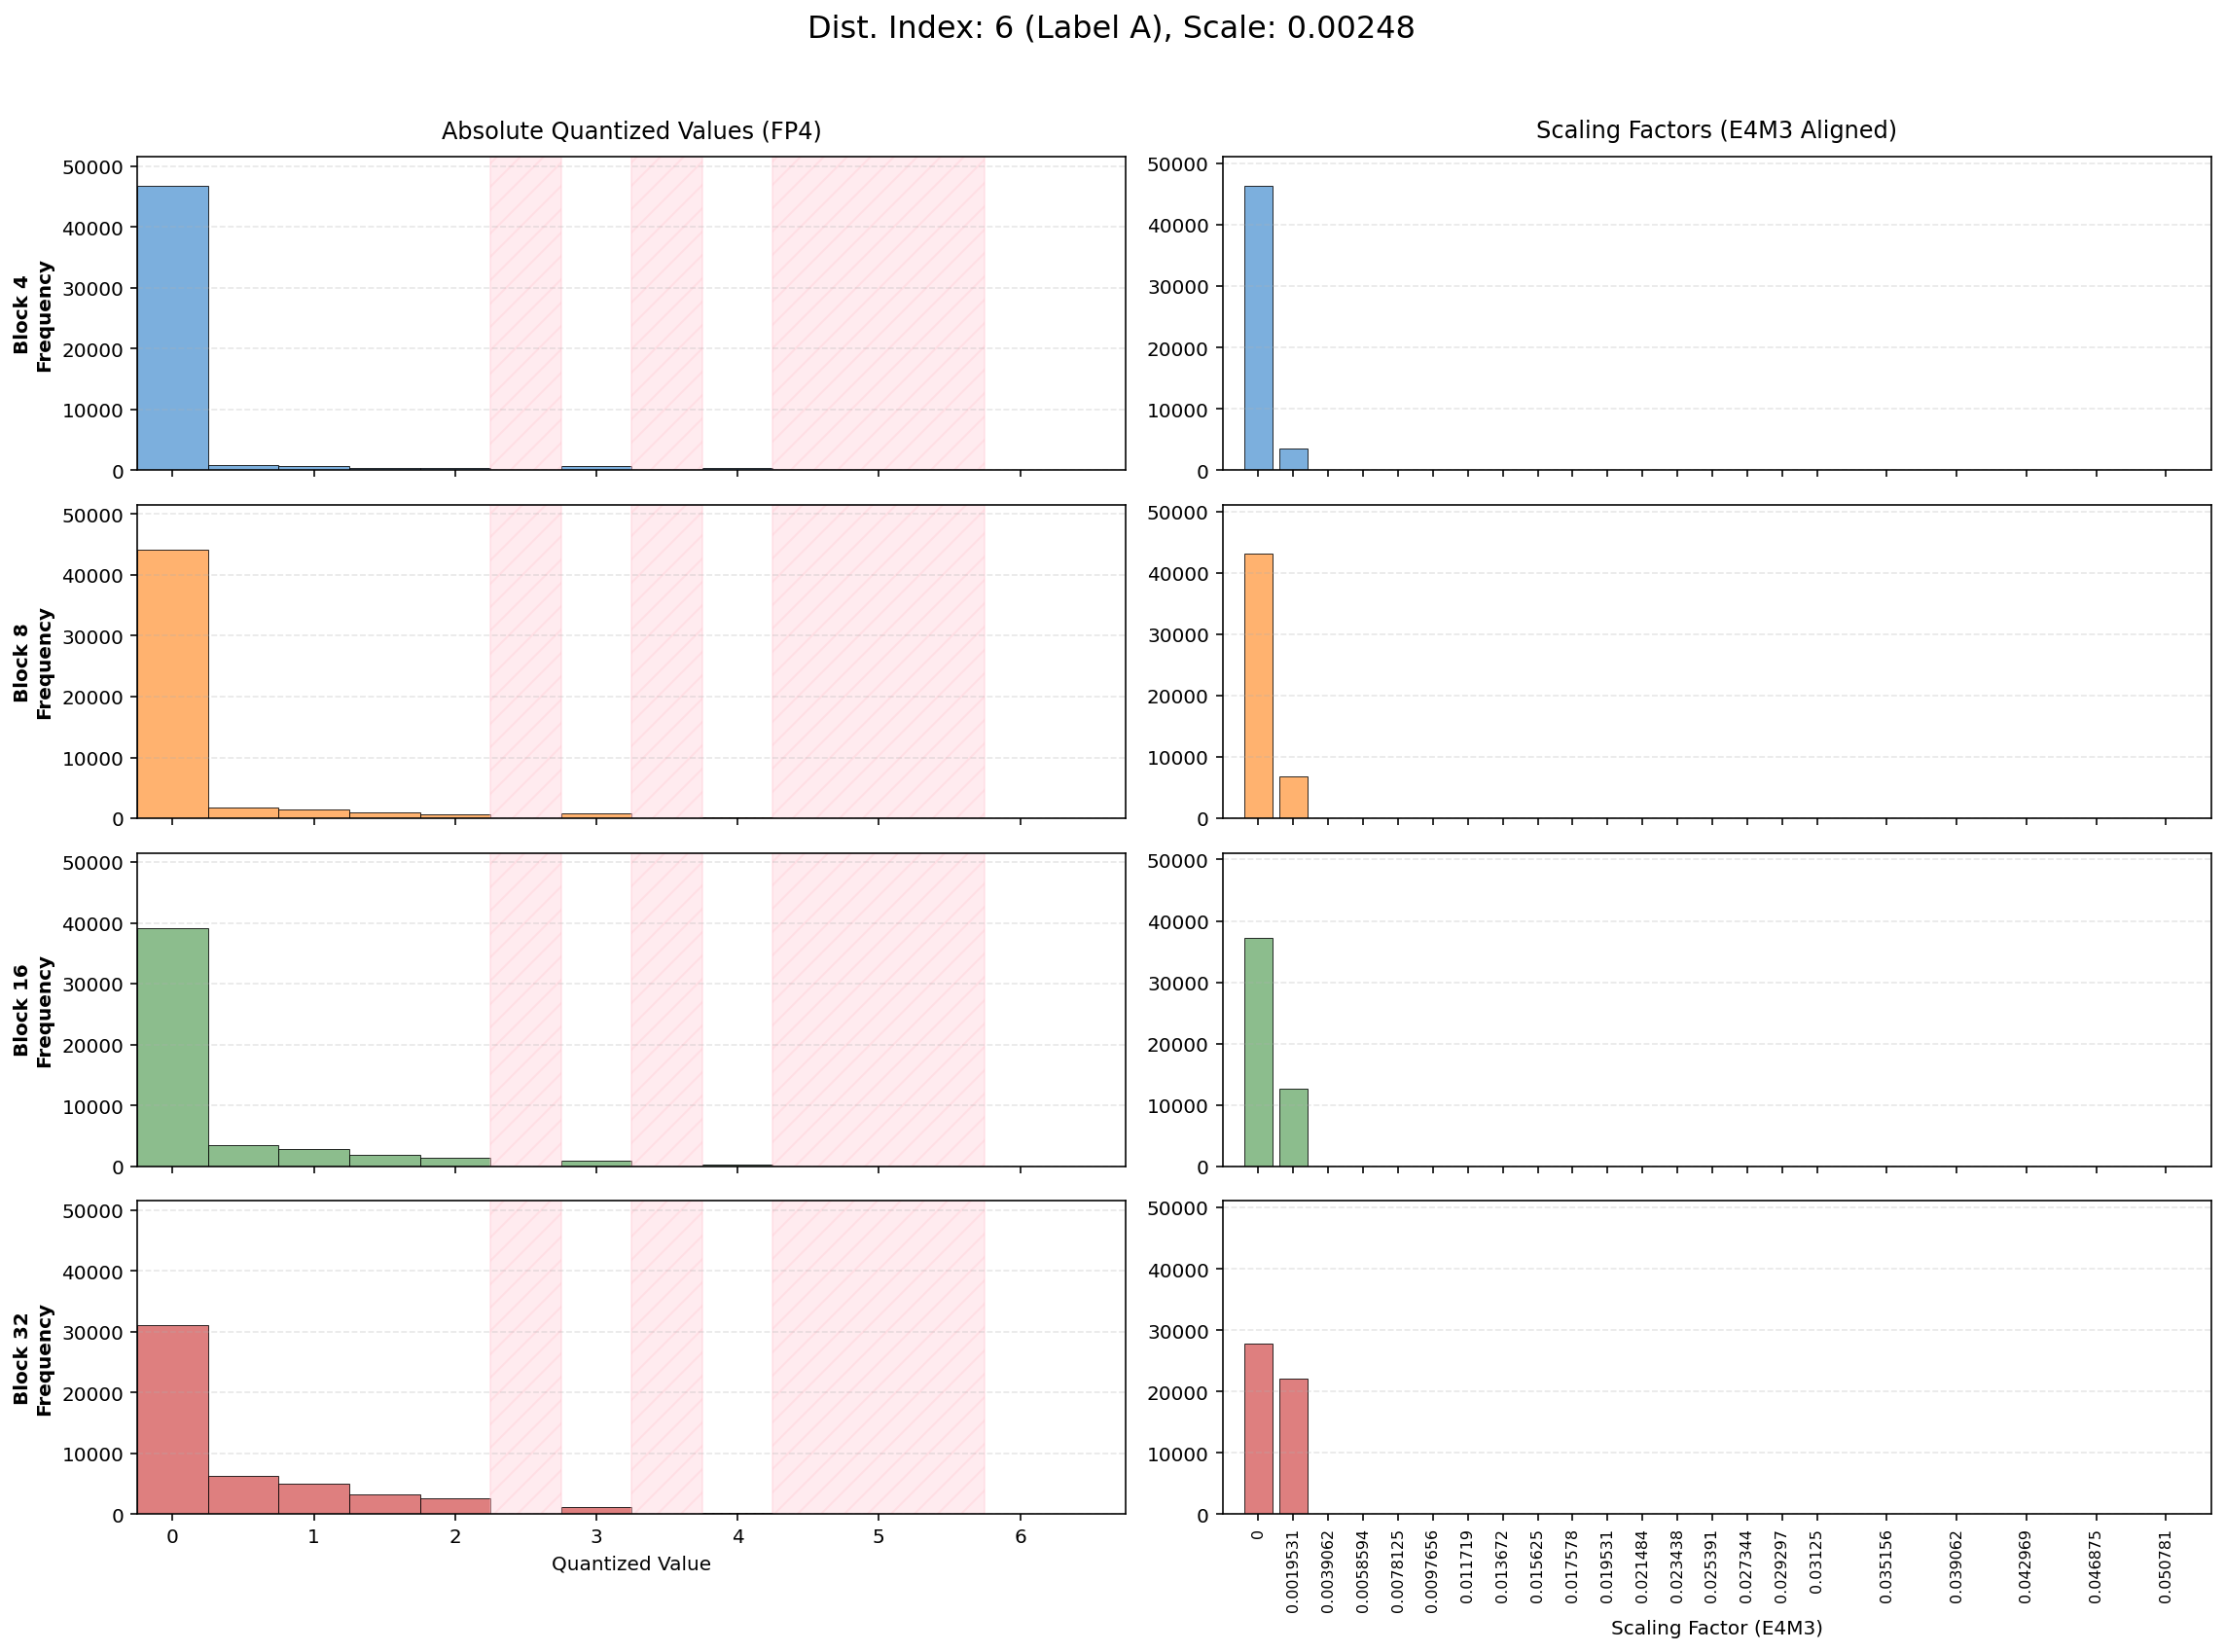

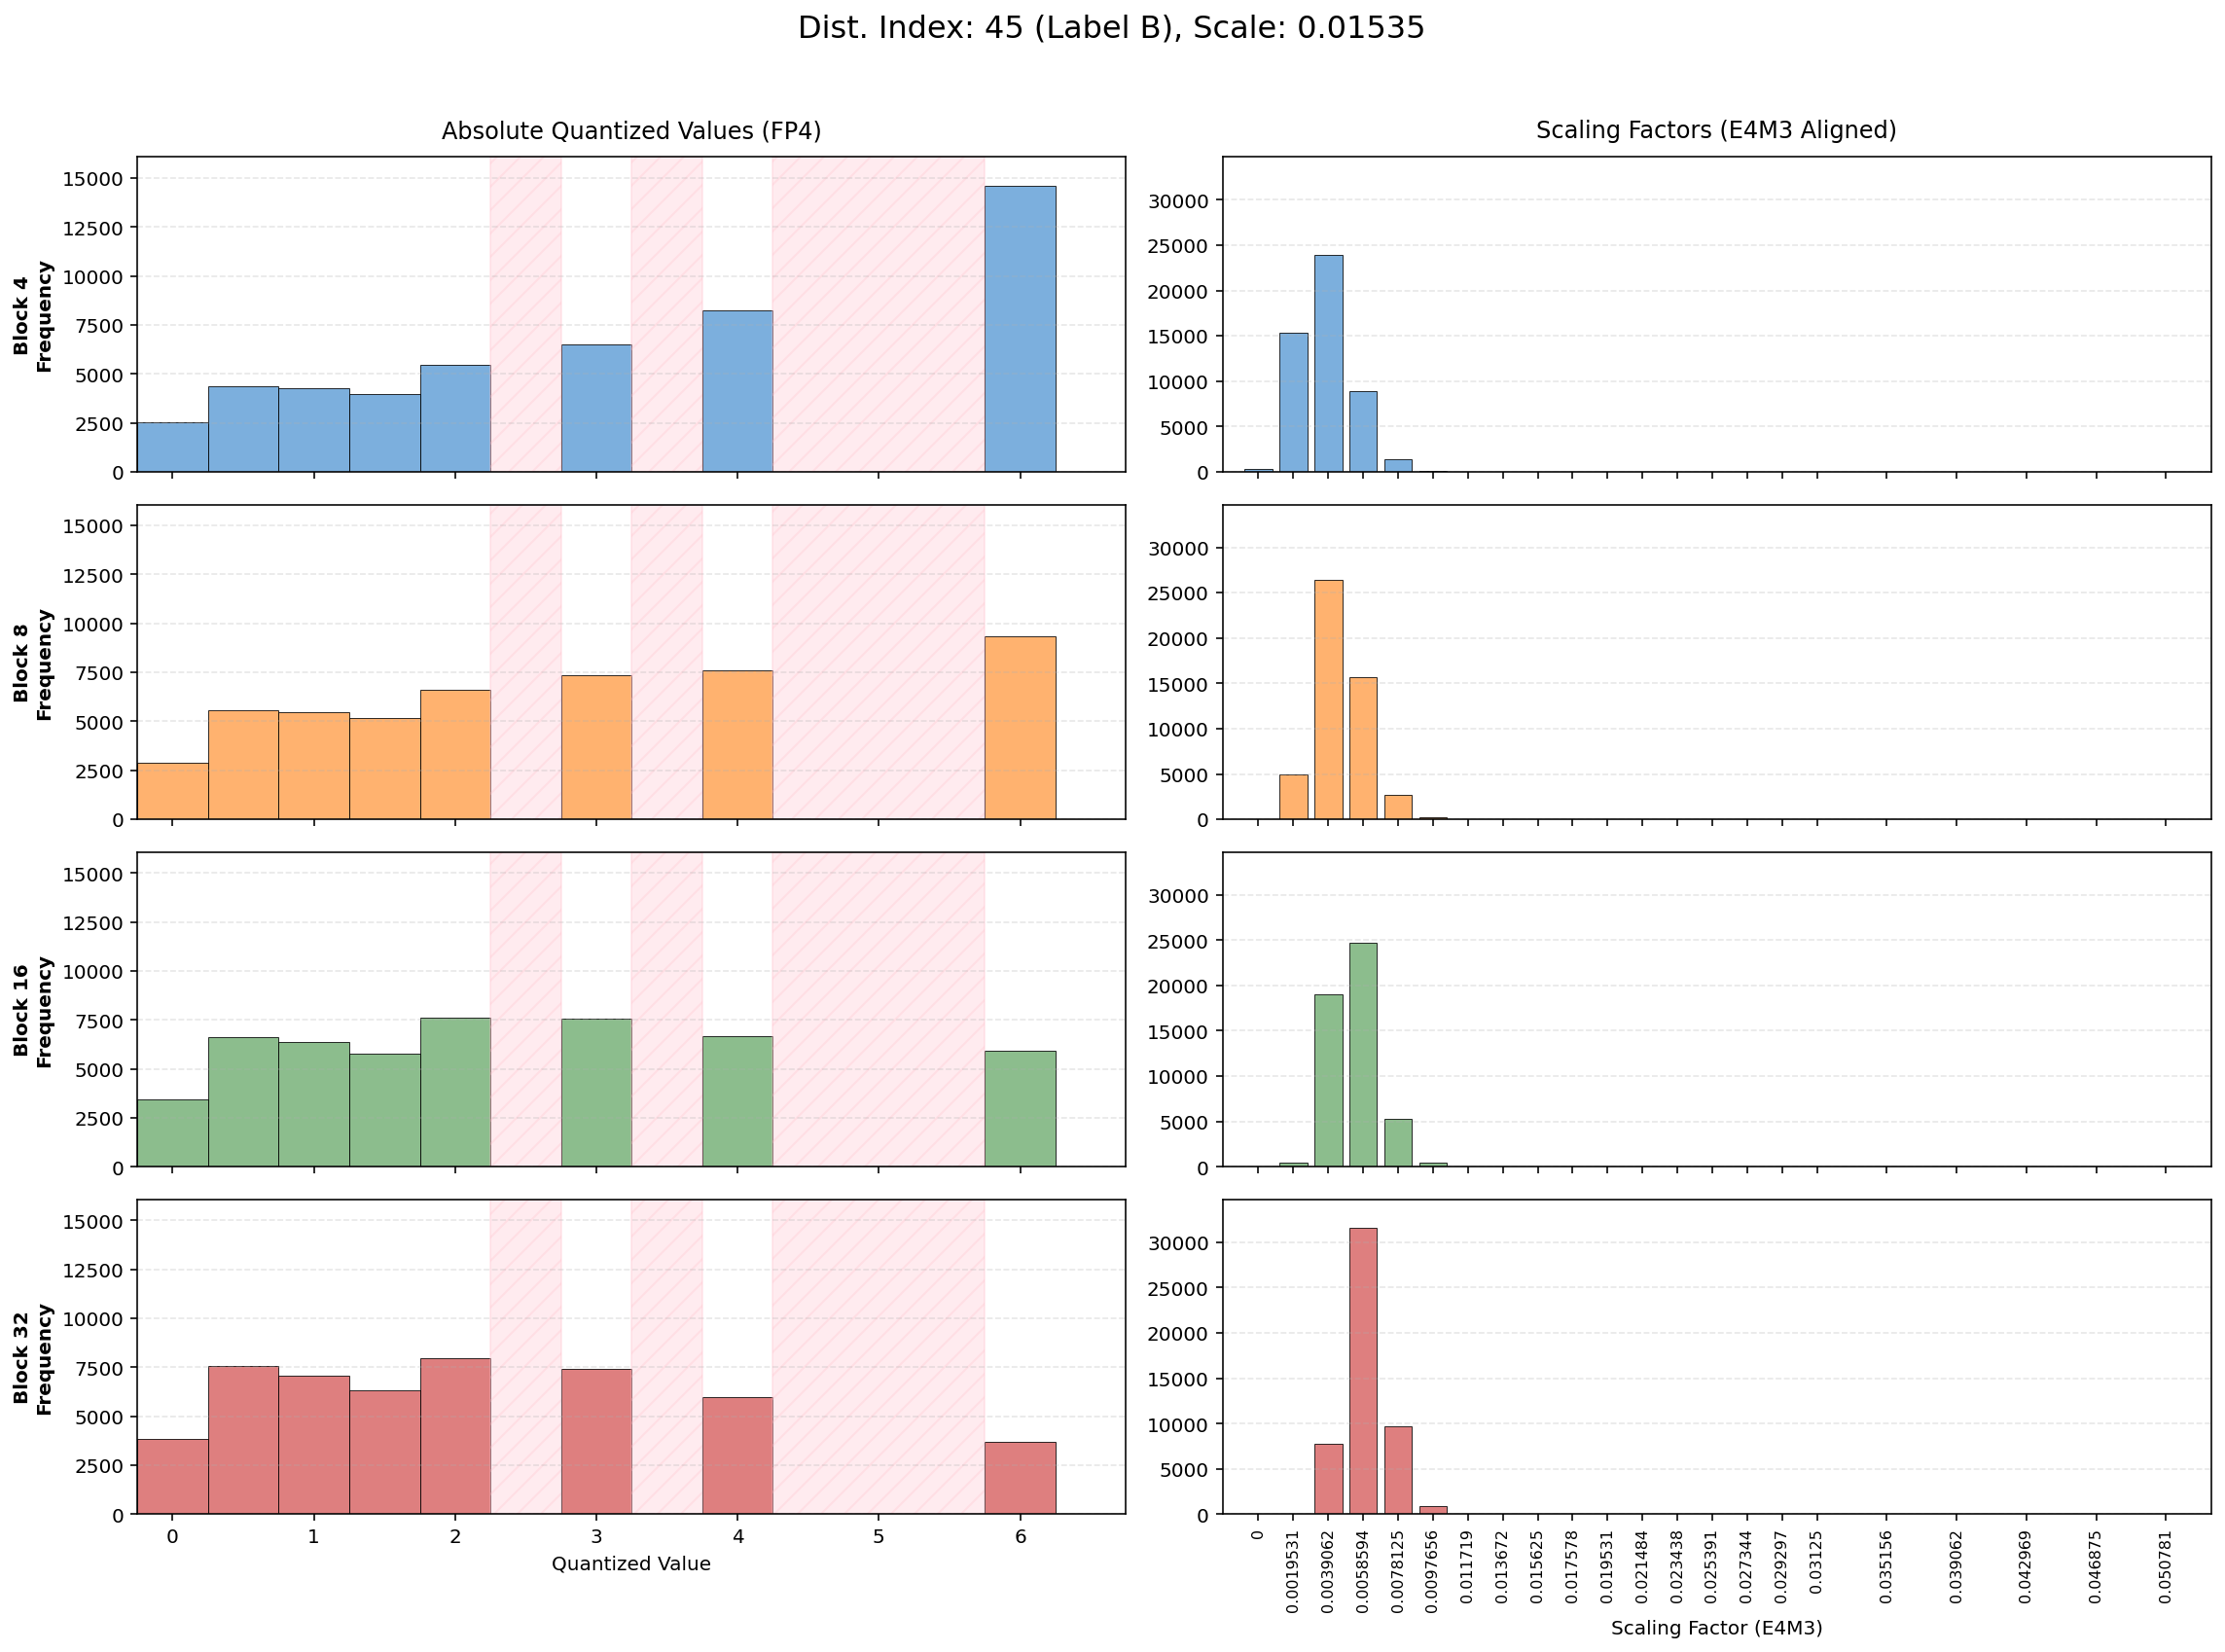

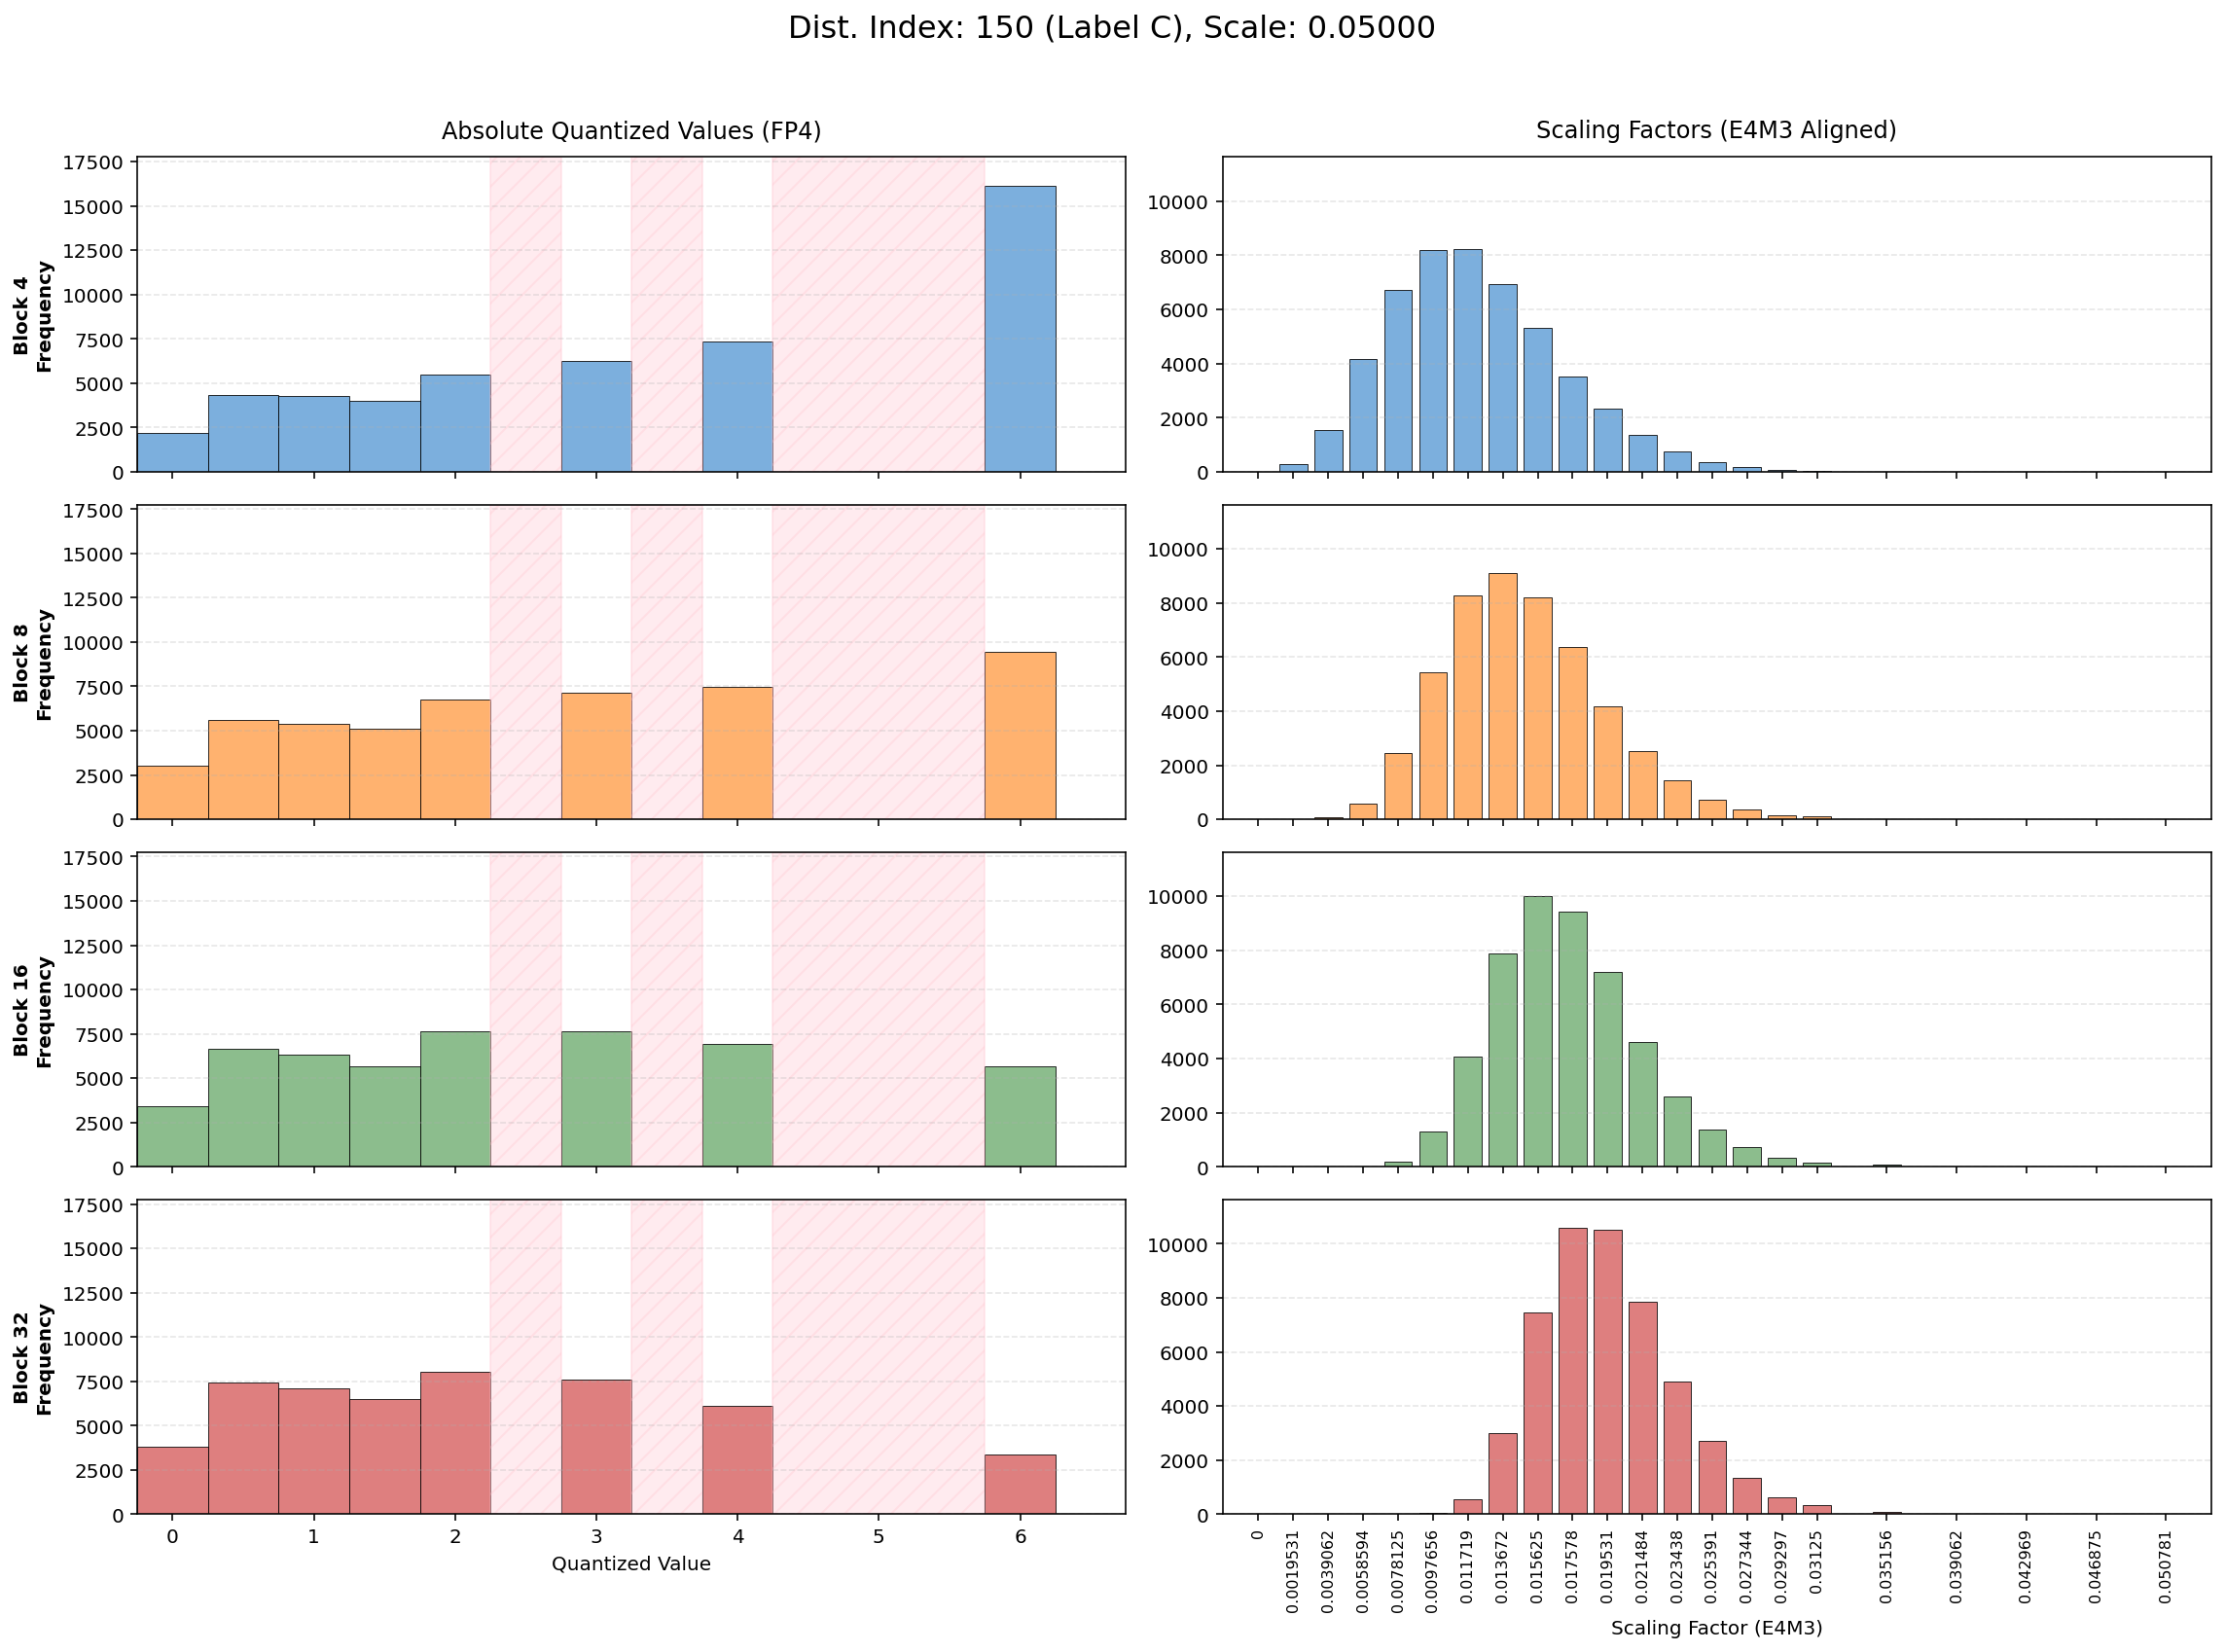

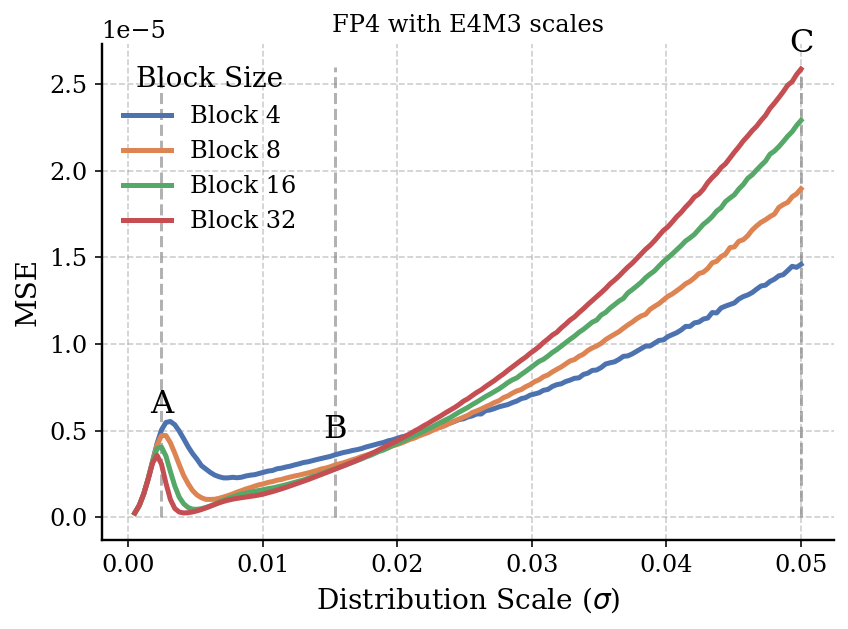

In [6]:
df_fp4_absmax = run_error_experiment(fp4_quant, quant_type='fp4', title="FP4 with E4M3 scales", )

## E4M3 nonzero abs max

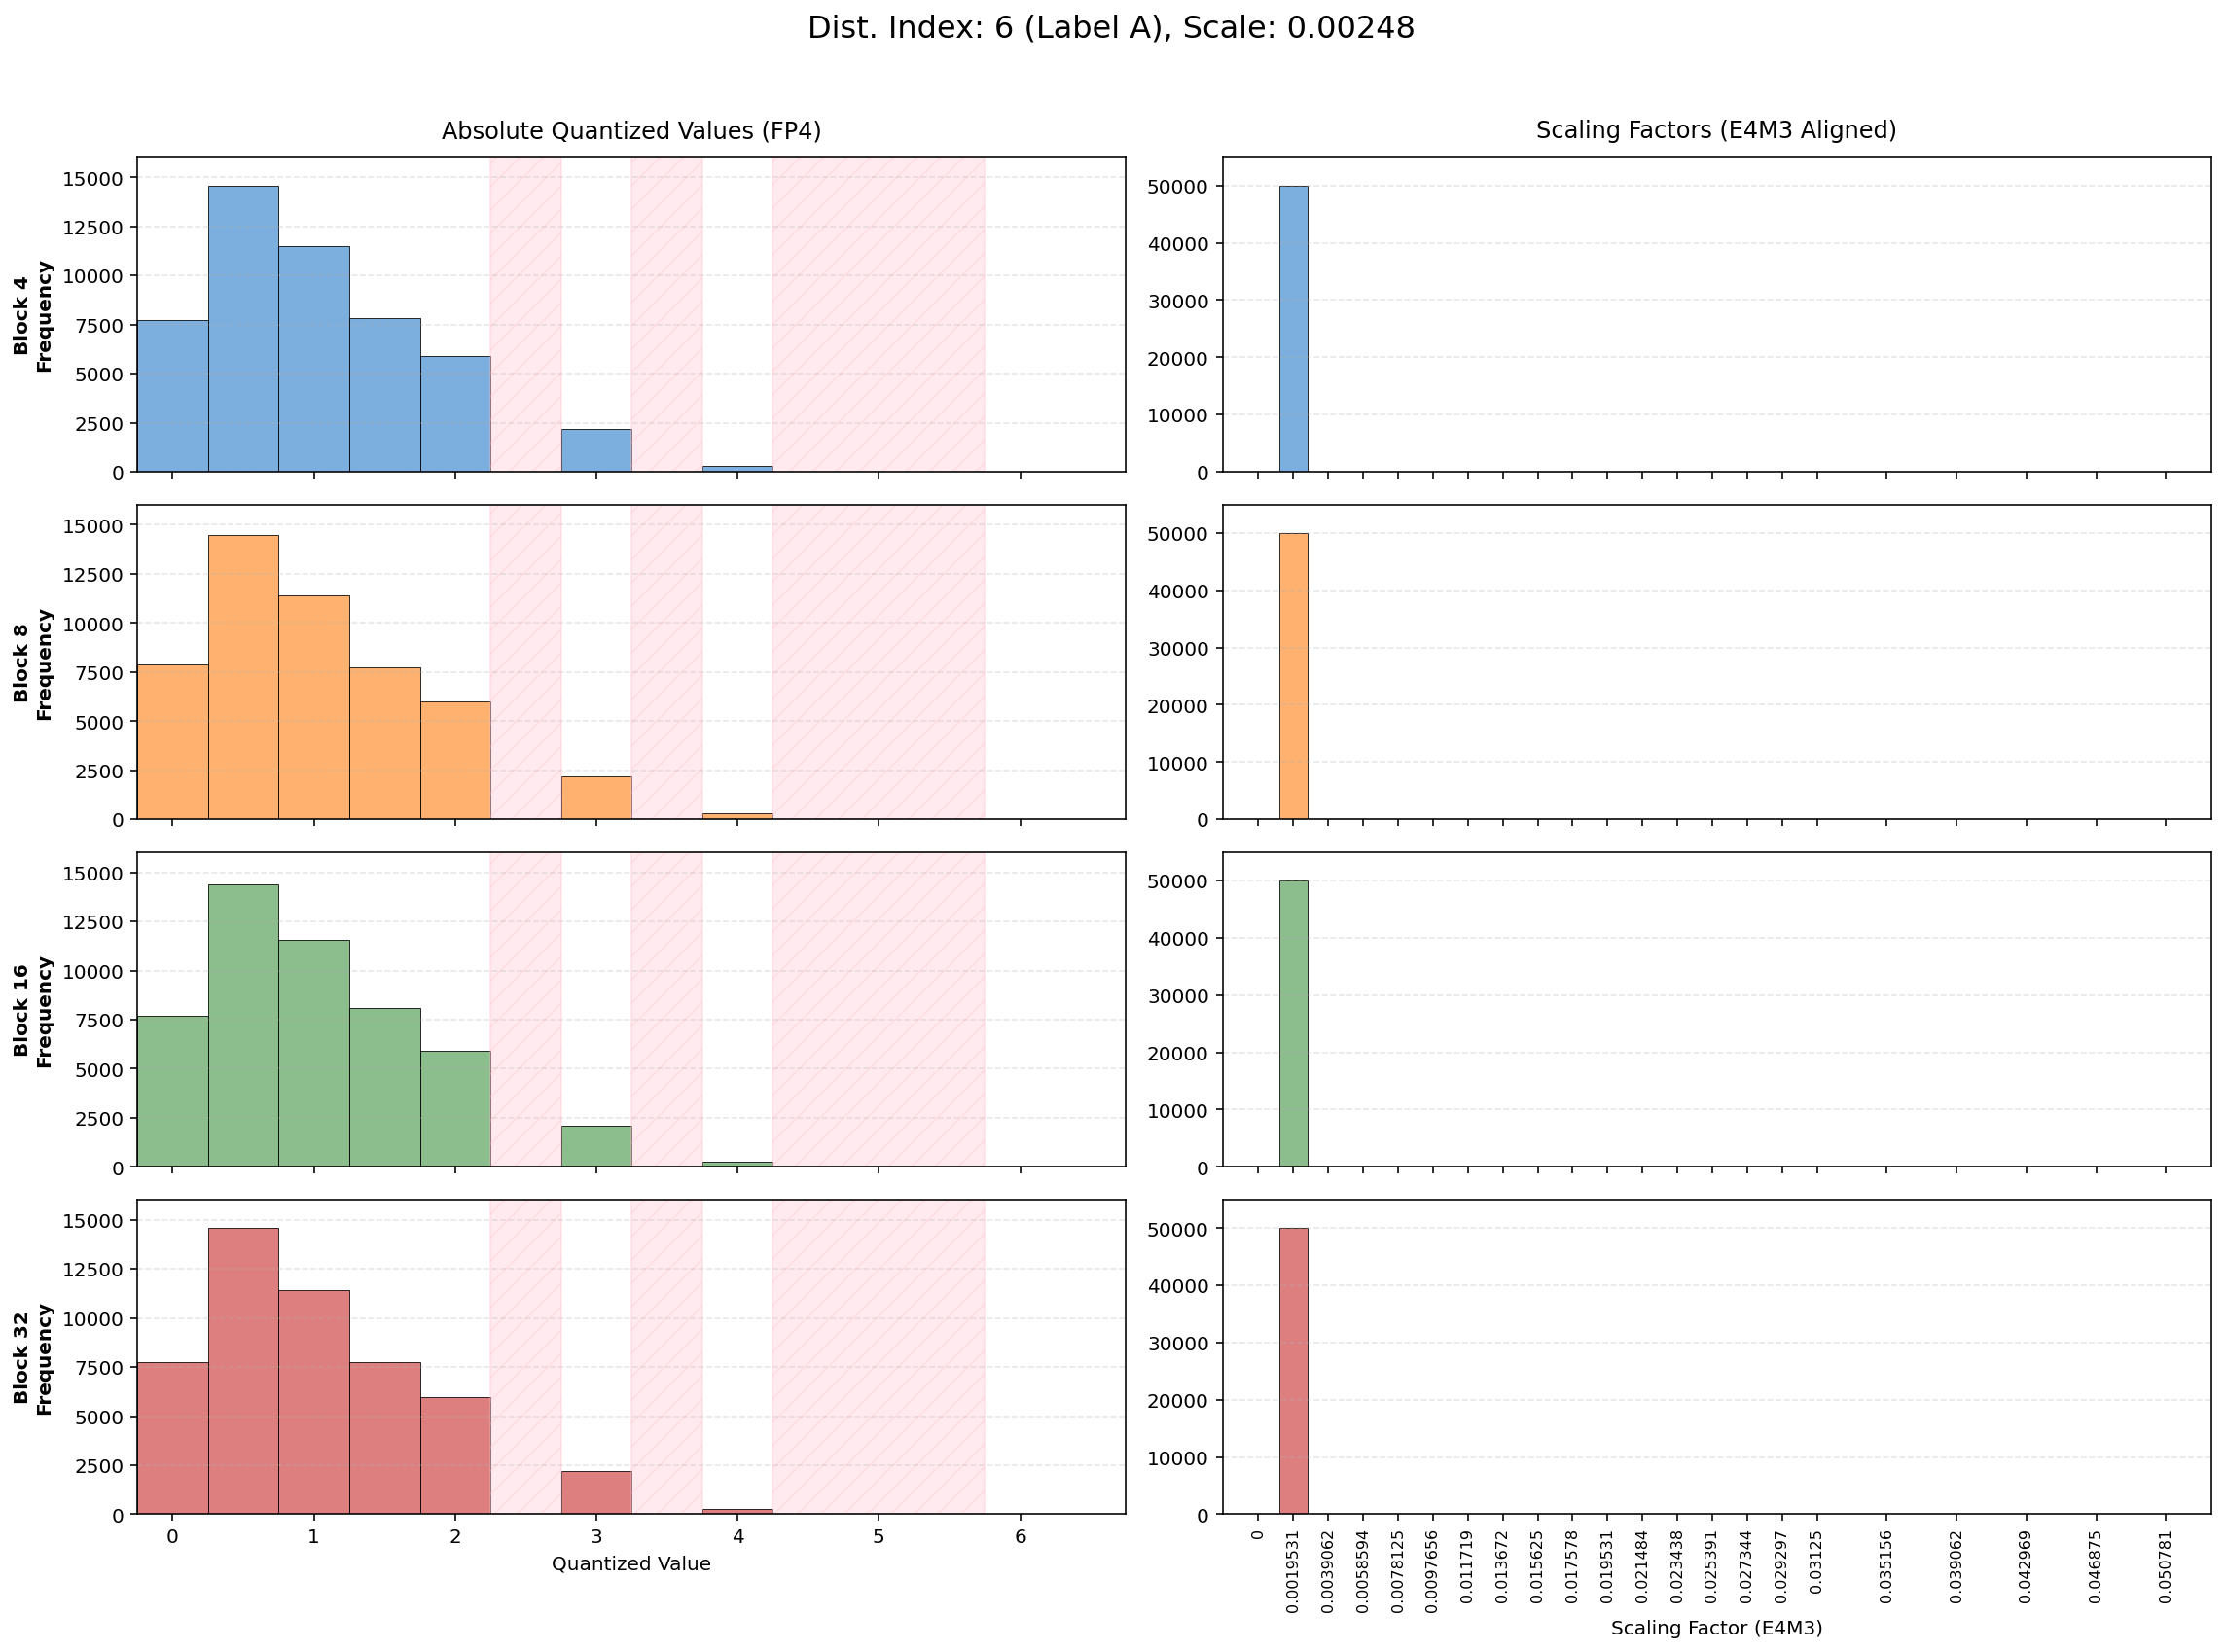

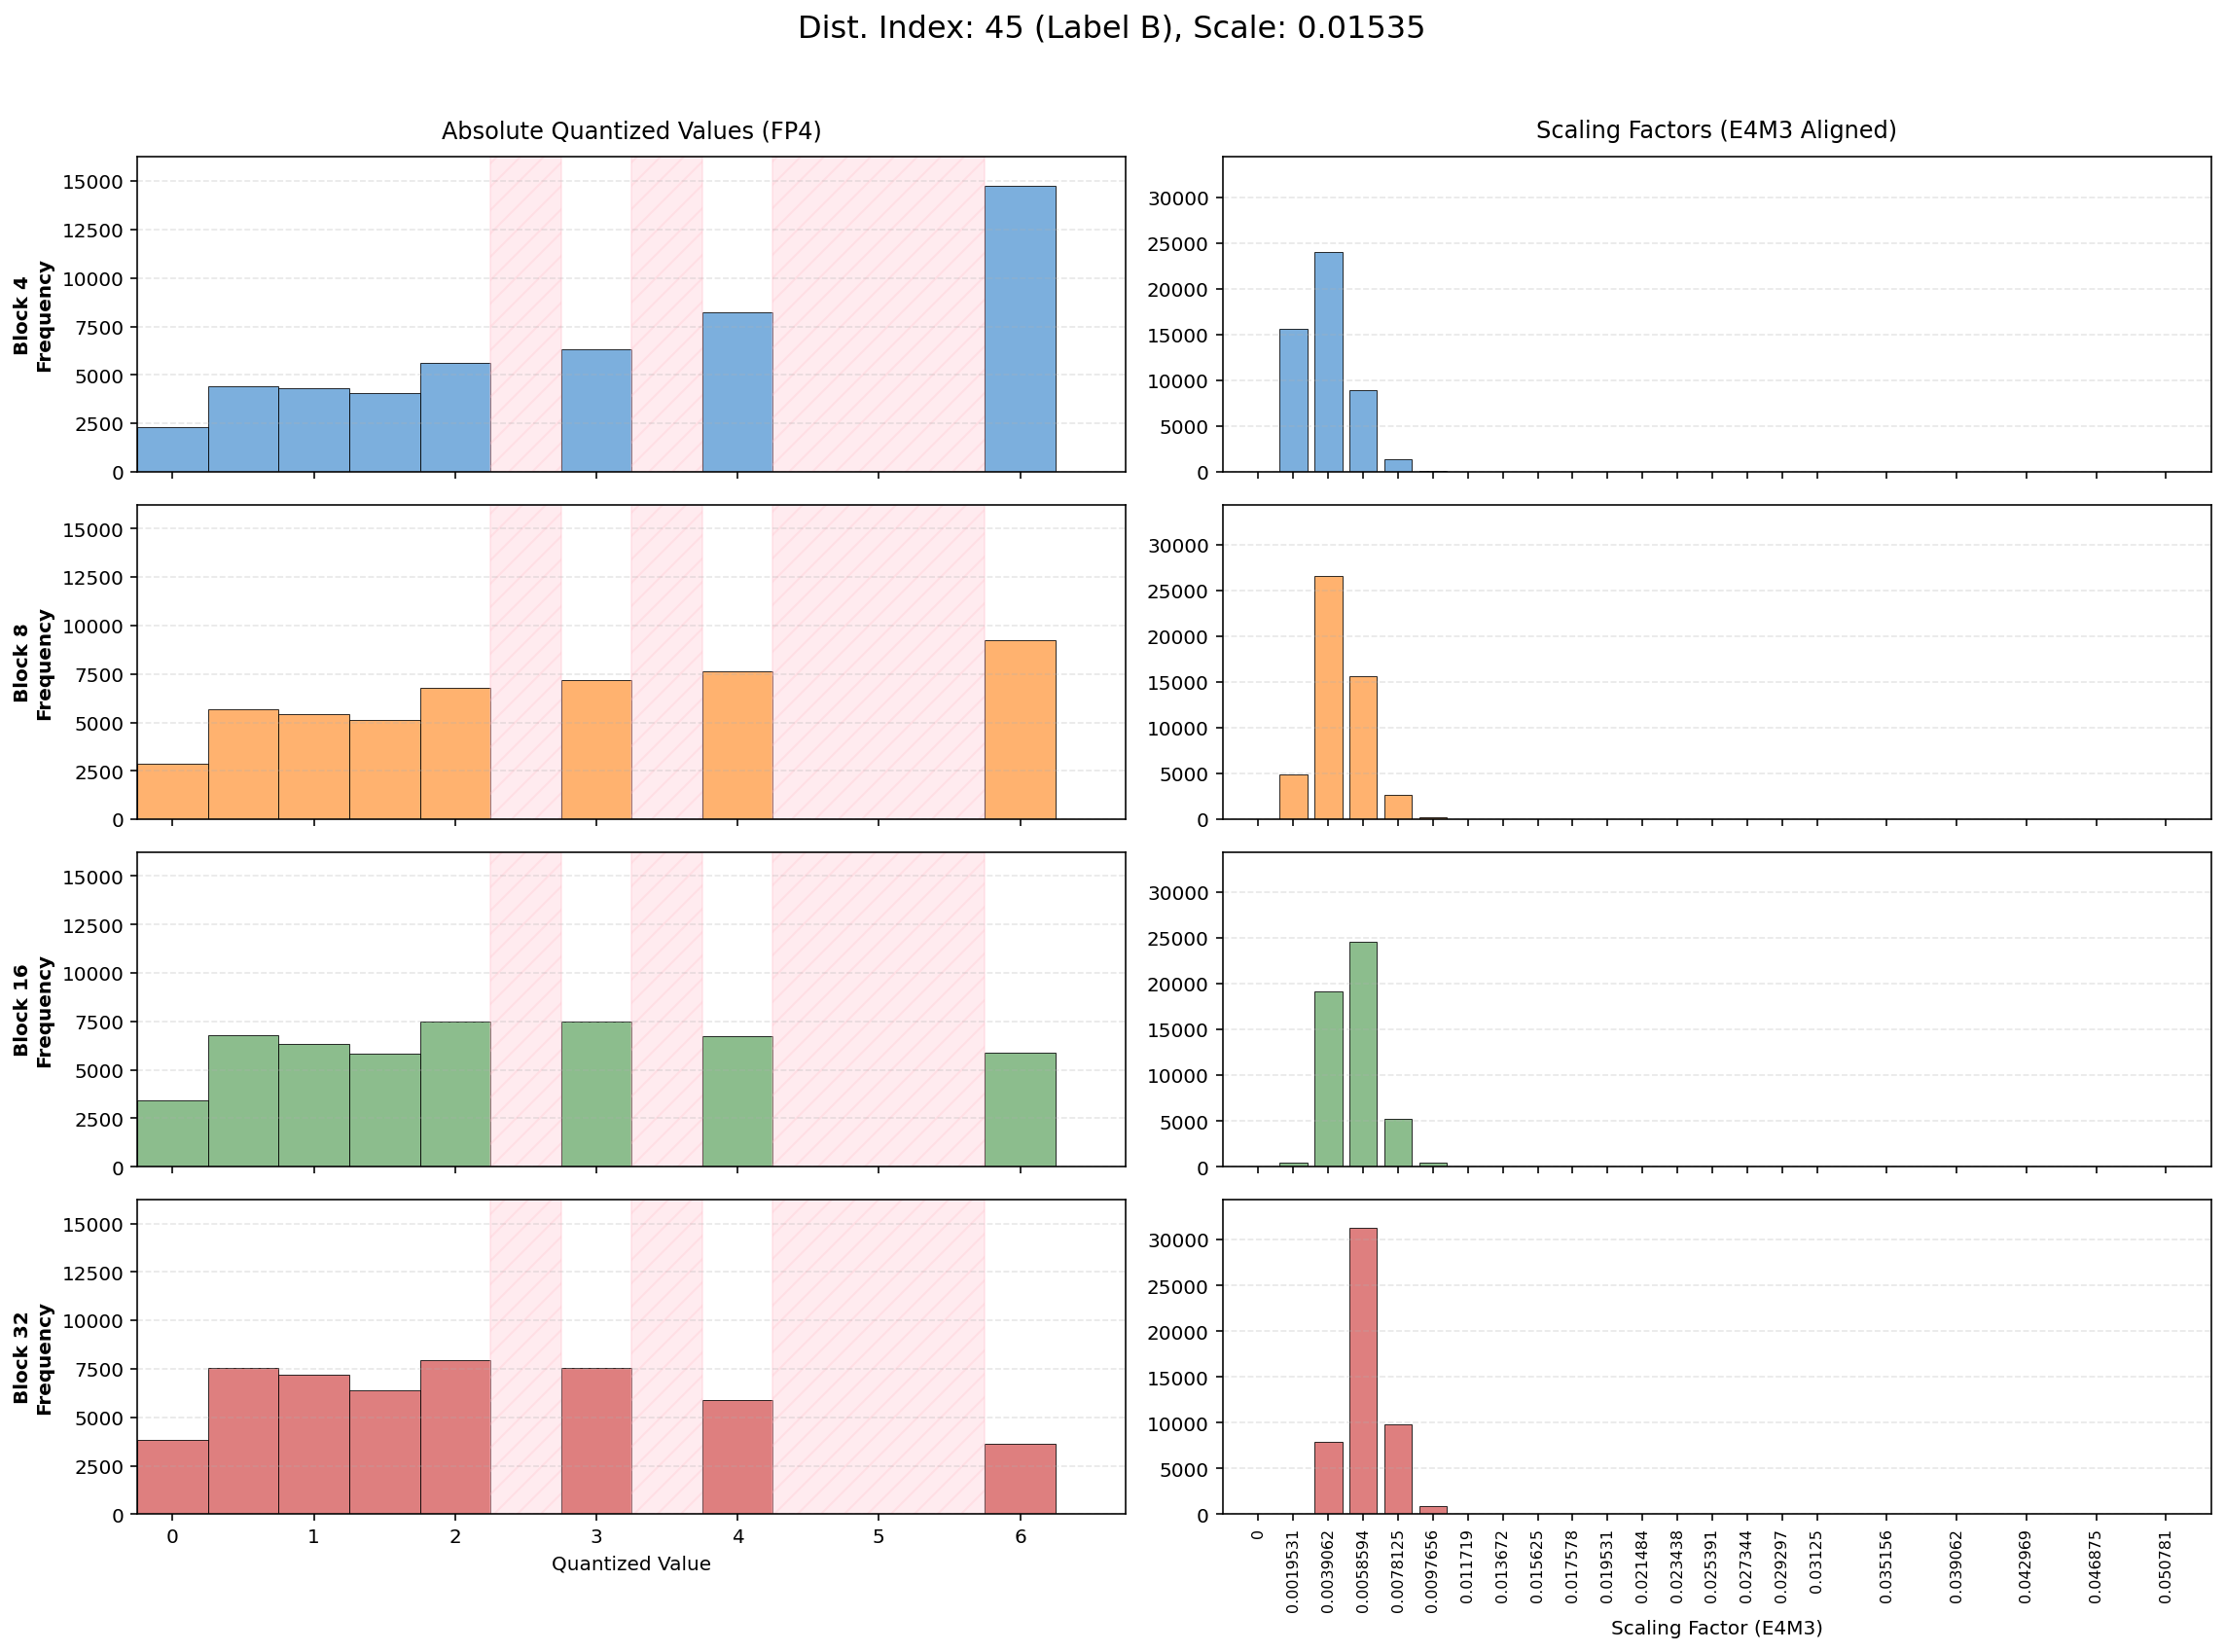

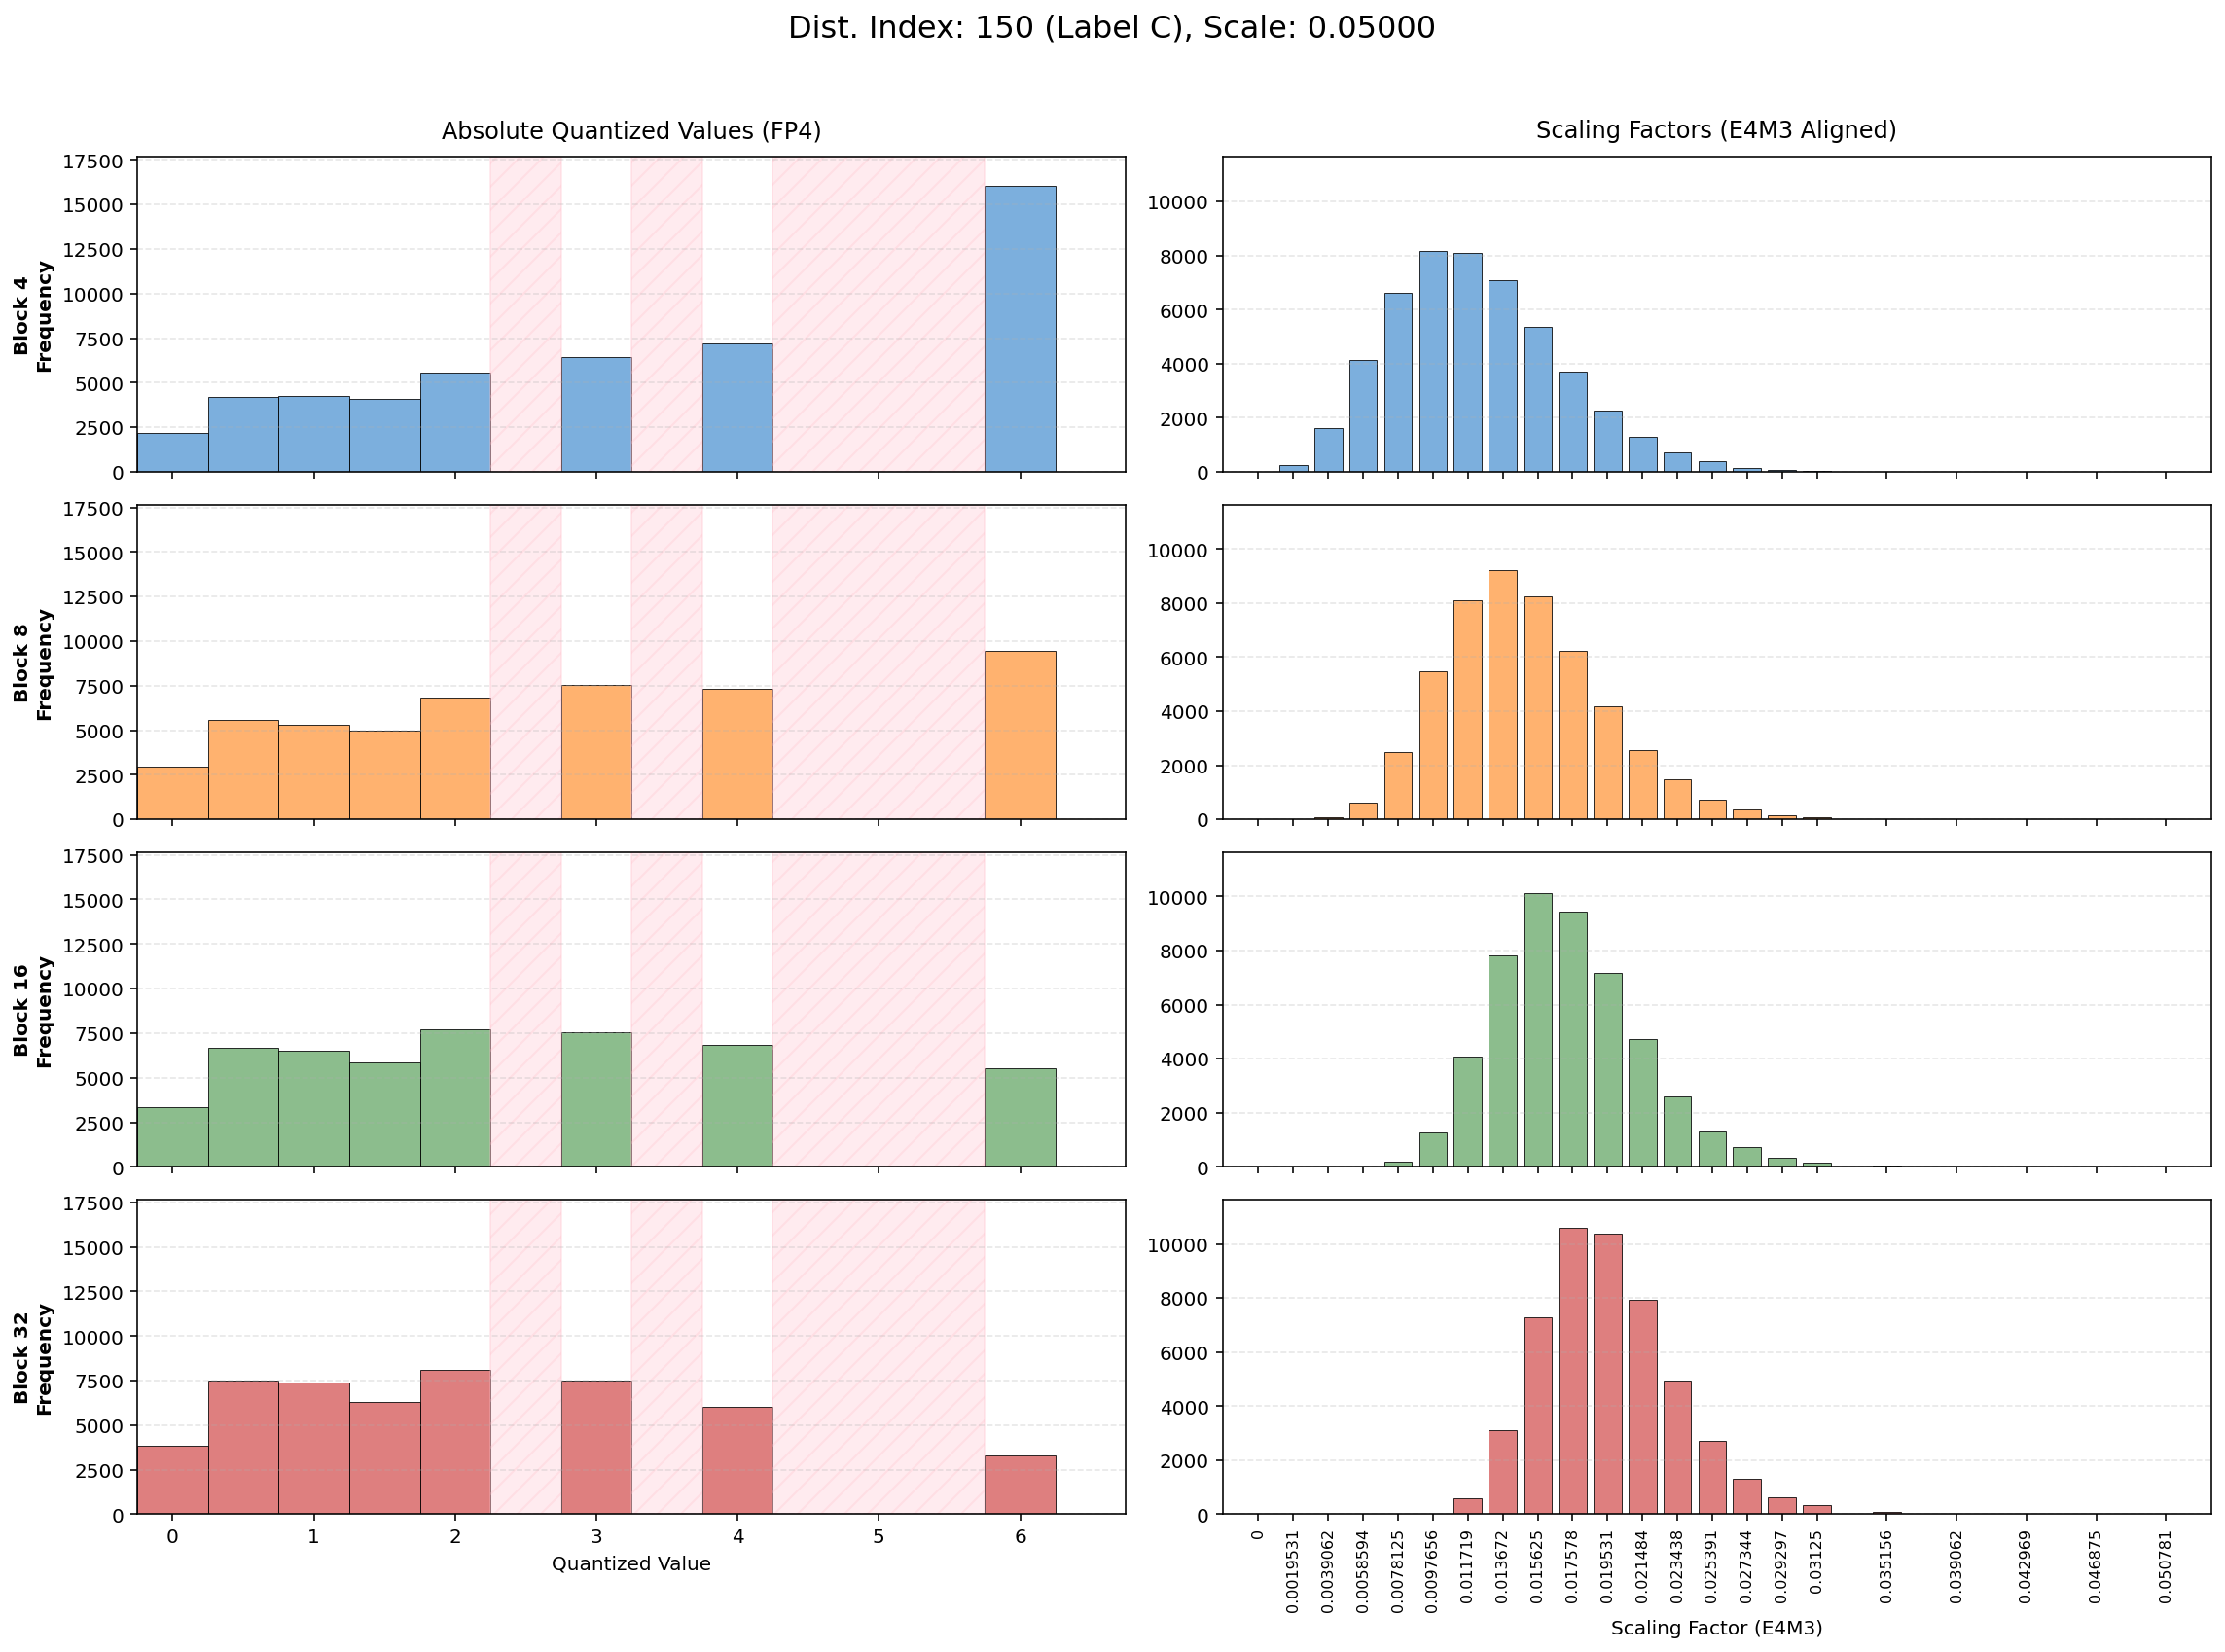

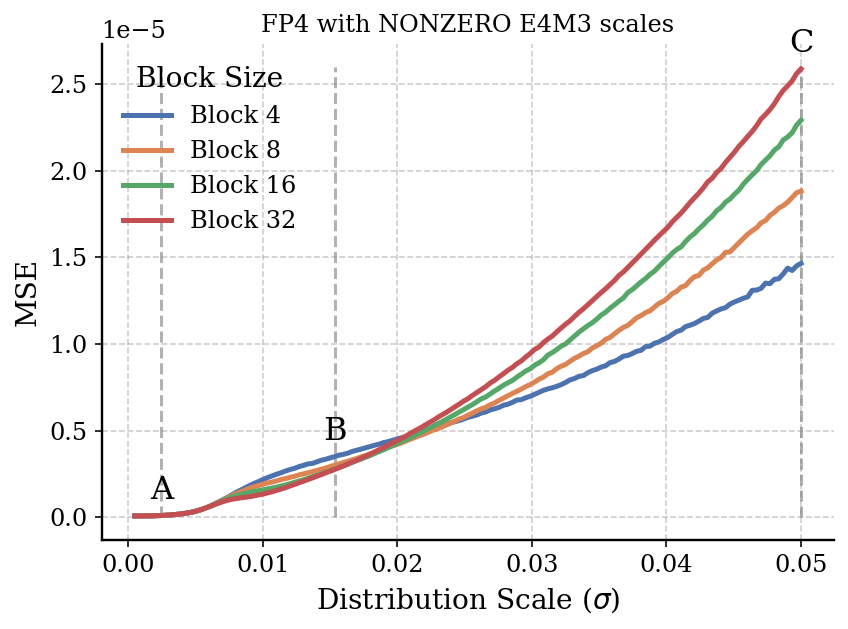

In [7]:
df_fp4_nonzero_absmax = run_error_experiment(nonzero_fp4_quant,  quant_type='fp4', title="FP4 with NONZERO E4M3 scales")

## E4M3 search

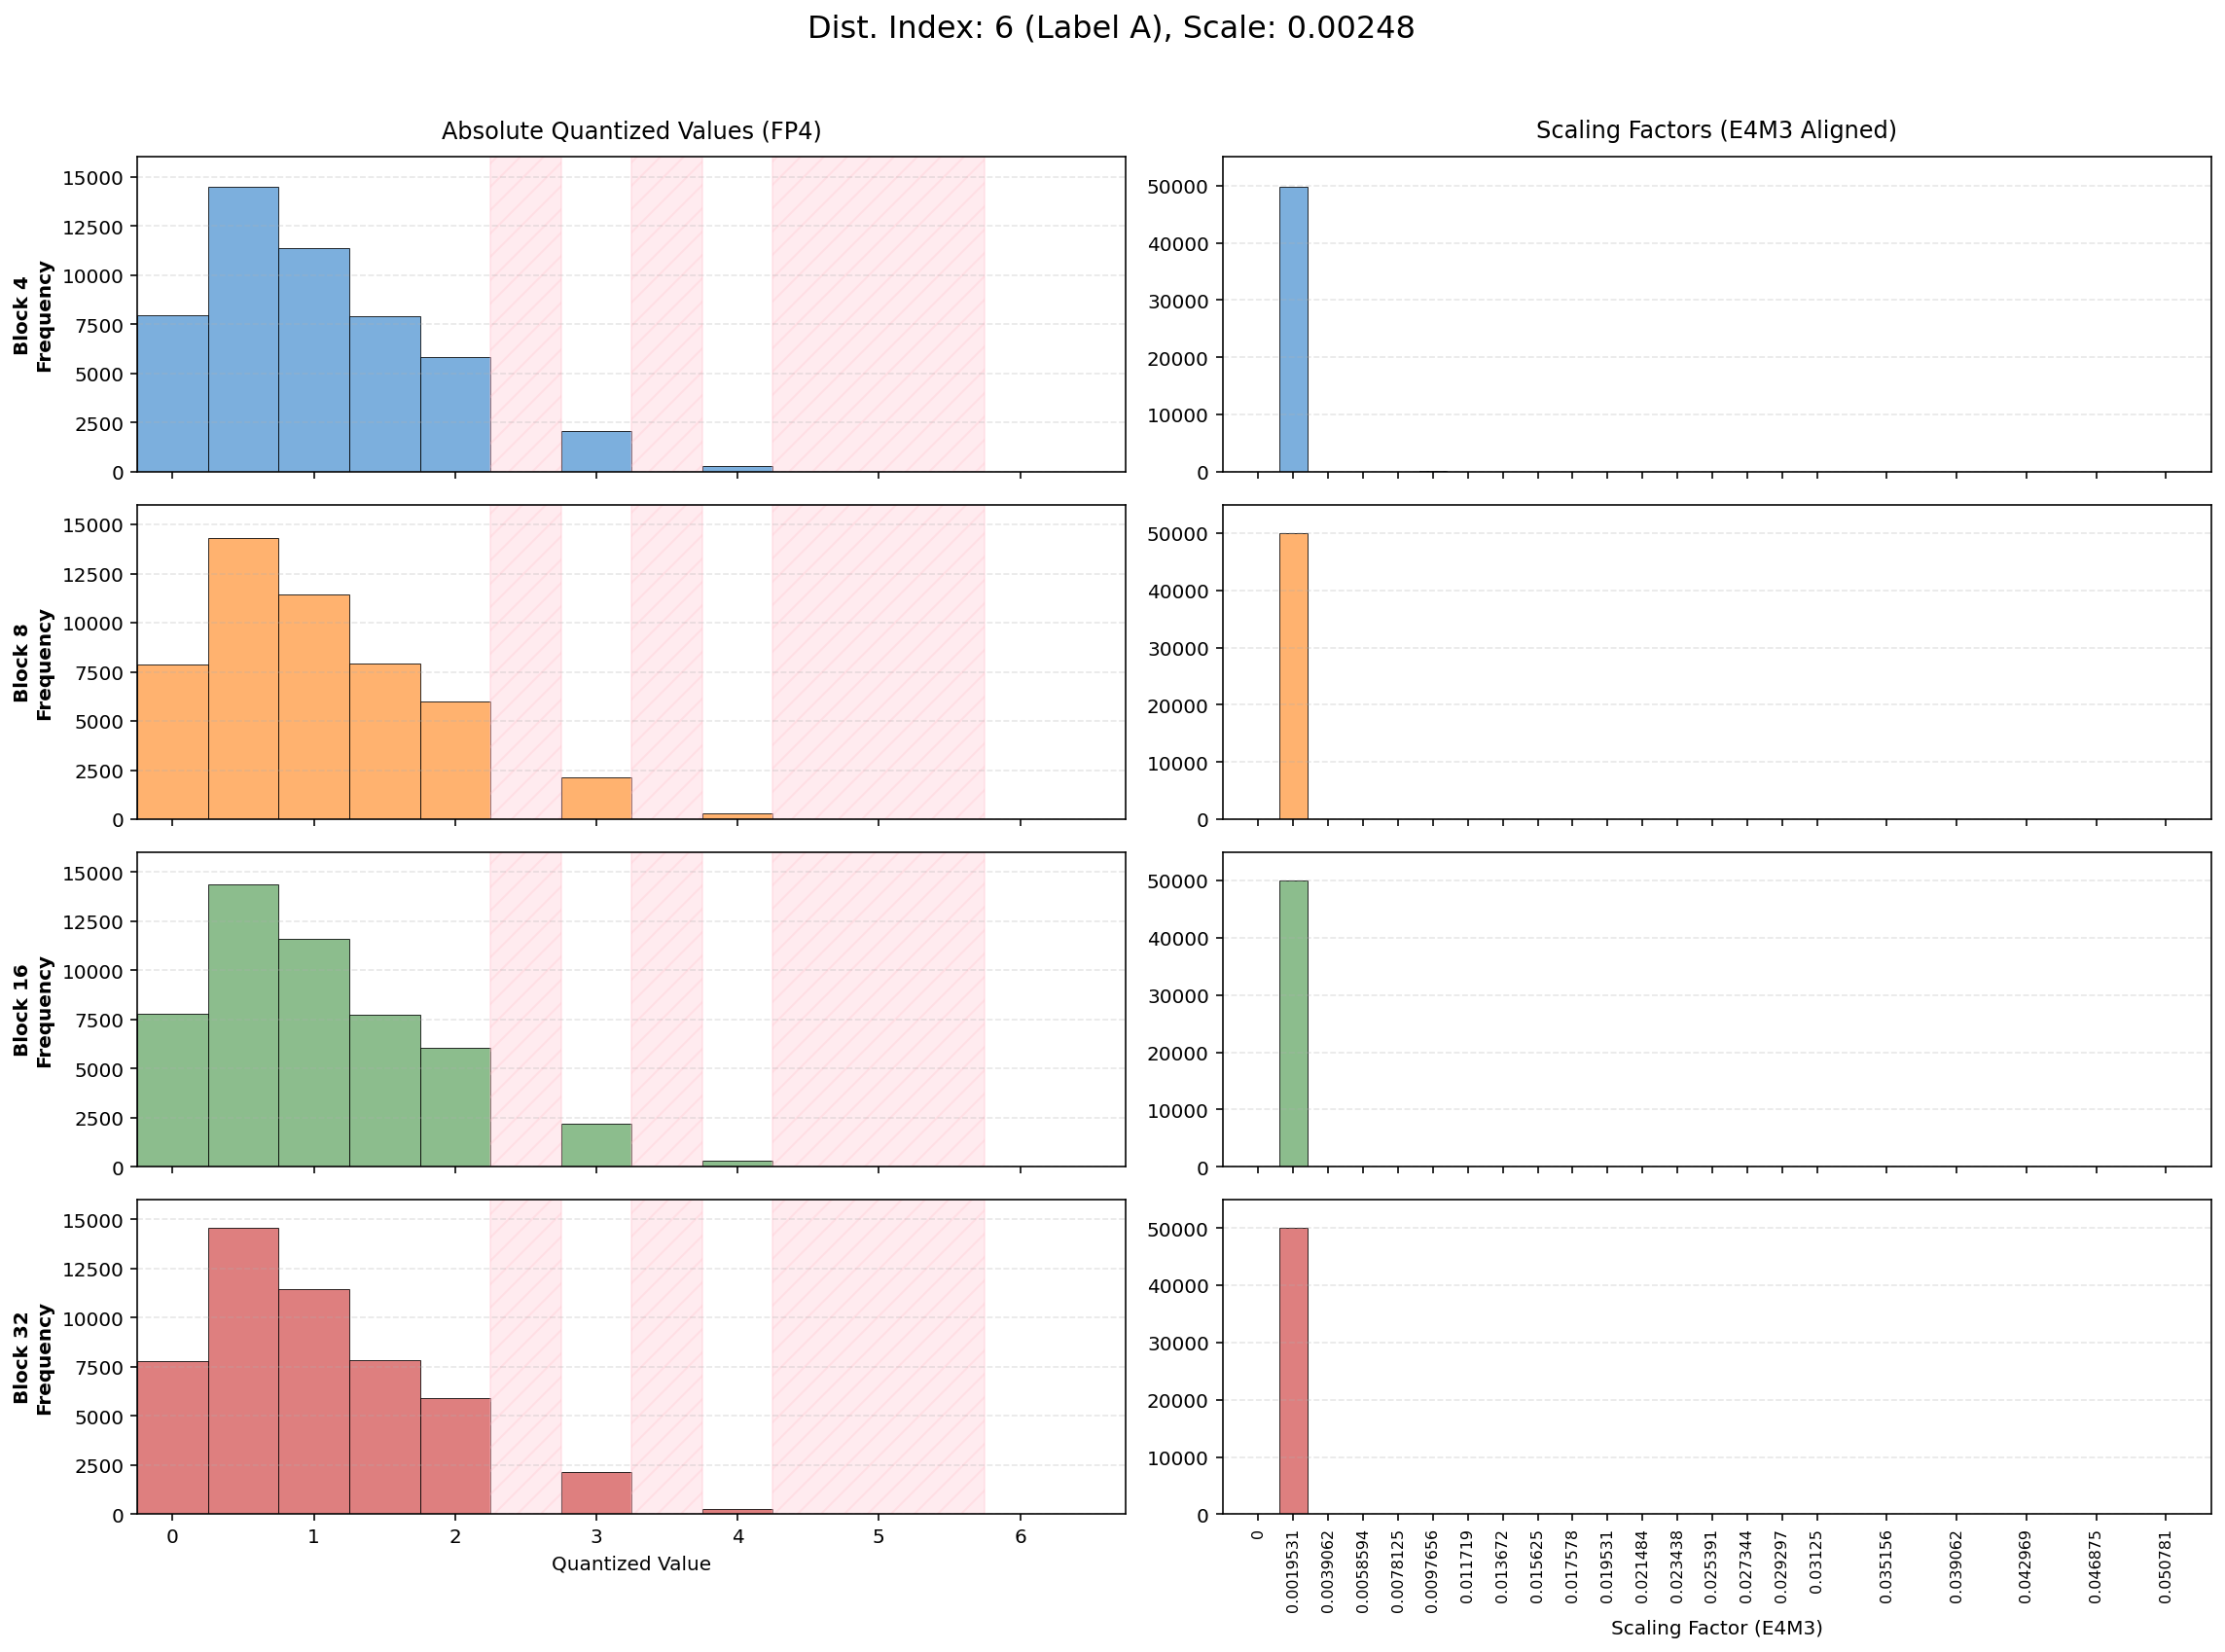

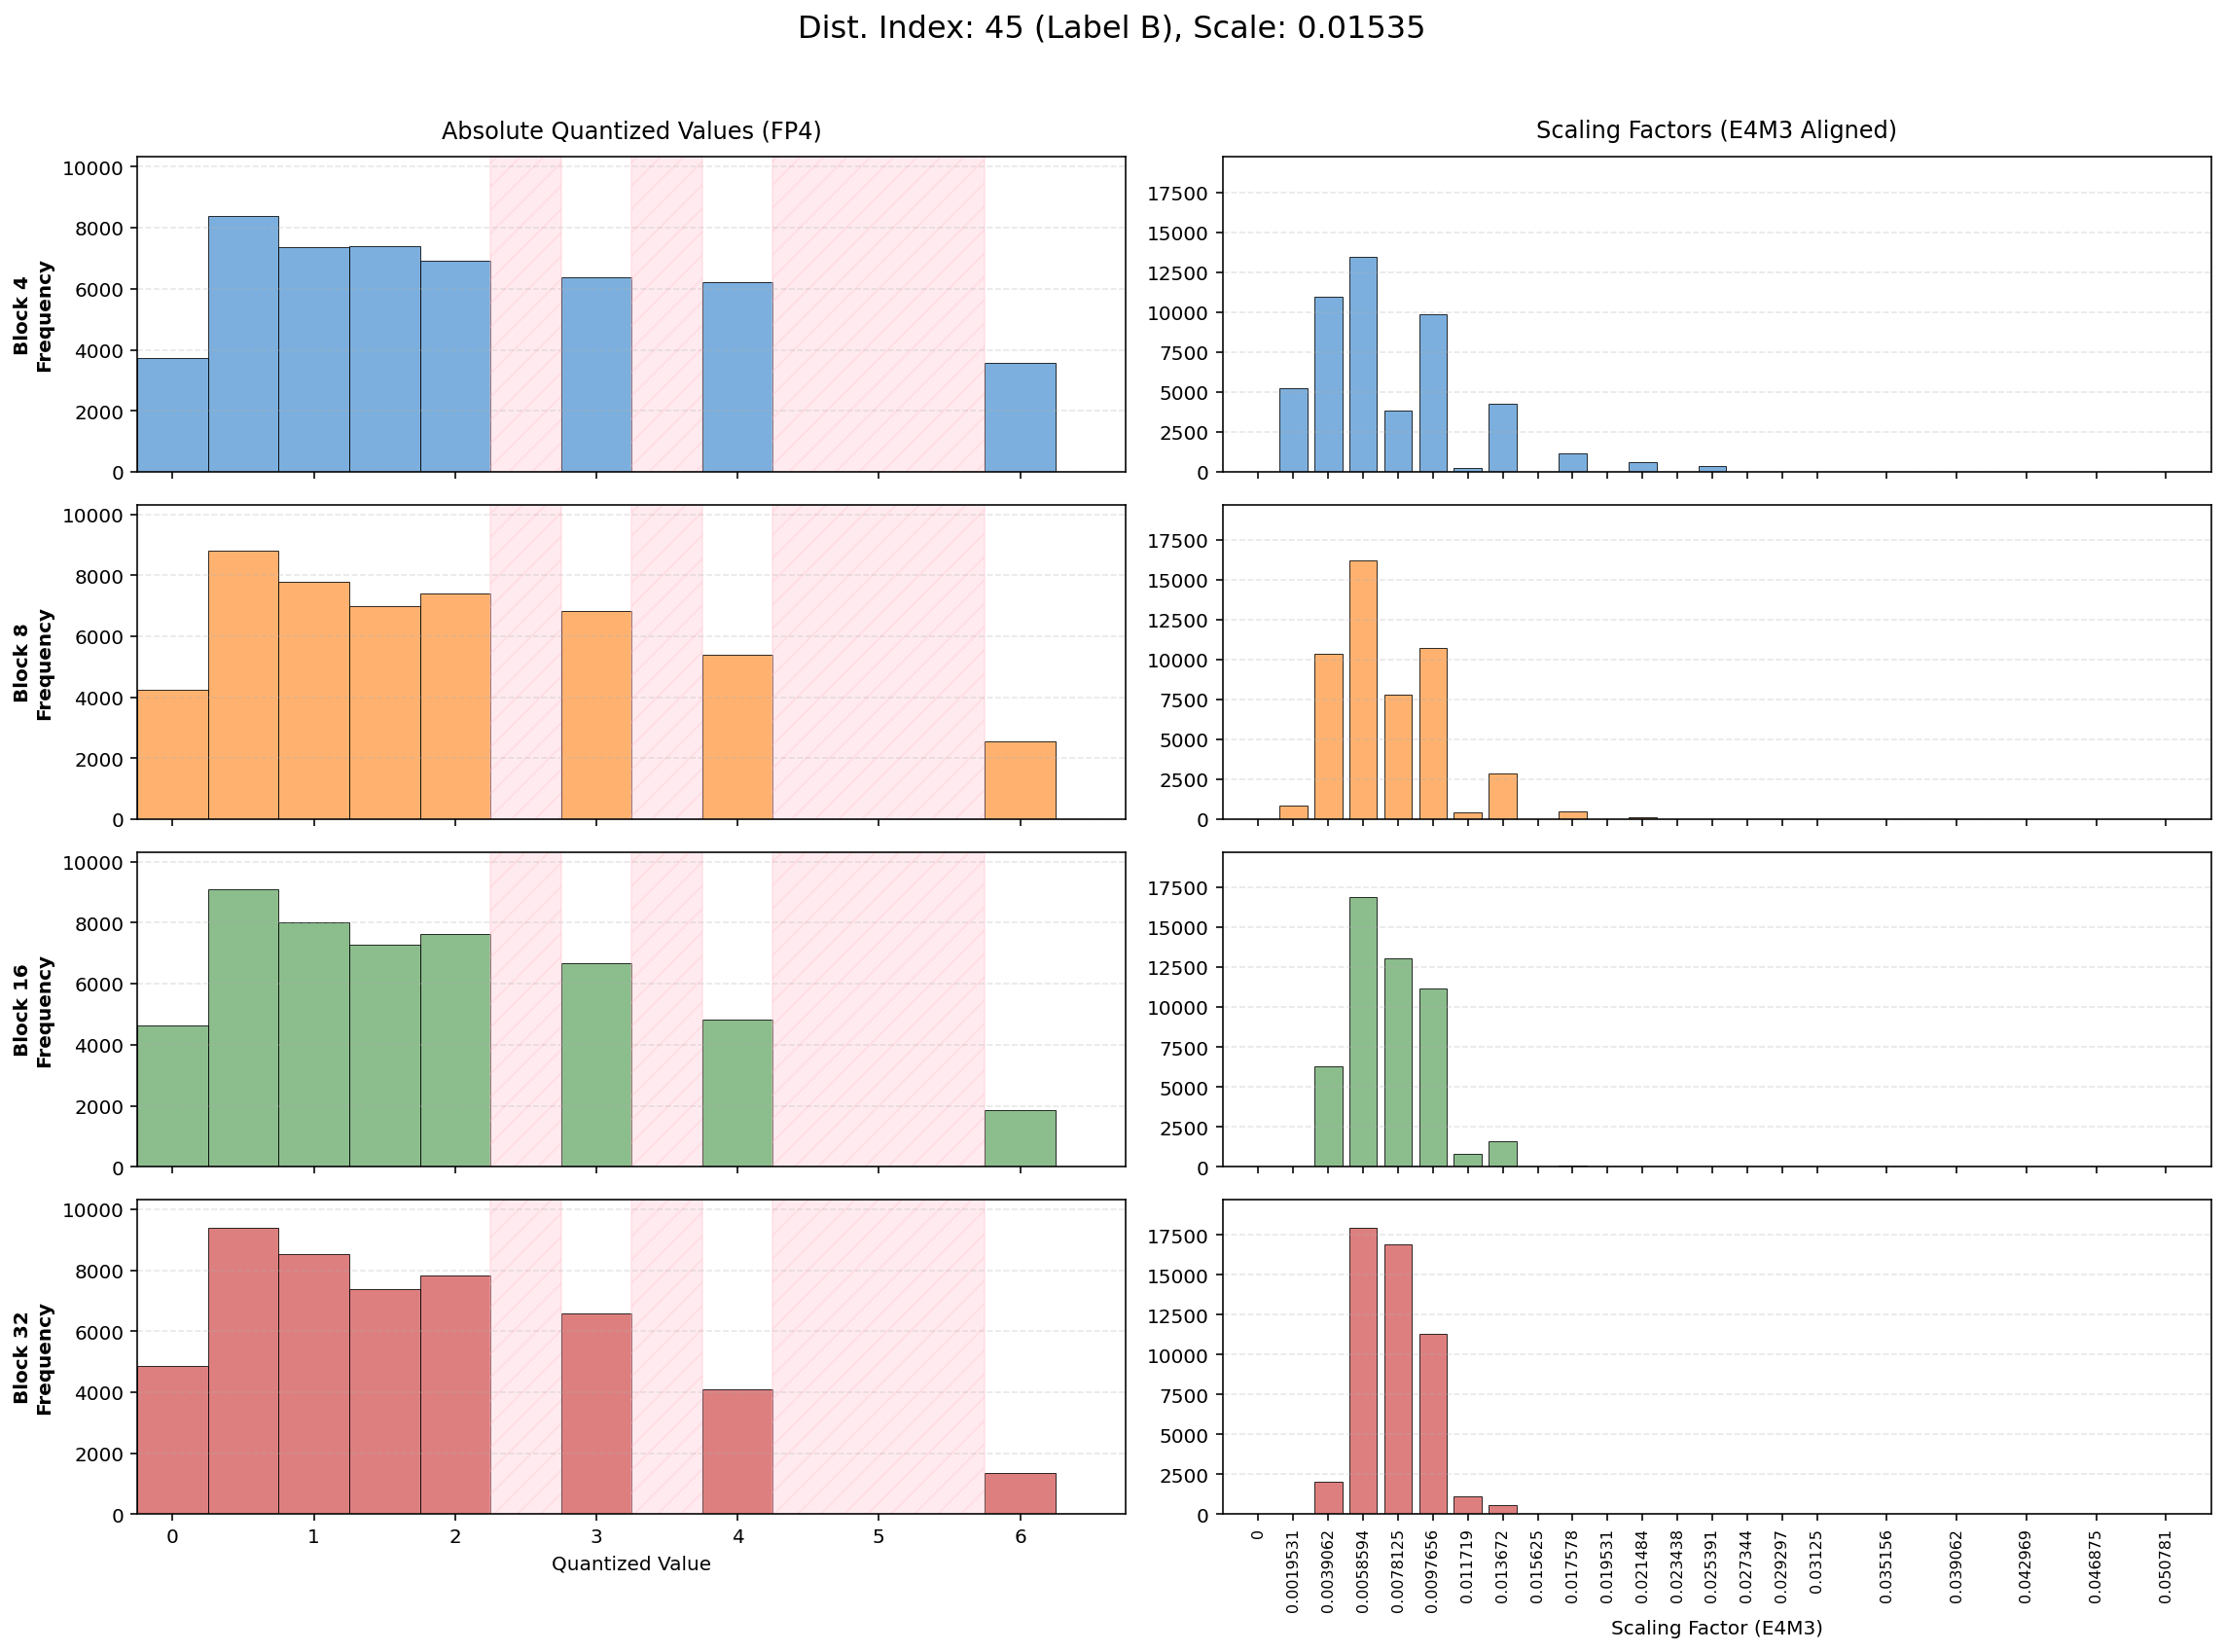

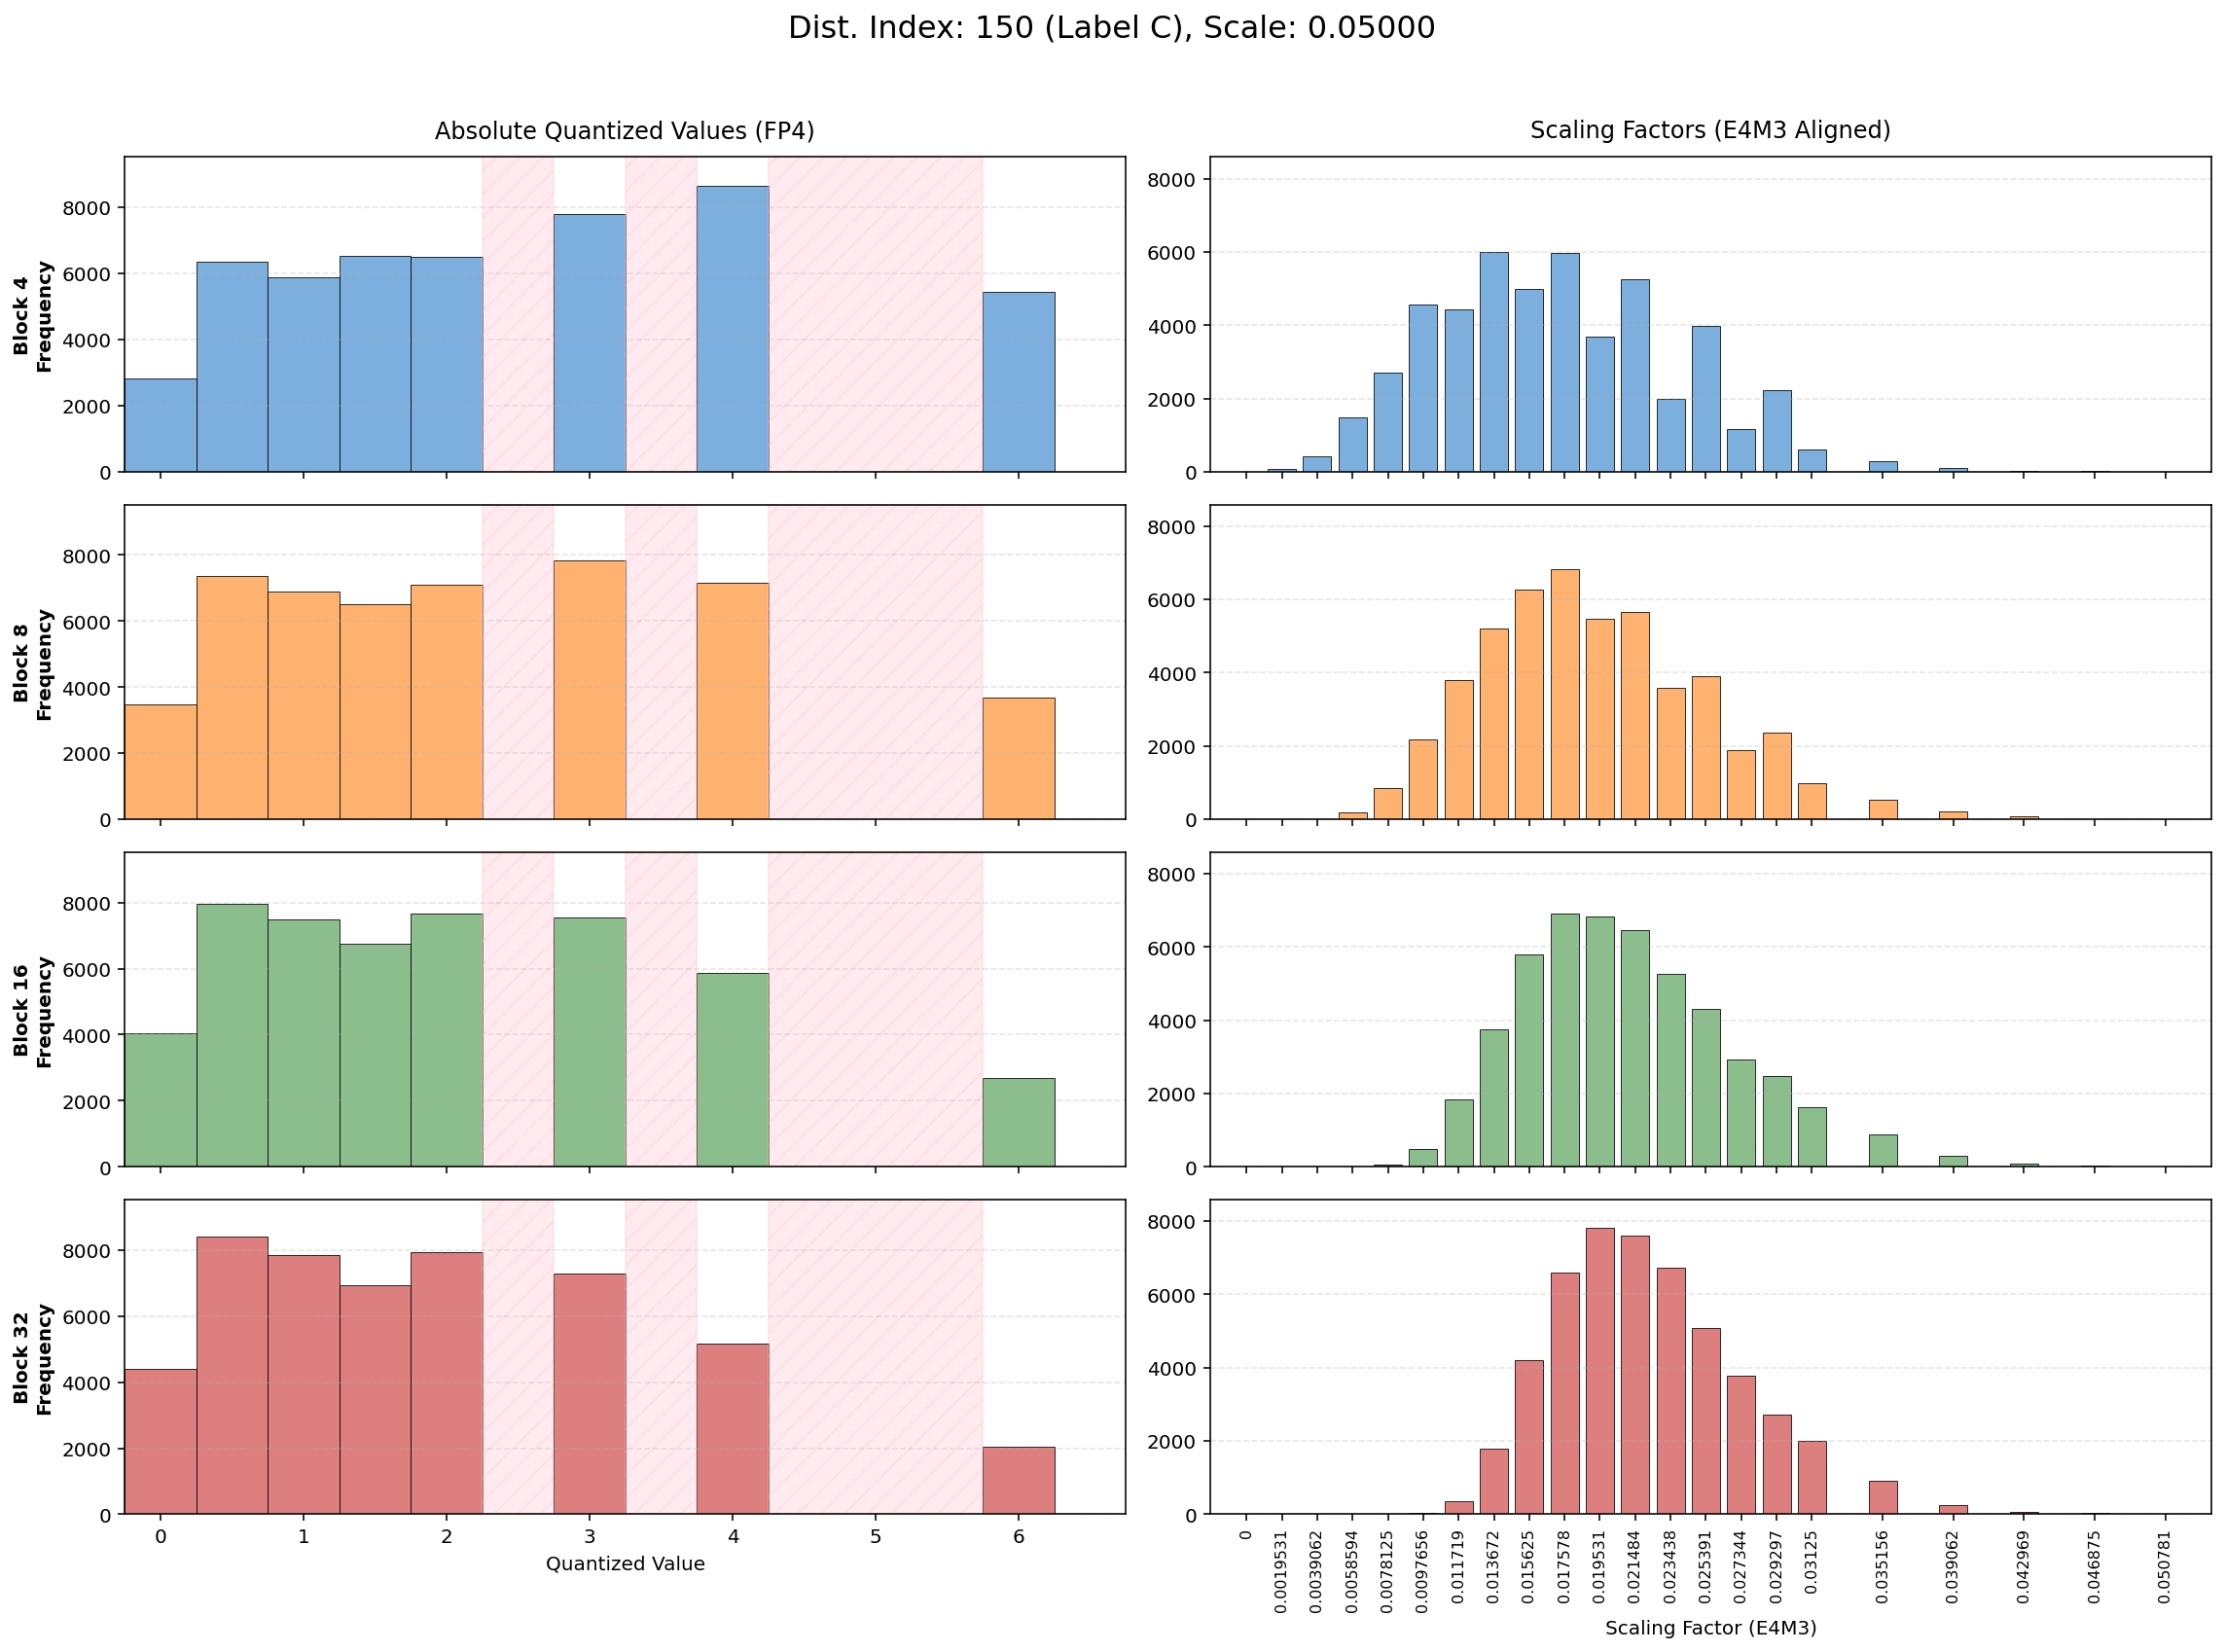

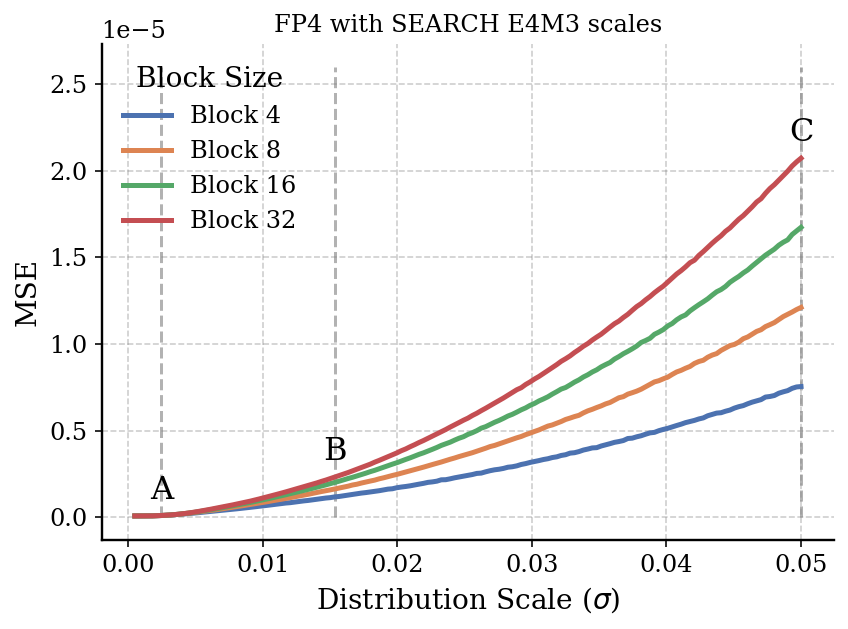

In [8]:
df_fp4_search = run_error_experiment(lambda x: search_quant(x, quant_type='fp4'), quant_type='fp4', title="FP4 with SEARCH E4M3 scales")

## 4/6 without nonzero abs max

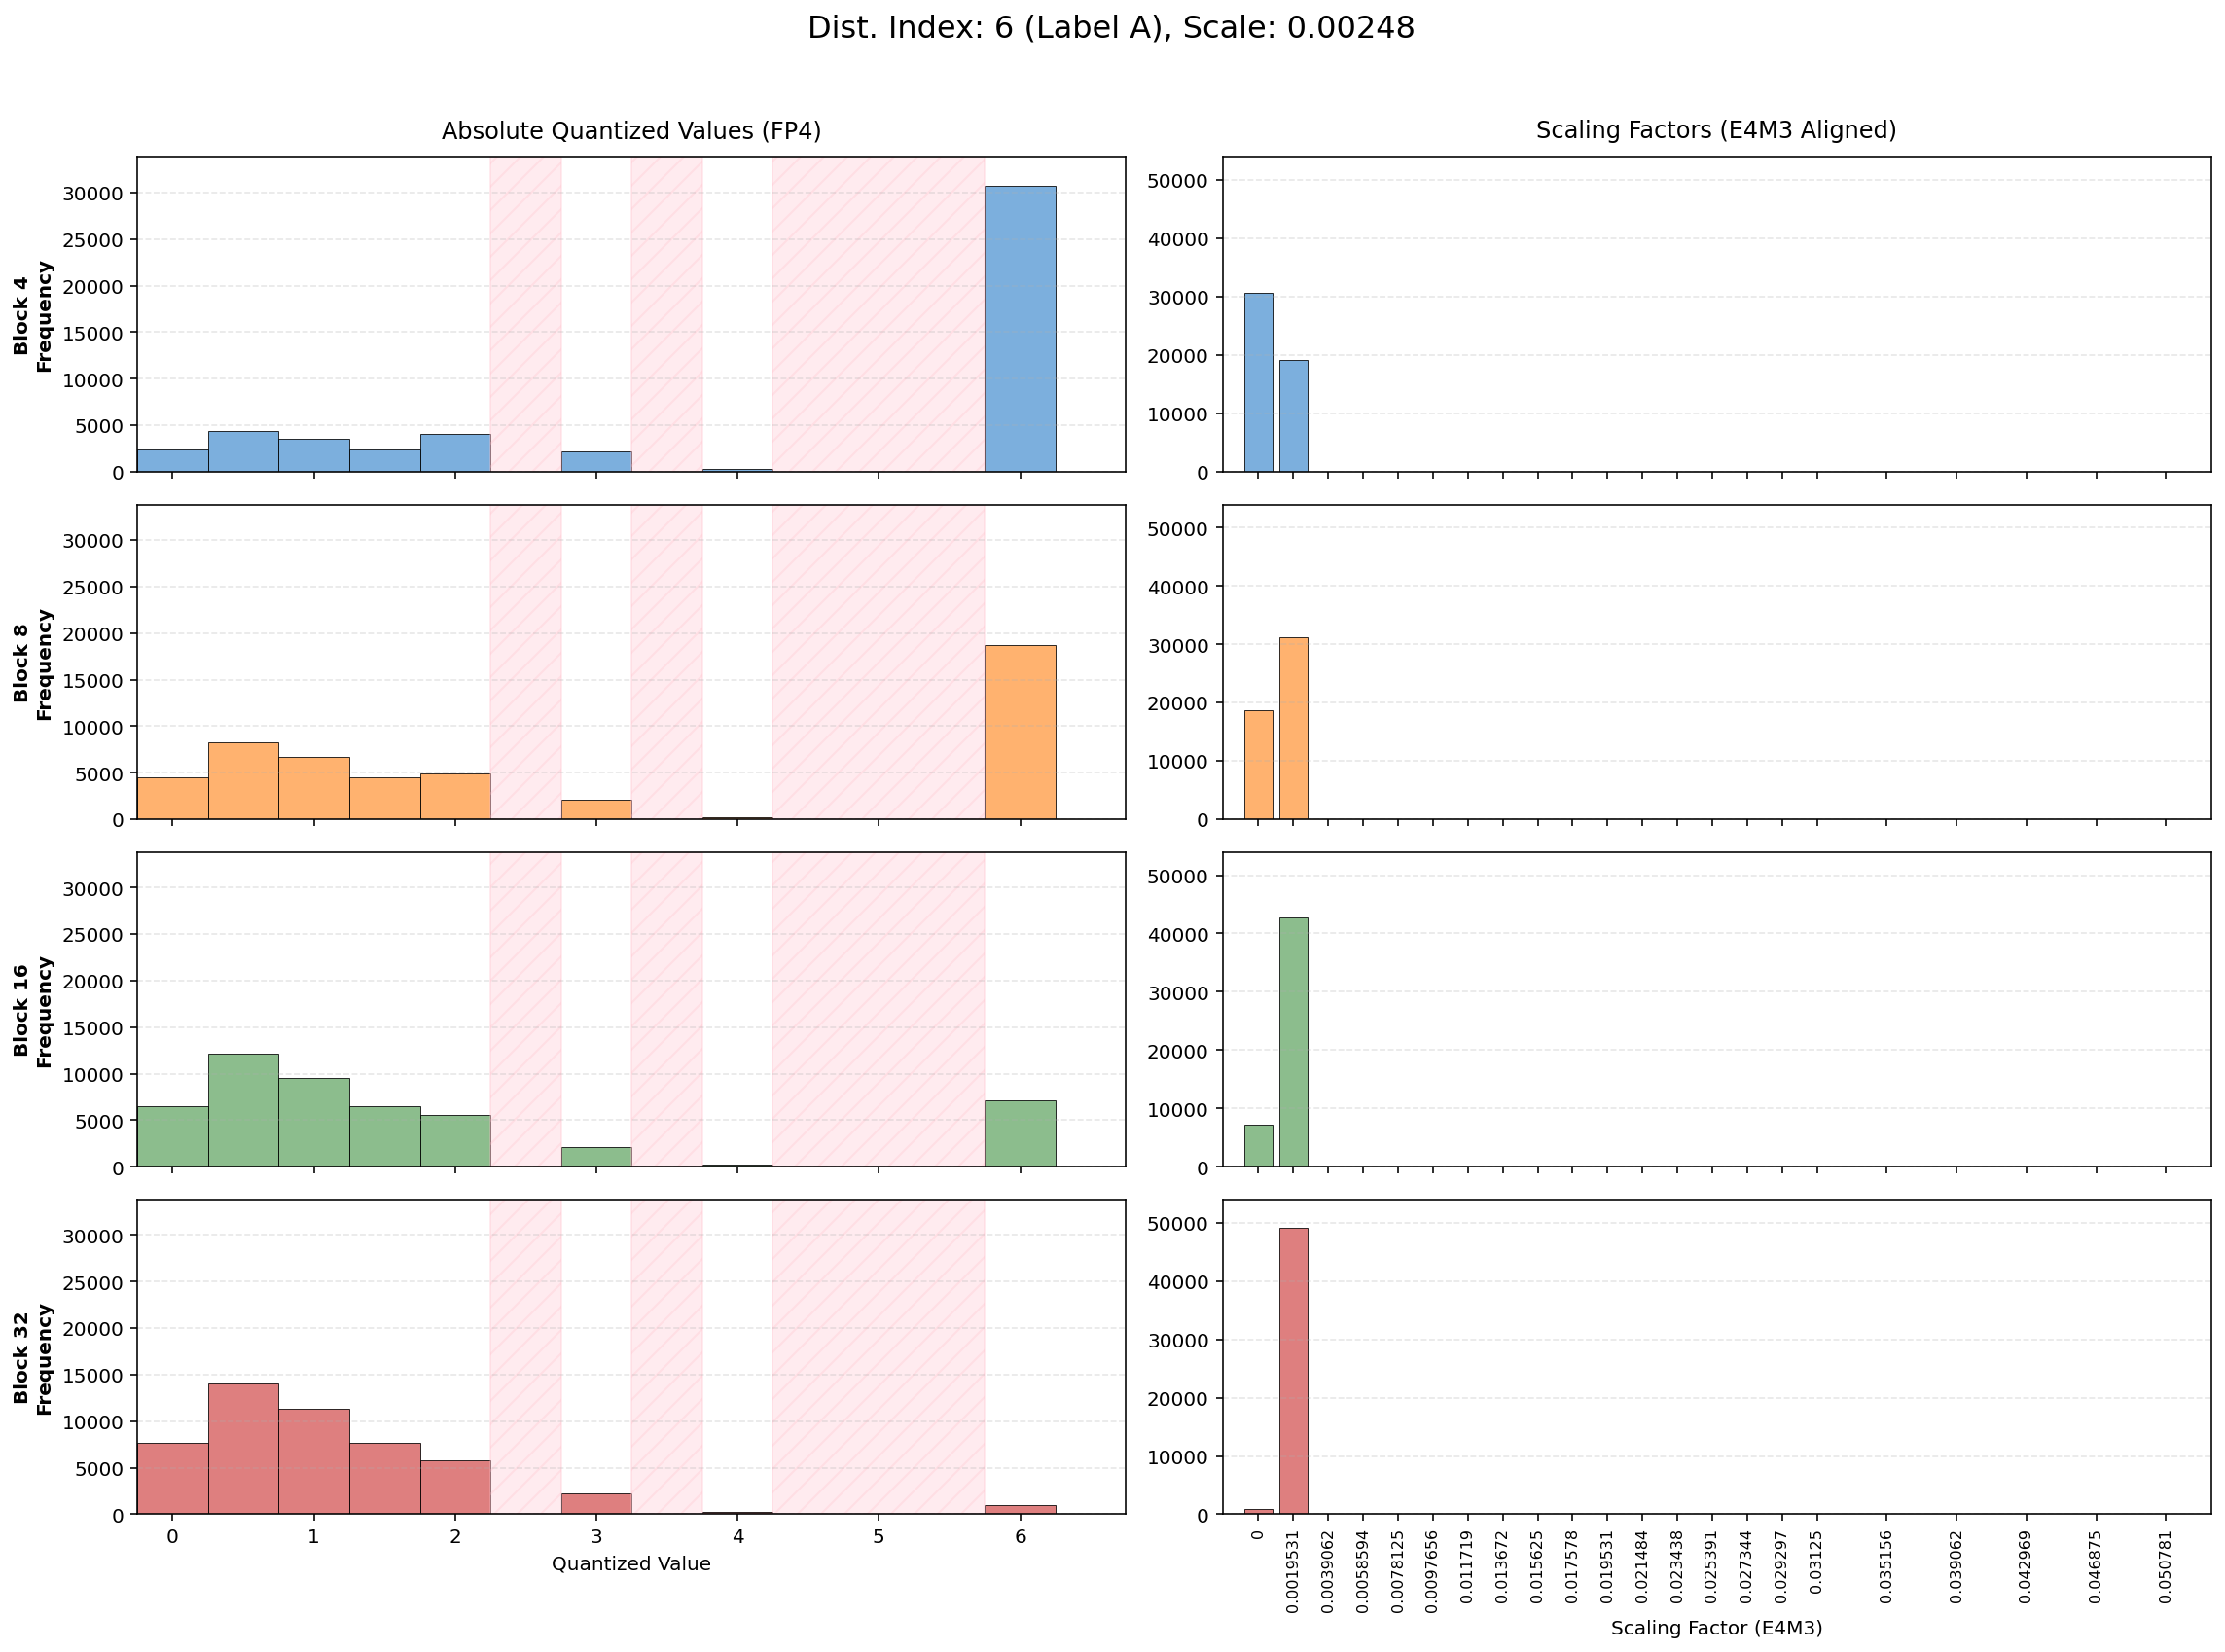

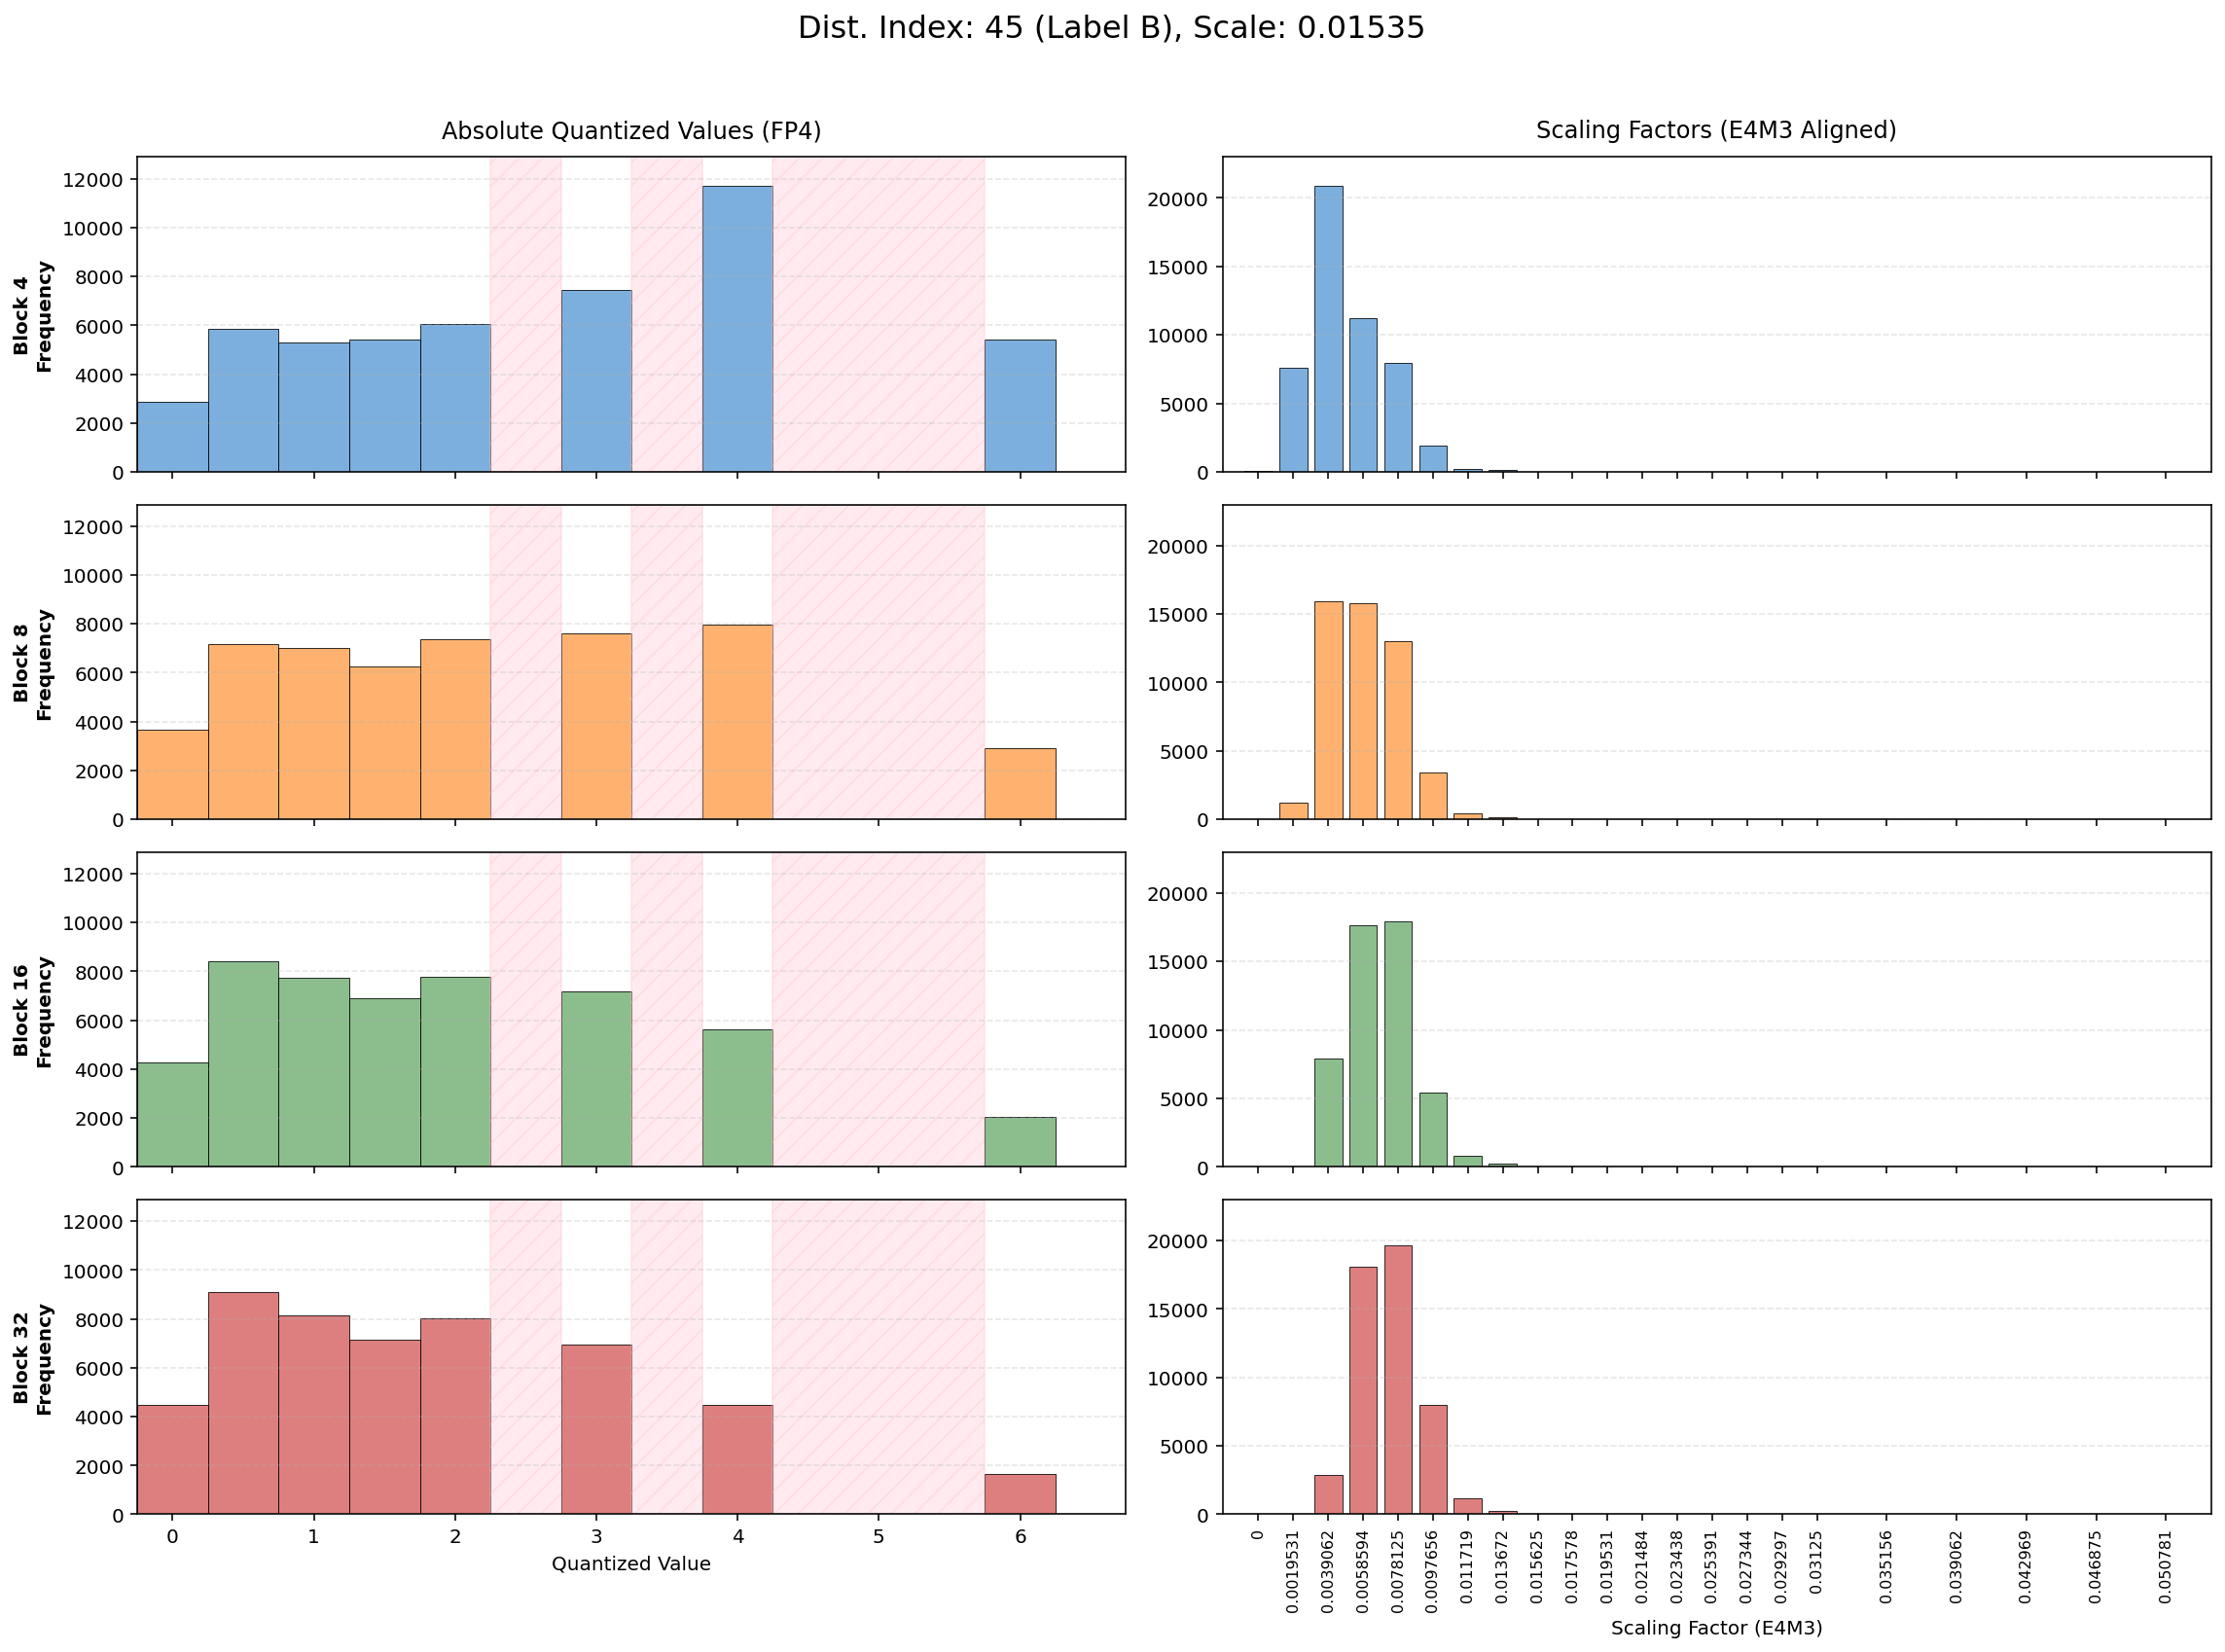

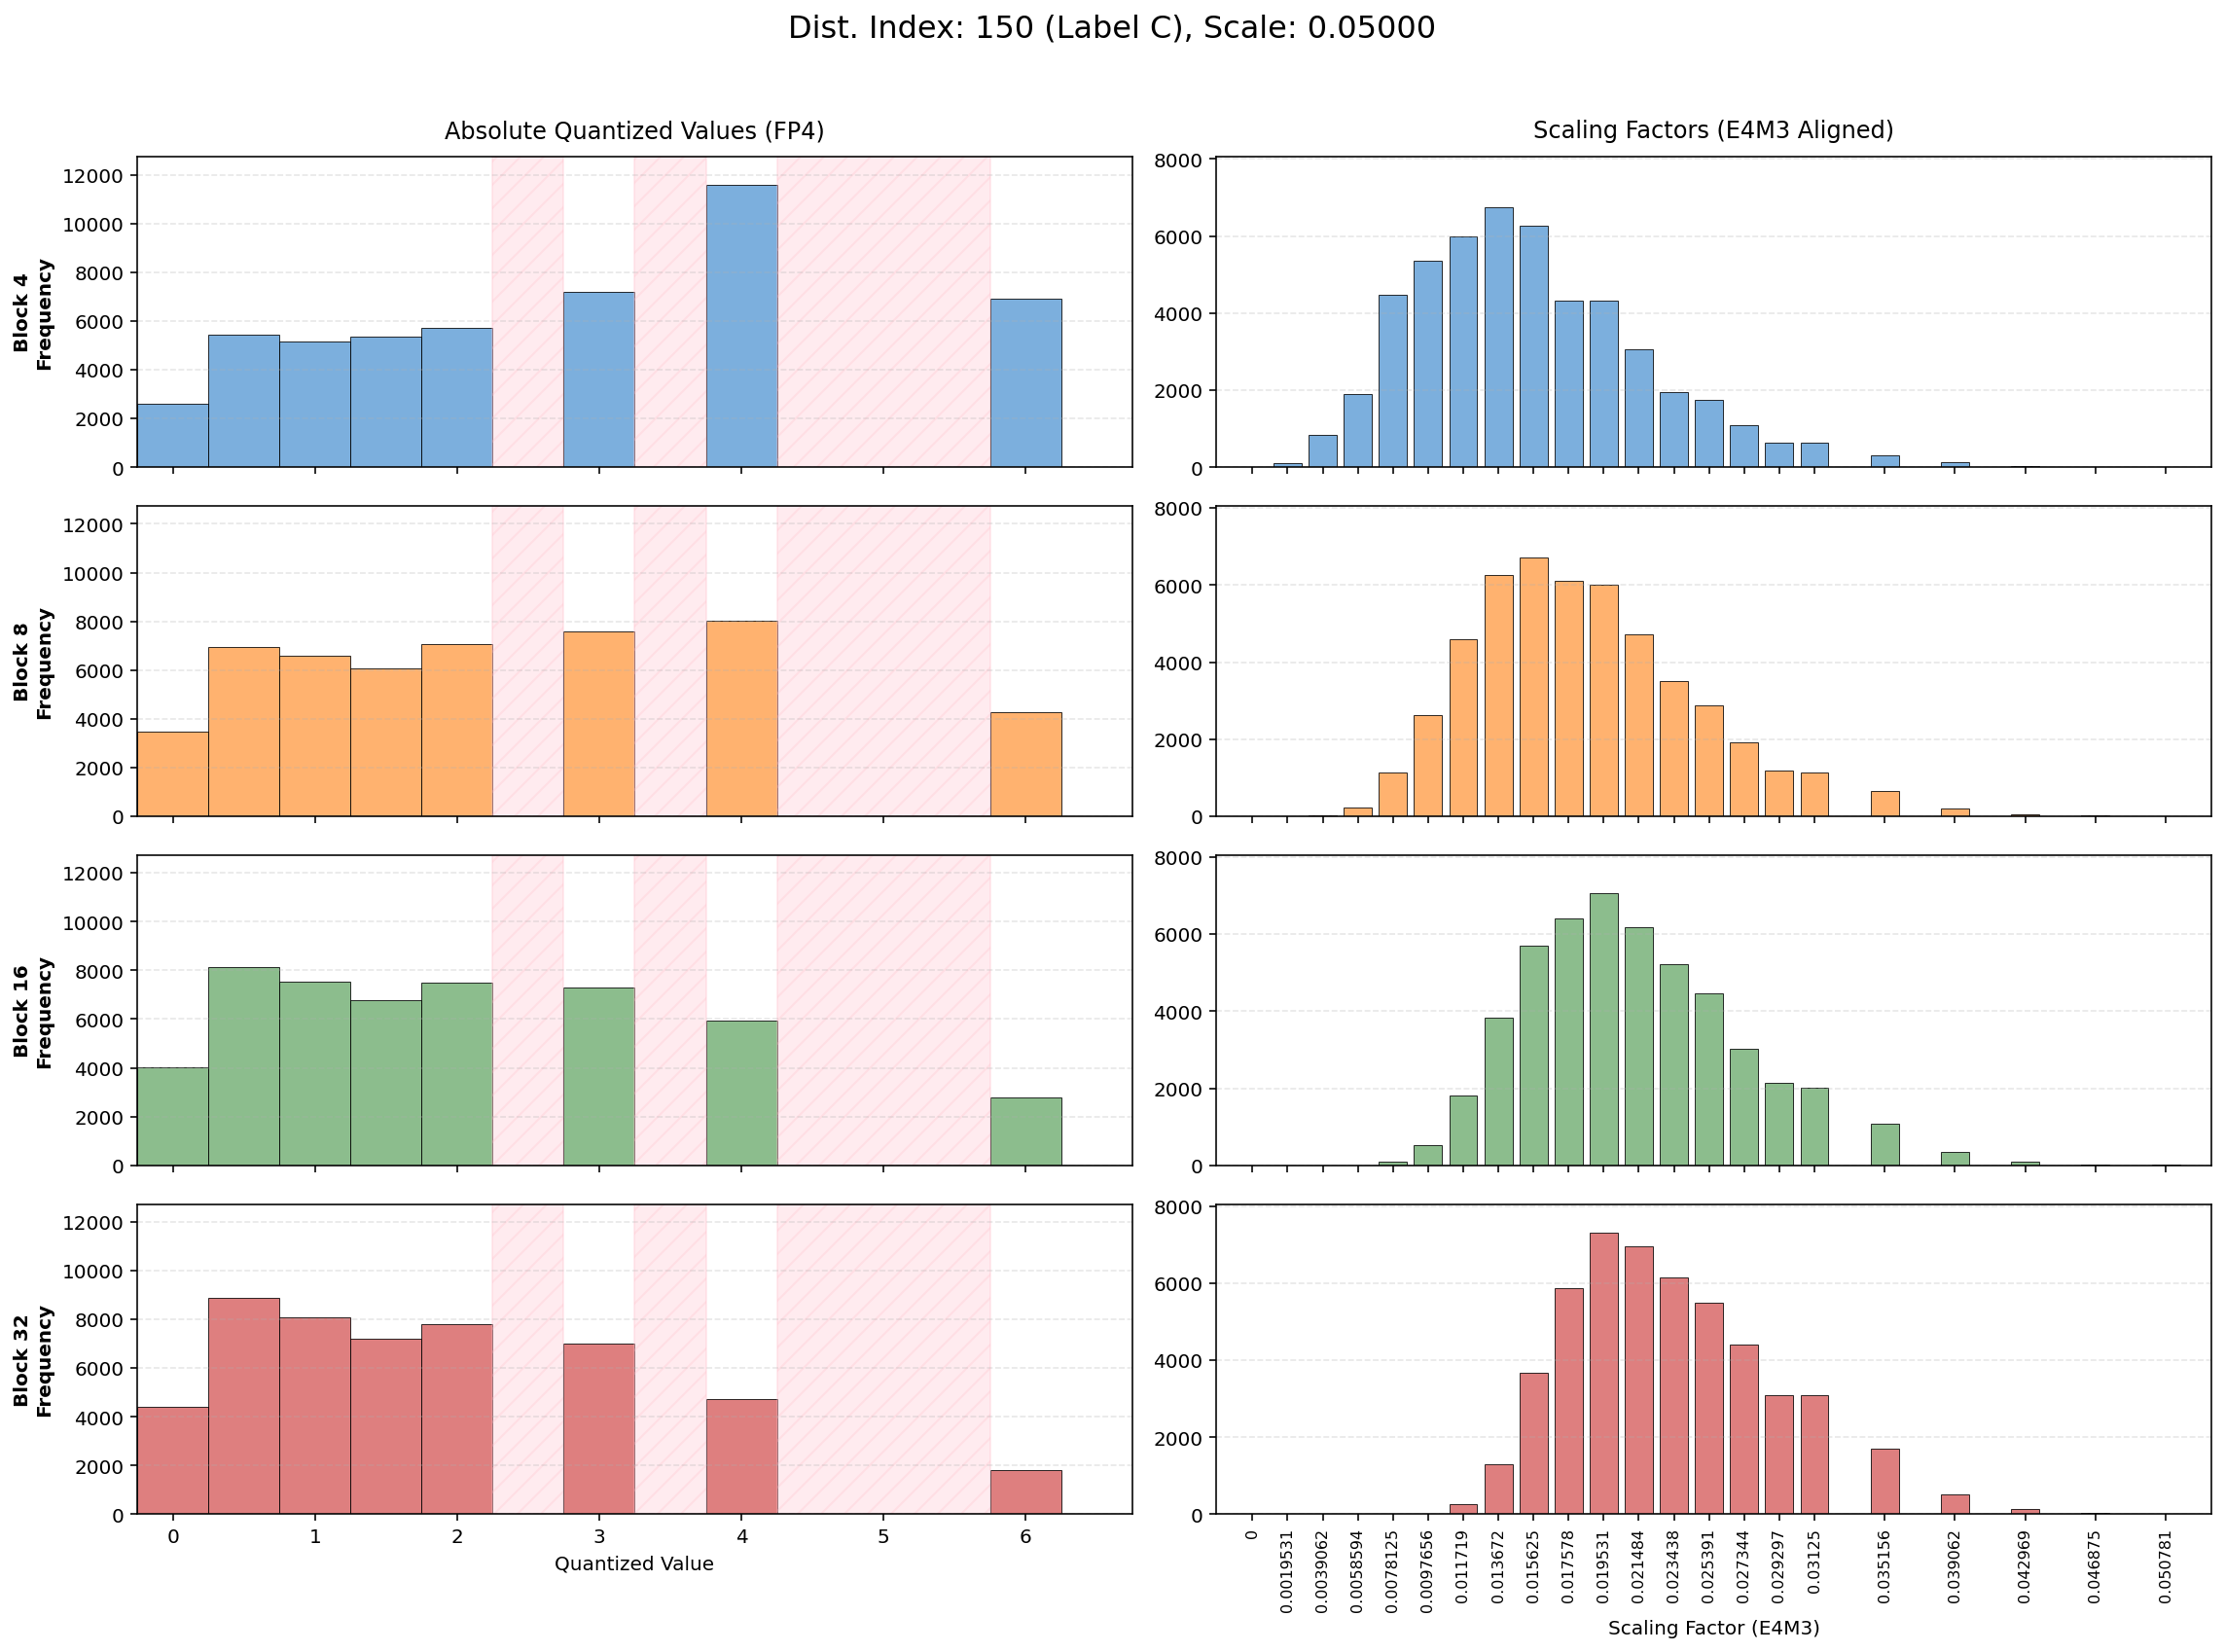

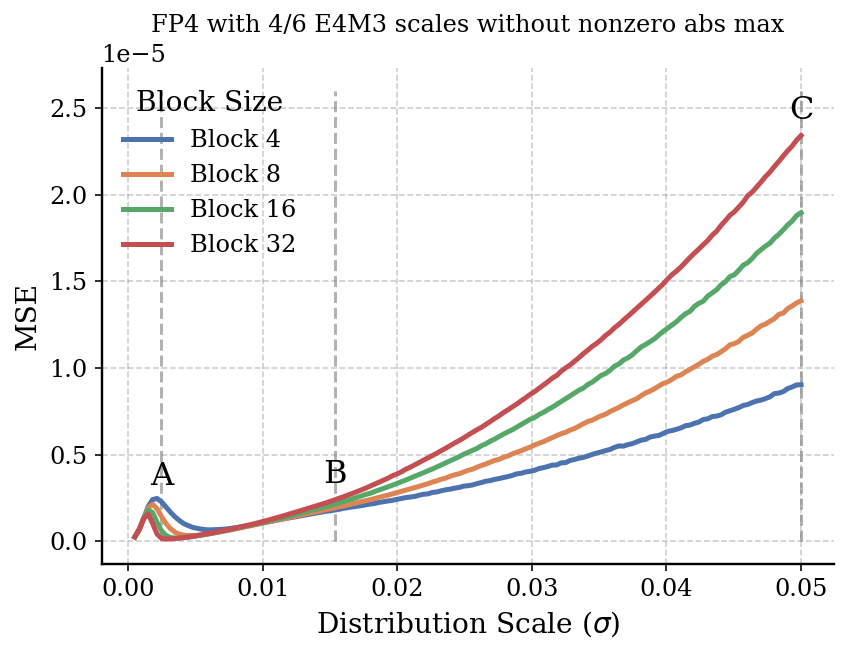

In [9]:
df_fp4_4_over_6 = run_error_experiment(lambda x: four_over_six_quant(x, nonzero_min=False), quant_type='fp4', title="FP4 with 4/6 E4M3 scales without nonzero abs max")

## 4/6 with nonzero abs max

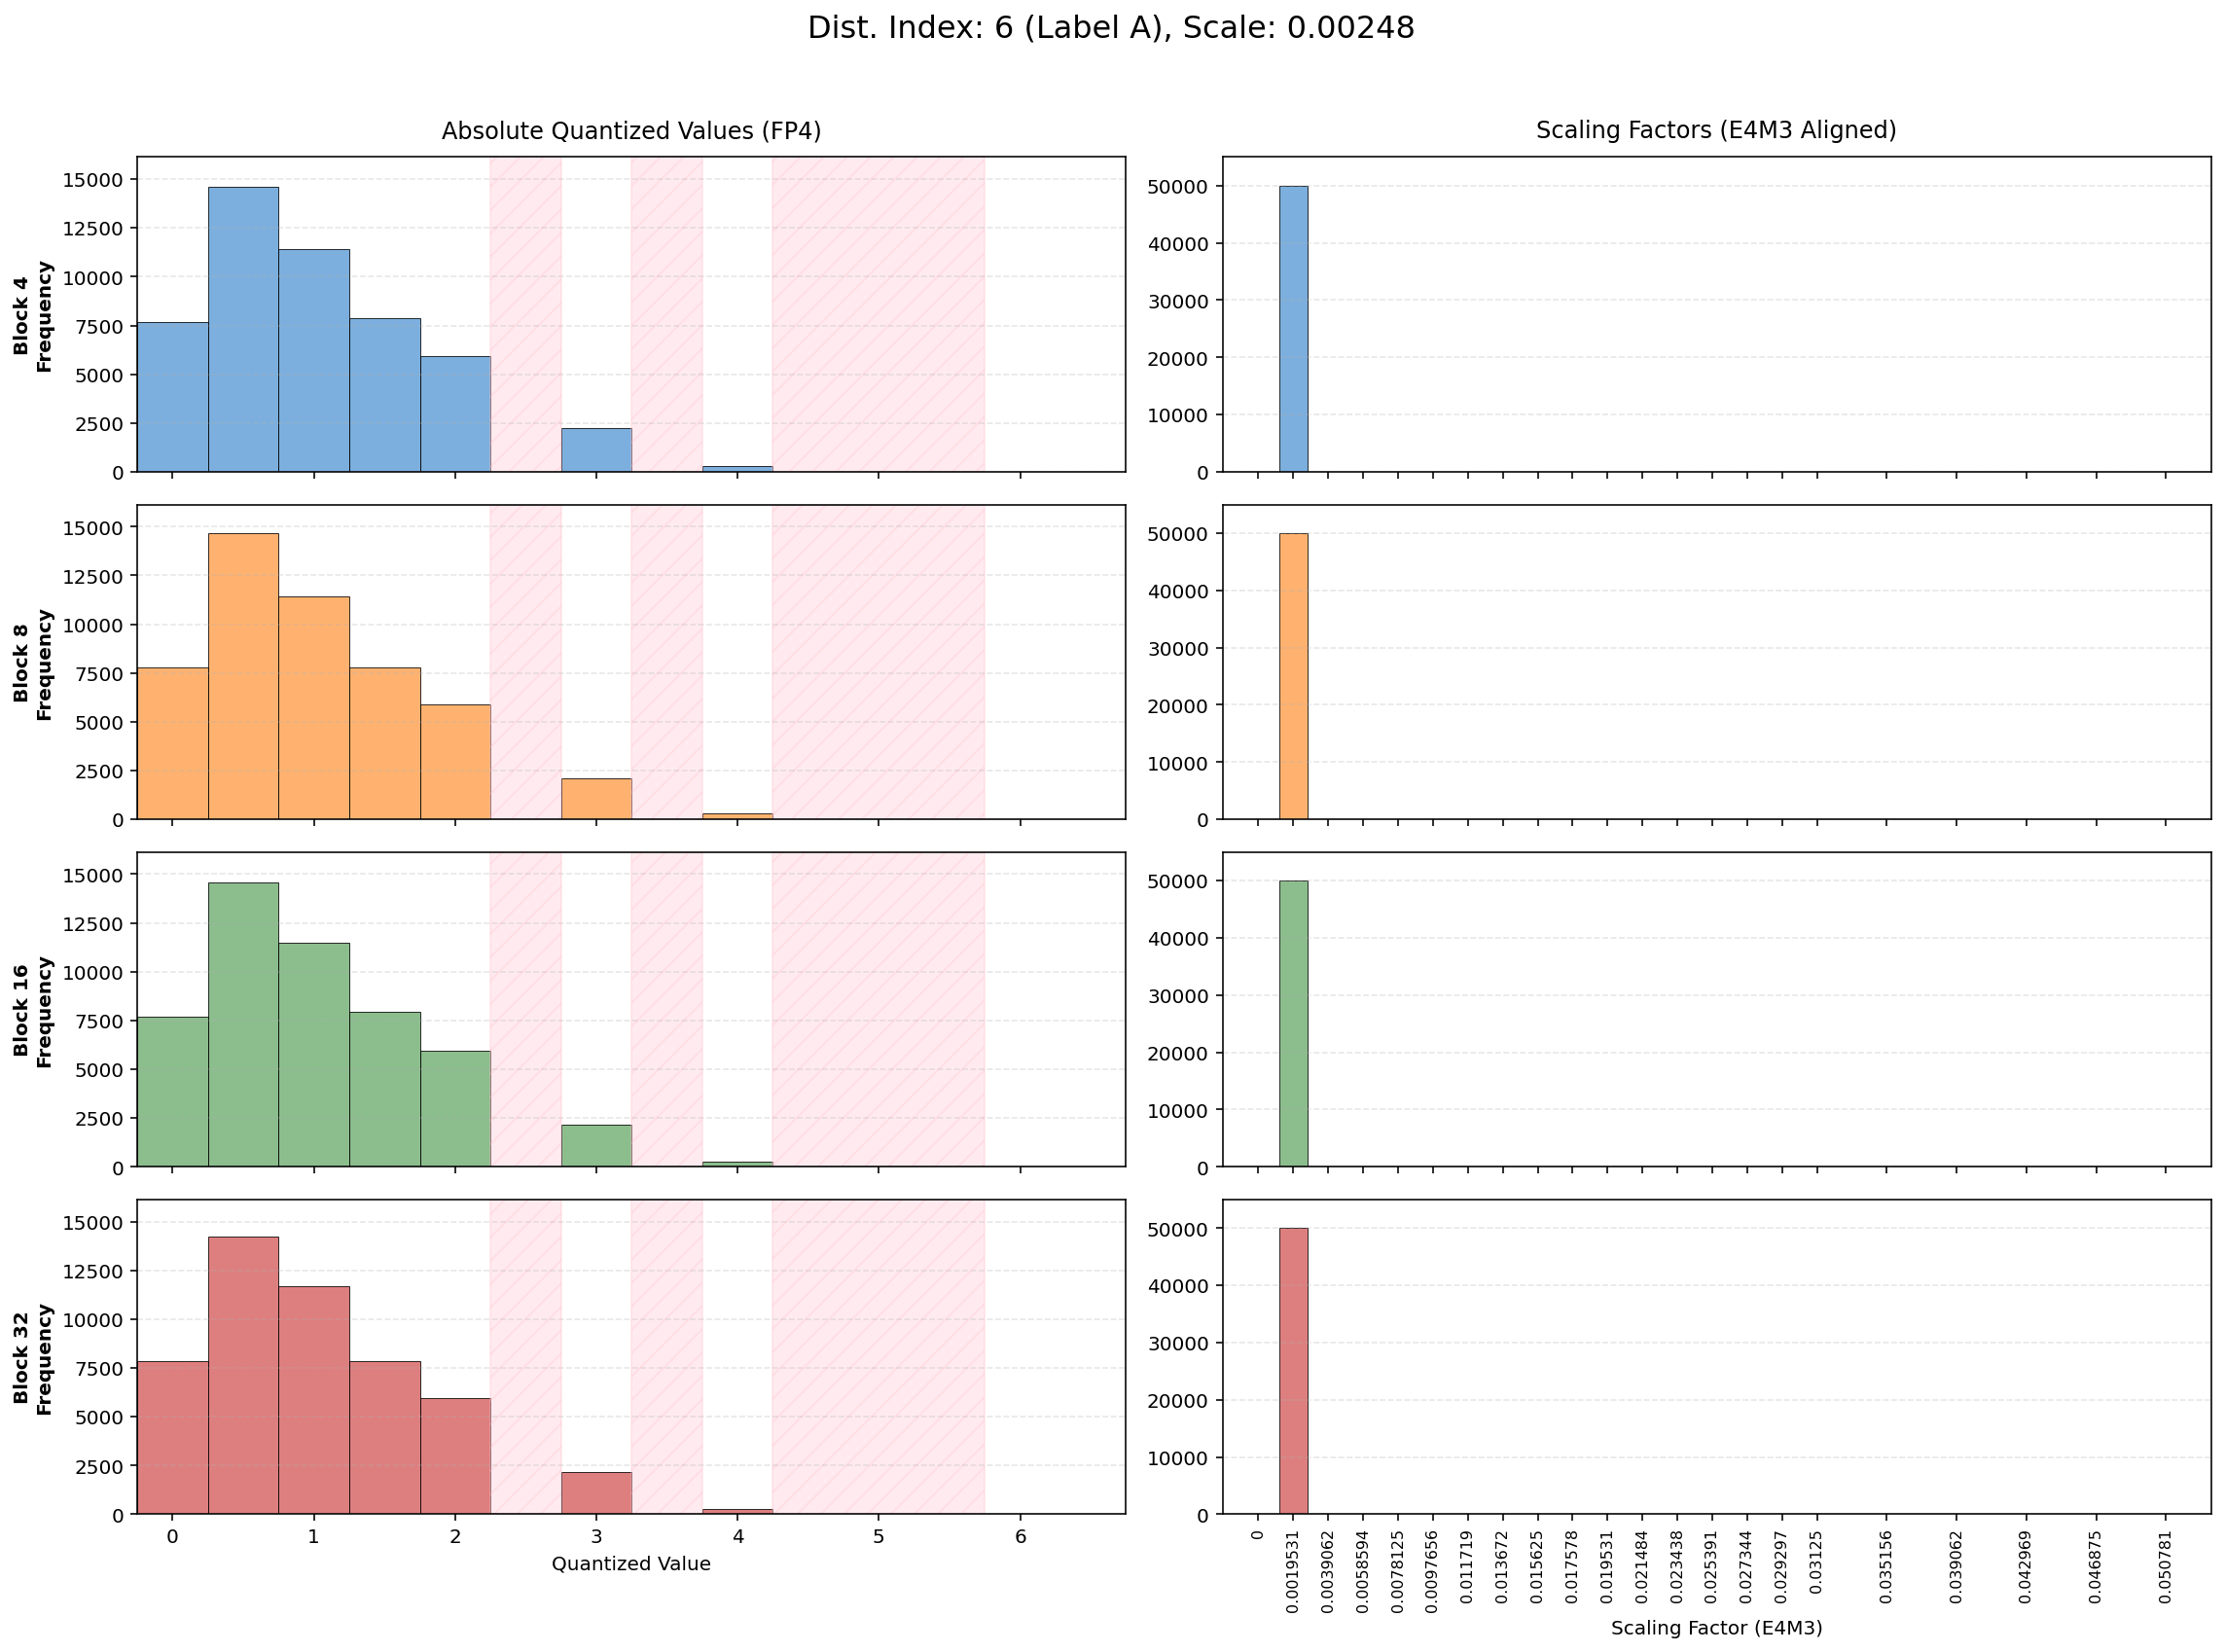

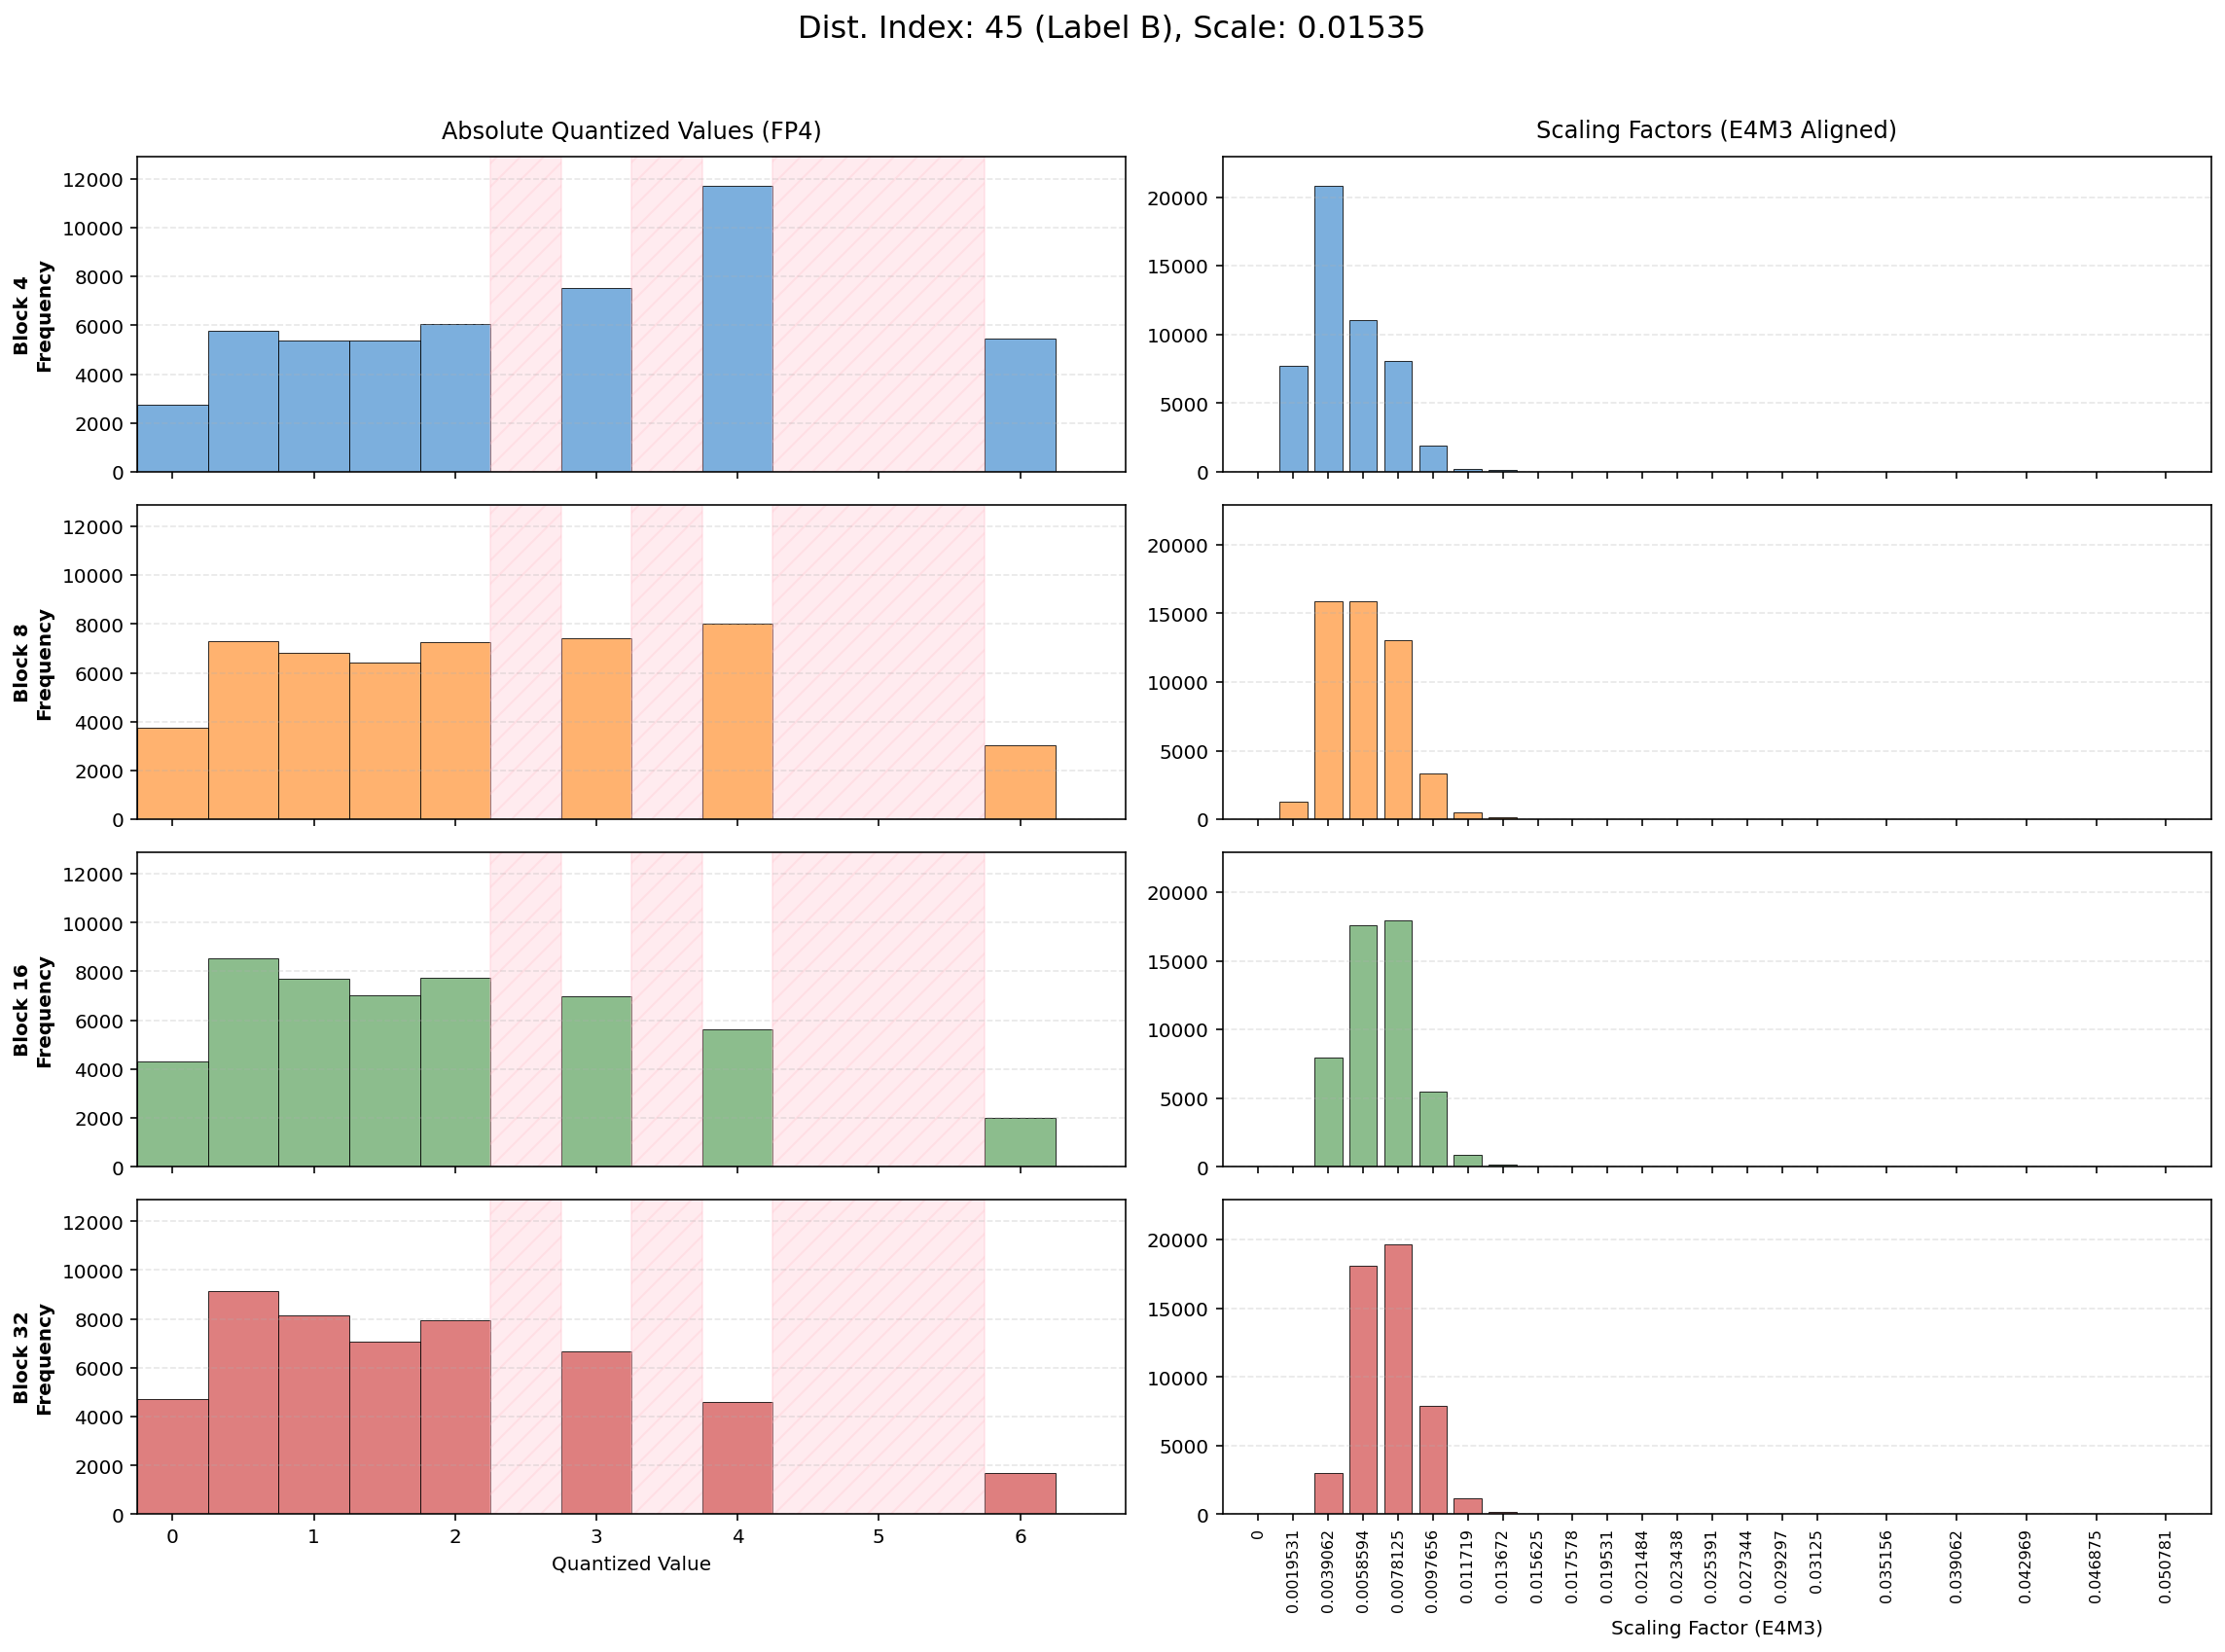

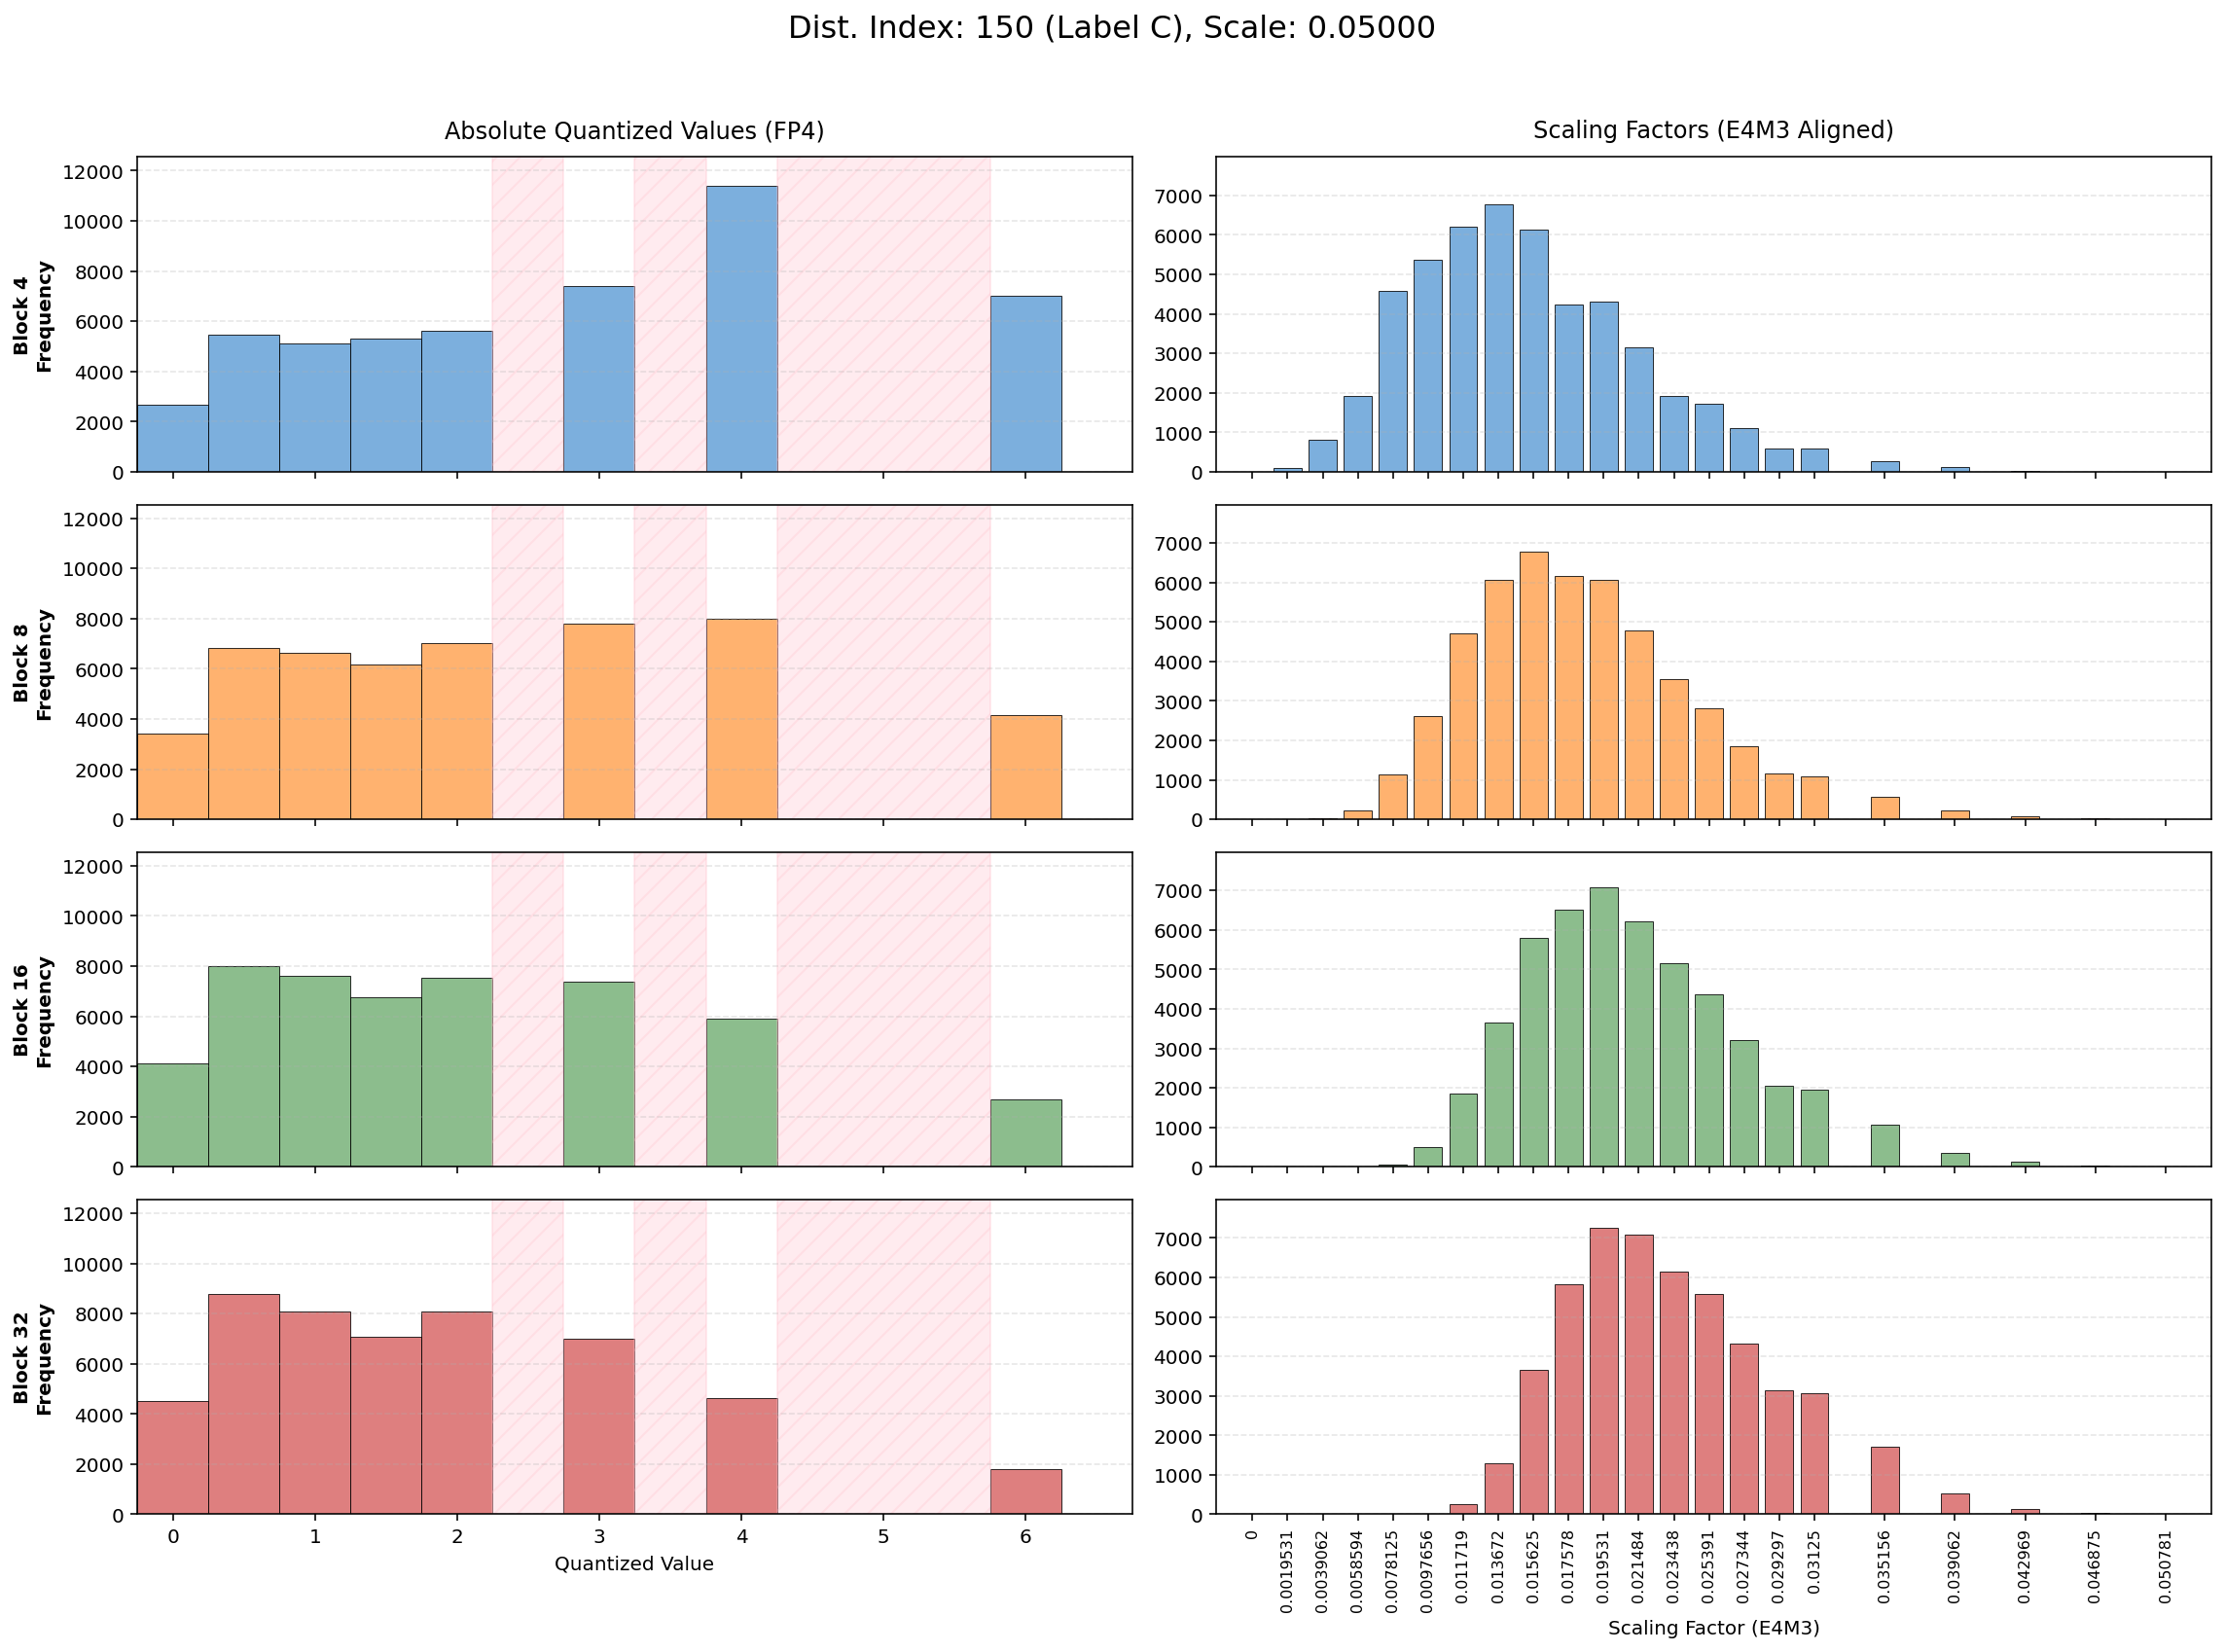

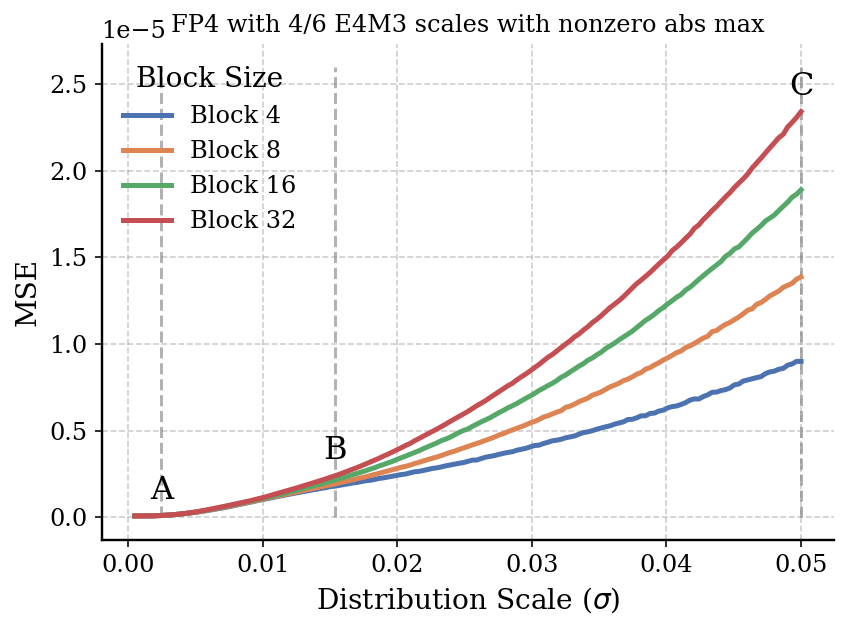

In [10]:
df_fp4_nonzero_4_over_6 = run_error_experiment(lambda x: four_over_six_quant(x, nonzero_min=True), quant_type='fp4', title="FP4 with 4/6 E4M3 scales with nonzero abs max")

## Combined MSE plot for paper

Running simulations... (this may take a minute)


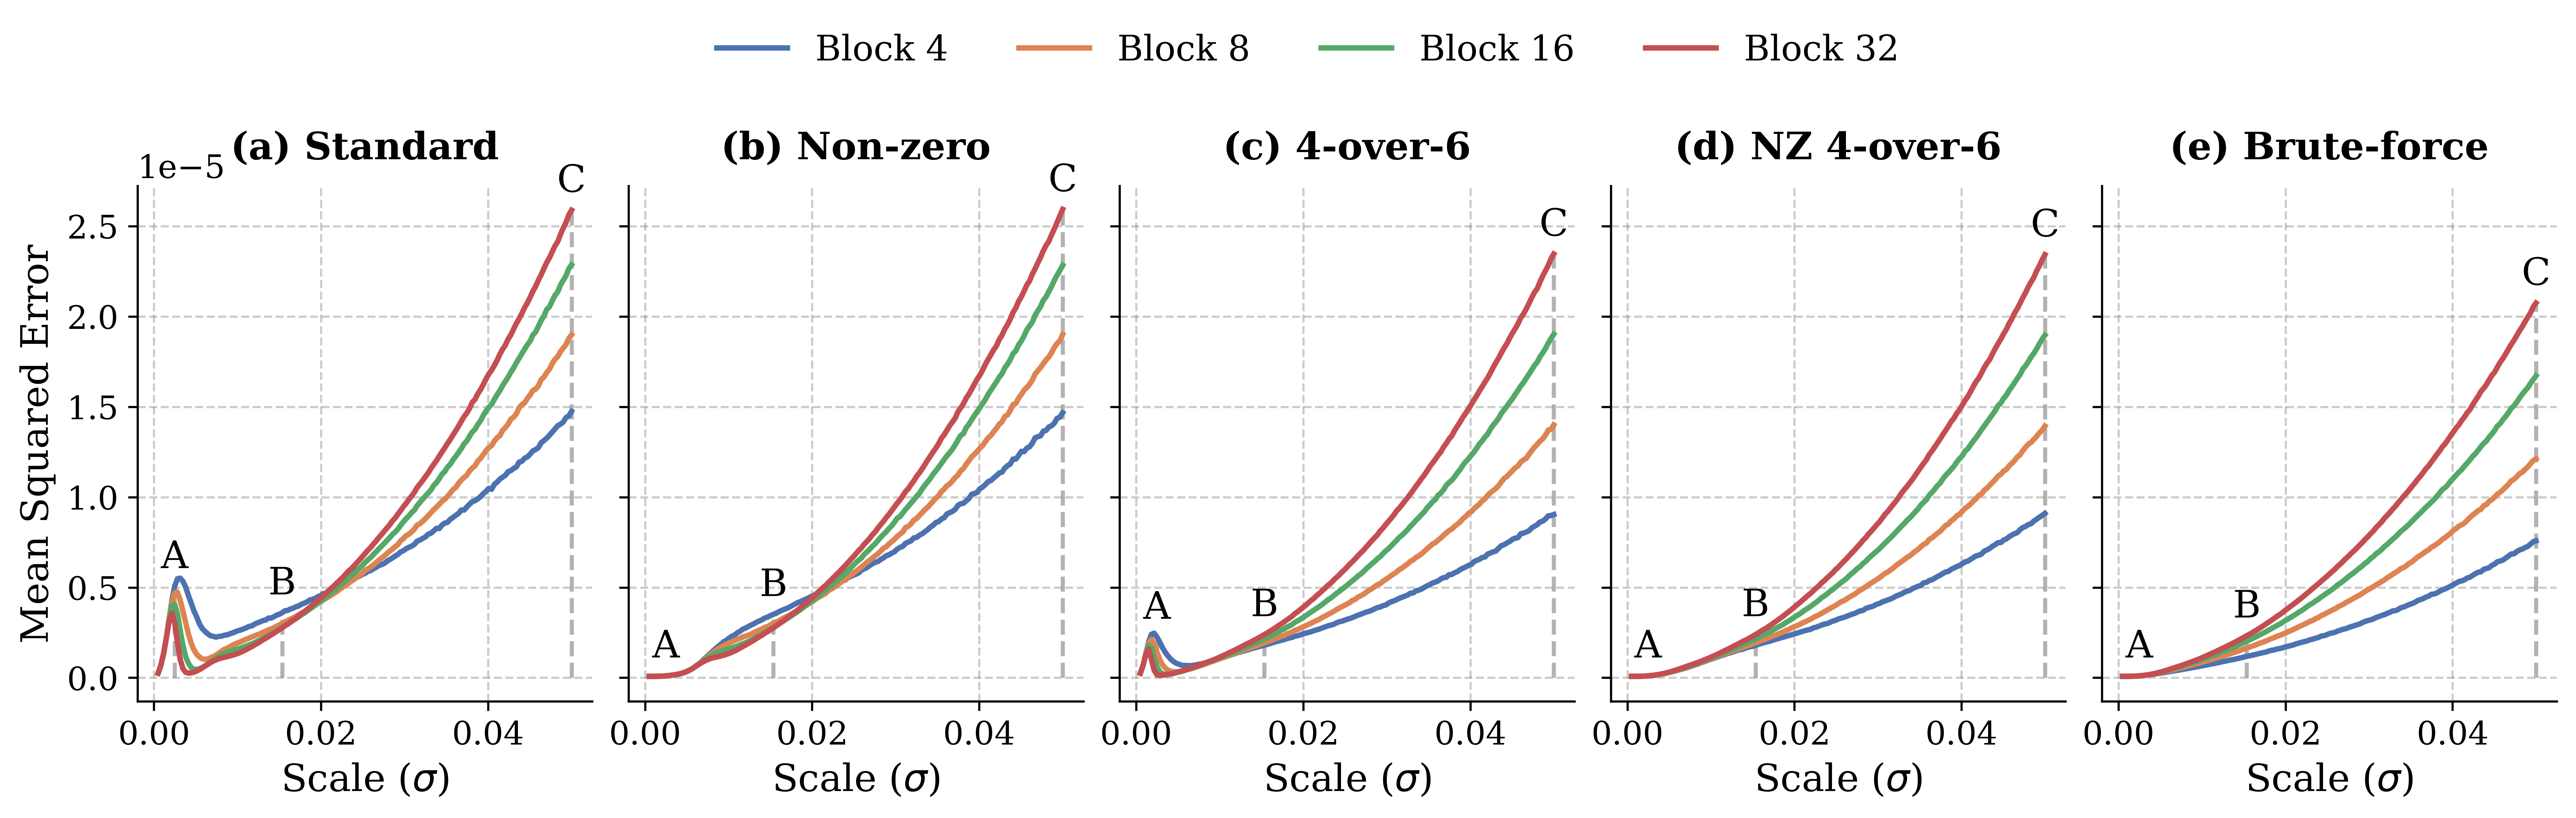

In [ ]:
def get_mse_data(quant_func):
  """Runs the quantization simulation and returns a DataFrame of MSEs."""
  blocks = [4, 8, 16, 32]
  x_range = np.linspace(0.0005, 0.05, 151)
  N_PLOT_POINTS = 50000

  errors = {b: [] for b in blocks}

  for dist_scale in x_range:
    n_scalars = N_PLOT_POINTS * max(blocks)
    dist = np.random.normal(scale=dist_scale, size=n_scalars)

    for block_size in blocks:
      dist_blocked = dist[: N_PLOT_POINTS * block_size].reshape(
          (block_size, -1)
      )
      quant, scaling_factor = quant_func(dist_blocked)
      mse = np.mean((quant * scaling_factor - dist_blocked) ** 2)
      errors[block_size].append(mse)

  return x_range, pd.DataFrame(errors)

print("Running simulations... (this may take a minute)")
x_range, df_standard = get_mse_data(fp4_quant)
_, df_nonzero = get_mse_data(nonzero_fp4_quant)
_, df_4o6 = get_mse_data(lambda x: four_over_six_quant(x, nonzero_min=False))
_, df_nz_4o6 = get_mse_data(lambda x: four_over_six_quant(x, nonzero_min=True))
_, df_search = get_mse_data(lambda x: search_quant(x, quant_type="fp4"))

scenarios = [
    ("Standard", df_standard),
    ("Non-zero", df_nonzero),
    ("4-over-6", df_4o6),
    ("NZ 4-over-6", df_nz_4o6),
    ("Brute-force", df_search),
]

plot_style = {
    "font.family": "serif",
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
}

with plt.rc_context(plot_style):
  # 1 row, 5 columns. 15 inches wide ensures high resolution when shrunk.
  fig, axes = plt.subplots(
      1, 5, figsize=(16, 3.5), sharex=True, sharey=True, dpi=300
  )

  colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
  blocks = [4, 8, 16, 32]

  plot_indices = [6, 45, 150]
  plot_labels_text = ["A", "B", "C"]

  for ax_idx, (title, df) in enumerate(scenarios):
    ax = axes[ax_idx]

    for i, b in enumerate(blocks):
      ax.plot(x_range, df[b], linewidth=2, color=colors[i], label=f"Block {b}")

    ax.set_title(
        f"({chr(97+ax_idx)}) {title}", fontsize=14, pad=10, fontweight="bold"
    )

    # Add vertical drop lines for A, B, C
    for i, idx in enumerate(plot_indices):
      x_val = x_range[idx]
      max_y = df.iloc[idx].max()
      ax.vlines(
          x=x_val,
          ymin=0,
          ymax=max_y,
          color="gray",
          linestyle="--",
          alpha=0.6,
          zorder=1,
      )

      ax.annotate(
          plot_labels_text[i],
          xy=(x_val, max_y),
          xytext=(0, 4),
          textcoords="offset points",
          ha="center",
          va="bottom",
          fontsize=14,
      )

    ax.grid(True, linestyle="--", alpha=0.4, color="gray", zorder=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Add a compact X-axis label to every plot
    ax.set_xlabel(r"Scale ($\sigma$)")

  # Format the sole Y-axis on the far left
  axes[0].set_ylabel("Mean Squared Error")
  axes[0].ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

  # Global Shared Legend at the very top
  handles, labels = axes[0].get_legend_handles_labels()
  fig.legend(
      handles,
      labels,
      loc="upper center",
      bbox_to_anchor=(0.5, 1.15),
      ncol=4,
      frameon=False,
      fontsize=13,
  )
  plt.subplots_adjust(wspace=0.08)
  plt.show()

## Secondary plot for clipping only component of MSE

Running simulations... (this may take a minute)


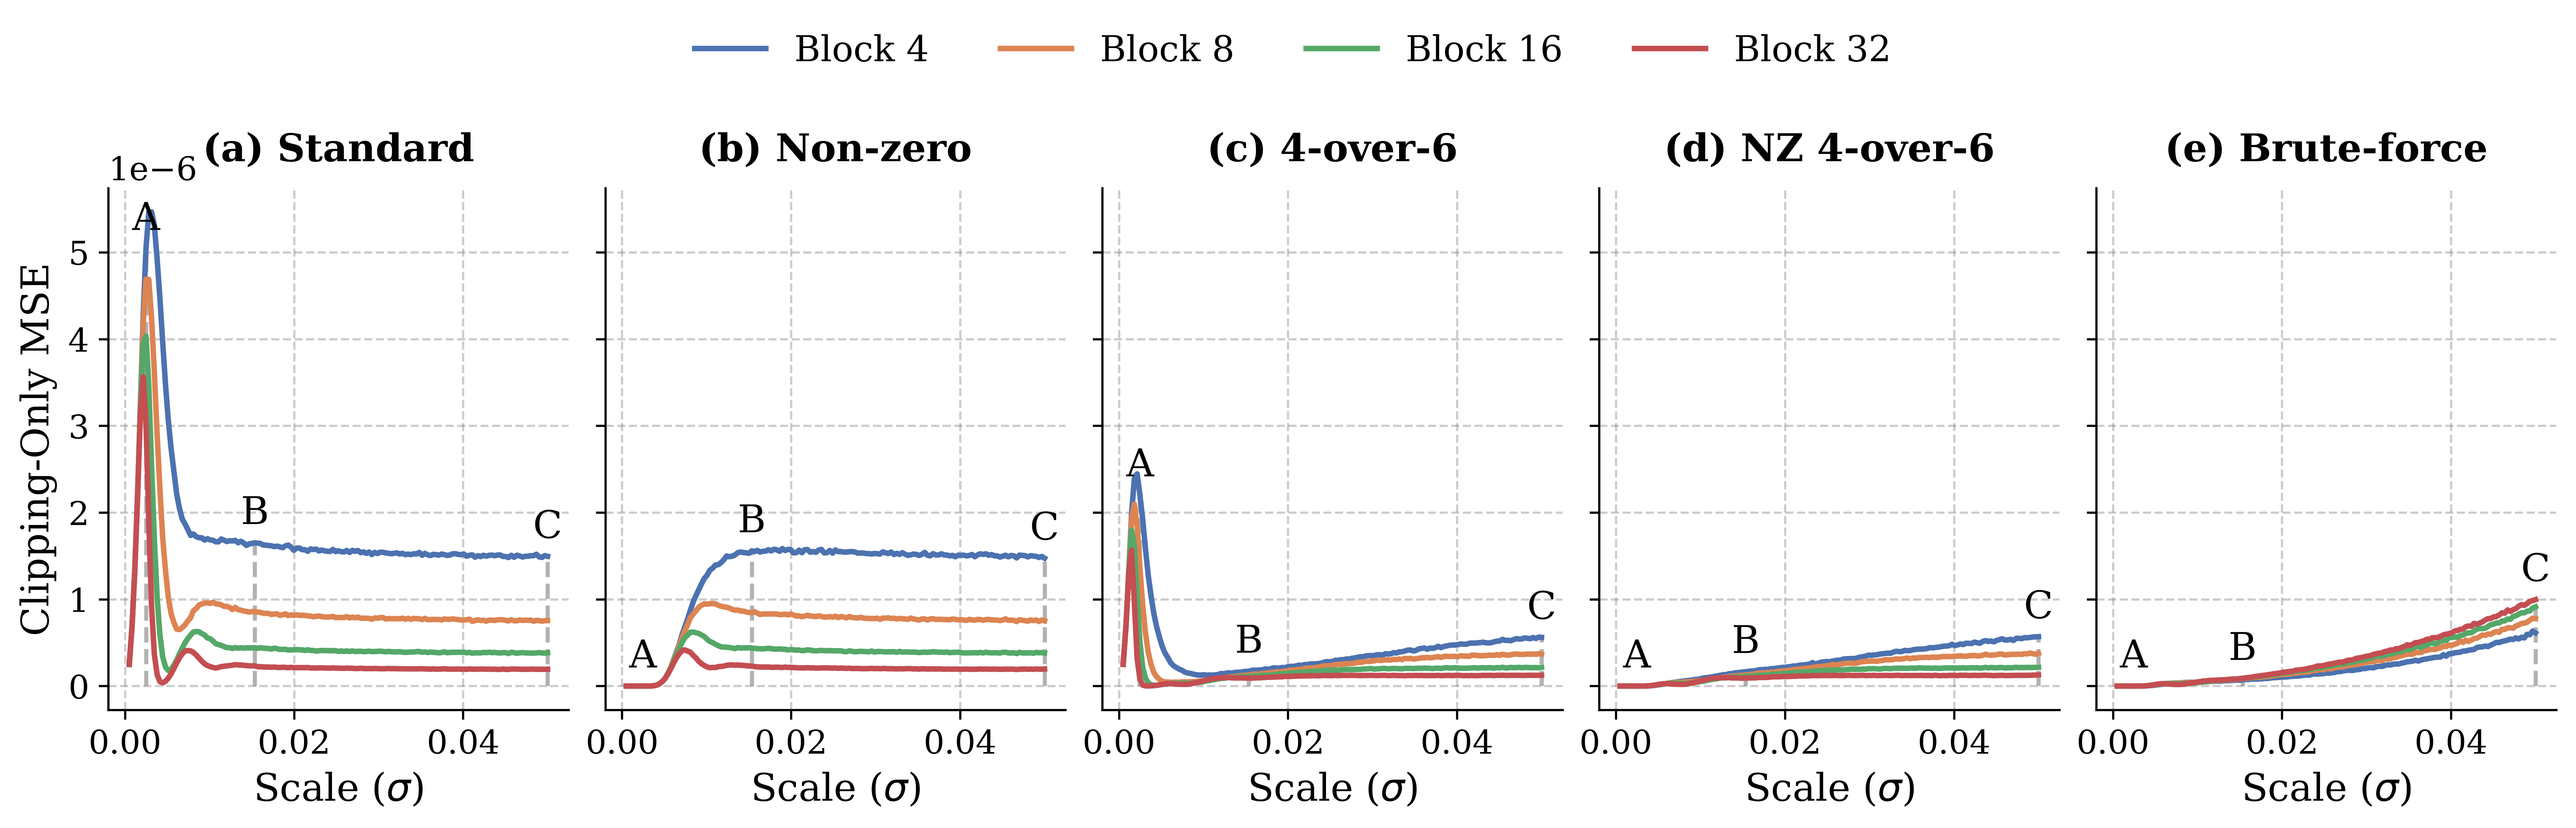

In [11]:
def get_mse_data_clipping(quant_func, quant_type="fp4"):
    """Runs the quantization simulation and returns a DataFrame of Clipping-Only MSEs."""
    blocks = [4, 8, 16, 32]
    x_range = np.linspace(0.0005, 0.05, 151)
    N_PLOT_POINTS = 50000

    errors = {b: [] for b in blocks}

    # FP4 absolute max is 6.0, INT4 is 7.0
    if quant_type == "int4":
      max_q_val = 7.0
    elif quant_type == "fp4":
      max_q_val = 6.0
    else:
      raise ValueError()

    for dist_scale in x_range:
        n_scalars = N_PLOT_POINTS * max(blocks)
        dist = np.random.normal(scale=dist_scale, size=n_scalars)

        for block_size in blocks:
            dist_blocked = dist[: N_PLOT_POINTS * block_size].reshape(
                (block_size, -1)
            )
            _, scaling_factor = quant_func(dist_blocked)

            # Isolate the Clipping Error
            sf_np = np.array(scaling_factor)

            # Clip the original distribution to the bounds defined by the scale.
            # Everything inside this boundary is untouched (ignoring rounding error).
            clipped_dist = np.clip(dist_blocked, -max_q_val * sf_np, max_q_val * sf_np)

            # MSE against the purely clipped version
            clip_mse = np.mean((clipped_dist - dist_blocked) ** 2)
            errors[block_size].append(clip_mse)

    return x_range, pd.DataFrame(errors)


print("Running simulations... (this may take a minute)")
x_range, df_standard = get_mse_data_clipping(fp4_quant, "fp4")
_, df_nonzero = get_mse_data_clipping(nonzero_fp4_quant, "fp4")
_, df_4o6 = get_mse_data_clipping(
    lambda x: four_over_six_quant(x, nonzero_min=False), "fp4"
)
_, df_nz_4o6 = get_mse_data_clipping(
    lambda x: four_over_six_quant(x, nonzero_min=True), "fp4"
)
_, df_search = get_mse_data_clipping(lambda x: search_quant(x, quant_type="fp4"), "fp4")

scenarios = [
    ("Standard", df_standard),
    ("Non-zero", df_nonzero),
    ("4-over-6", df_4o6),
    ("NZ 4-over-6", df_nz_4o6),
    ("Brute-force", df_search),
]

# --- 2. Plotting ---
plot_style = {
    "font.family": "serif",
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
}

with plt.rc_context(plot_style):
    # 1 row, 5 columns. 15 inches wide ensures high resolution when shrunk.
    fig, axes = plt.subplots(
        1, 5, figsize=(16, 3.5), sharex=True, sharey=True, dpi=300
    )

    colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
    blocks = [4, 8, 16, 32]

    plot_indices = [6, 45, 150]
    plot_labels_text = ["A", "B", "C"]

    for ax_idx, (title, df) in enumerate(scenarios):
        ax = axes[ax_idx]

        # Plot lines
        for i, b in enumerate(blocks):
            ax.plot(x_range, df[b], linewidth=2, color=colors[i], label=f"Block {b}")

        # Put the title above each subplot
        ax.set_title(
            f"({chr(97+ax_idx)}) {title}", fontsize=14, pad=10, fontweight="bold"
        )

        # Add vertical drop lines for A, B, C
        for i, idx in enumerate(plot_indices):
            x_val = x_range[idx]
            max_y = df.iloc[idx].max()

            ax.vlines(
                x=x_val,
                ymin=0,
                ymax=max_y,
                color="gray",
                linestyle="--",
                alpha=0.6,
                zorder=1,
            )

            ax.annotate(
                plot_labels_text[i],
                xy=(x_val, max_y),
                xytext=(0, 4),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=14,
            )

        ax.grid(True, linestyle="--", alpha=0.4, color="gray", zorder=0)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # Add a compact X-axis label to every plot
        ax.set_xlabel(r"Scale ($\sigma$)")

    # Format the sole Y-axis on the far left
    axes[0].set_ylabel("Clipping-Only MSE")
    axes[0].ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

    # Global Shared Legend at the very top
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.15),
        ncol=4,
        frameon=False,
        fontsize=13,
    )

    # Squish the horizontal gap between plots
    plt.subplots_adjust(wspace=0.08)

    # Save to the current directory
    plt.savefig("FP4_Horizontal_Clipping_Only.pdf", bbox_inches="tight", pad_inches=0.05)
    plt.show()

# INT4

## E4M3 abs max

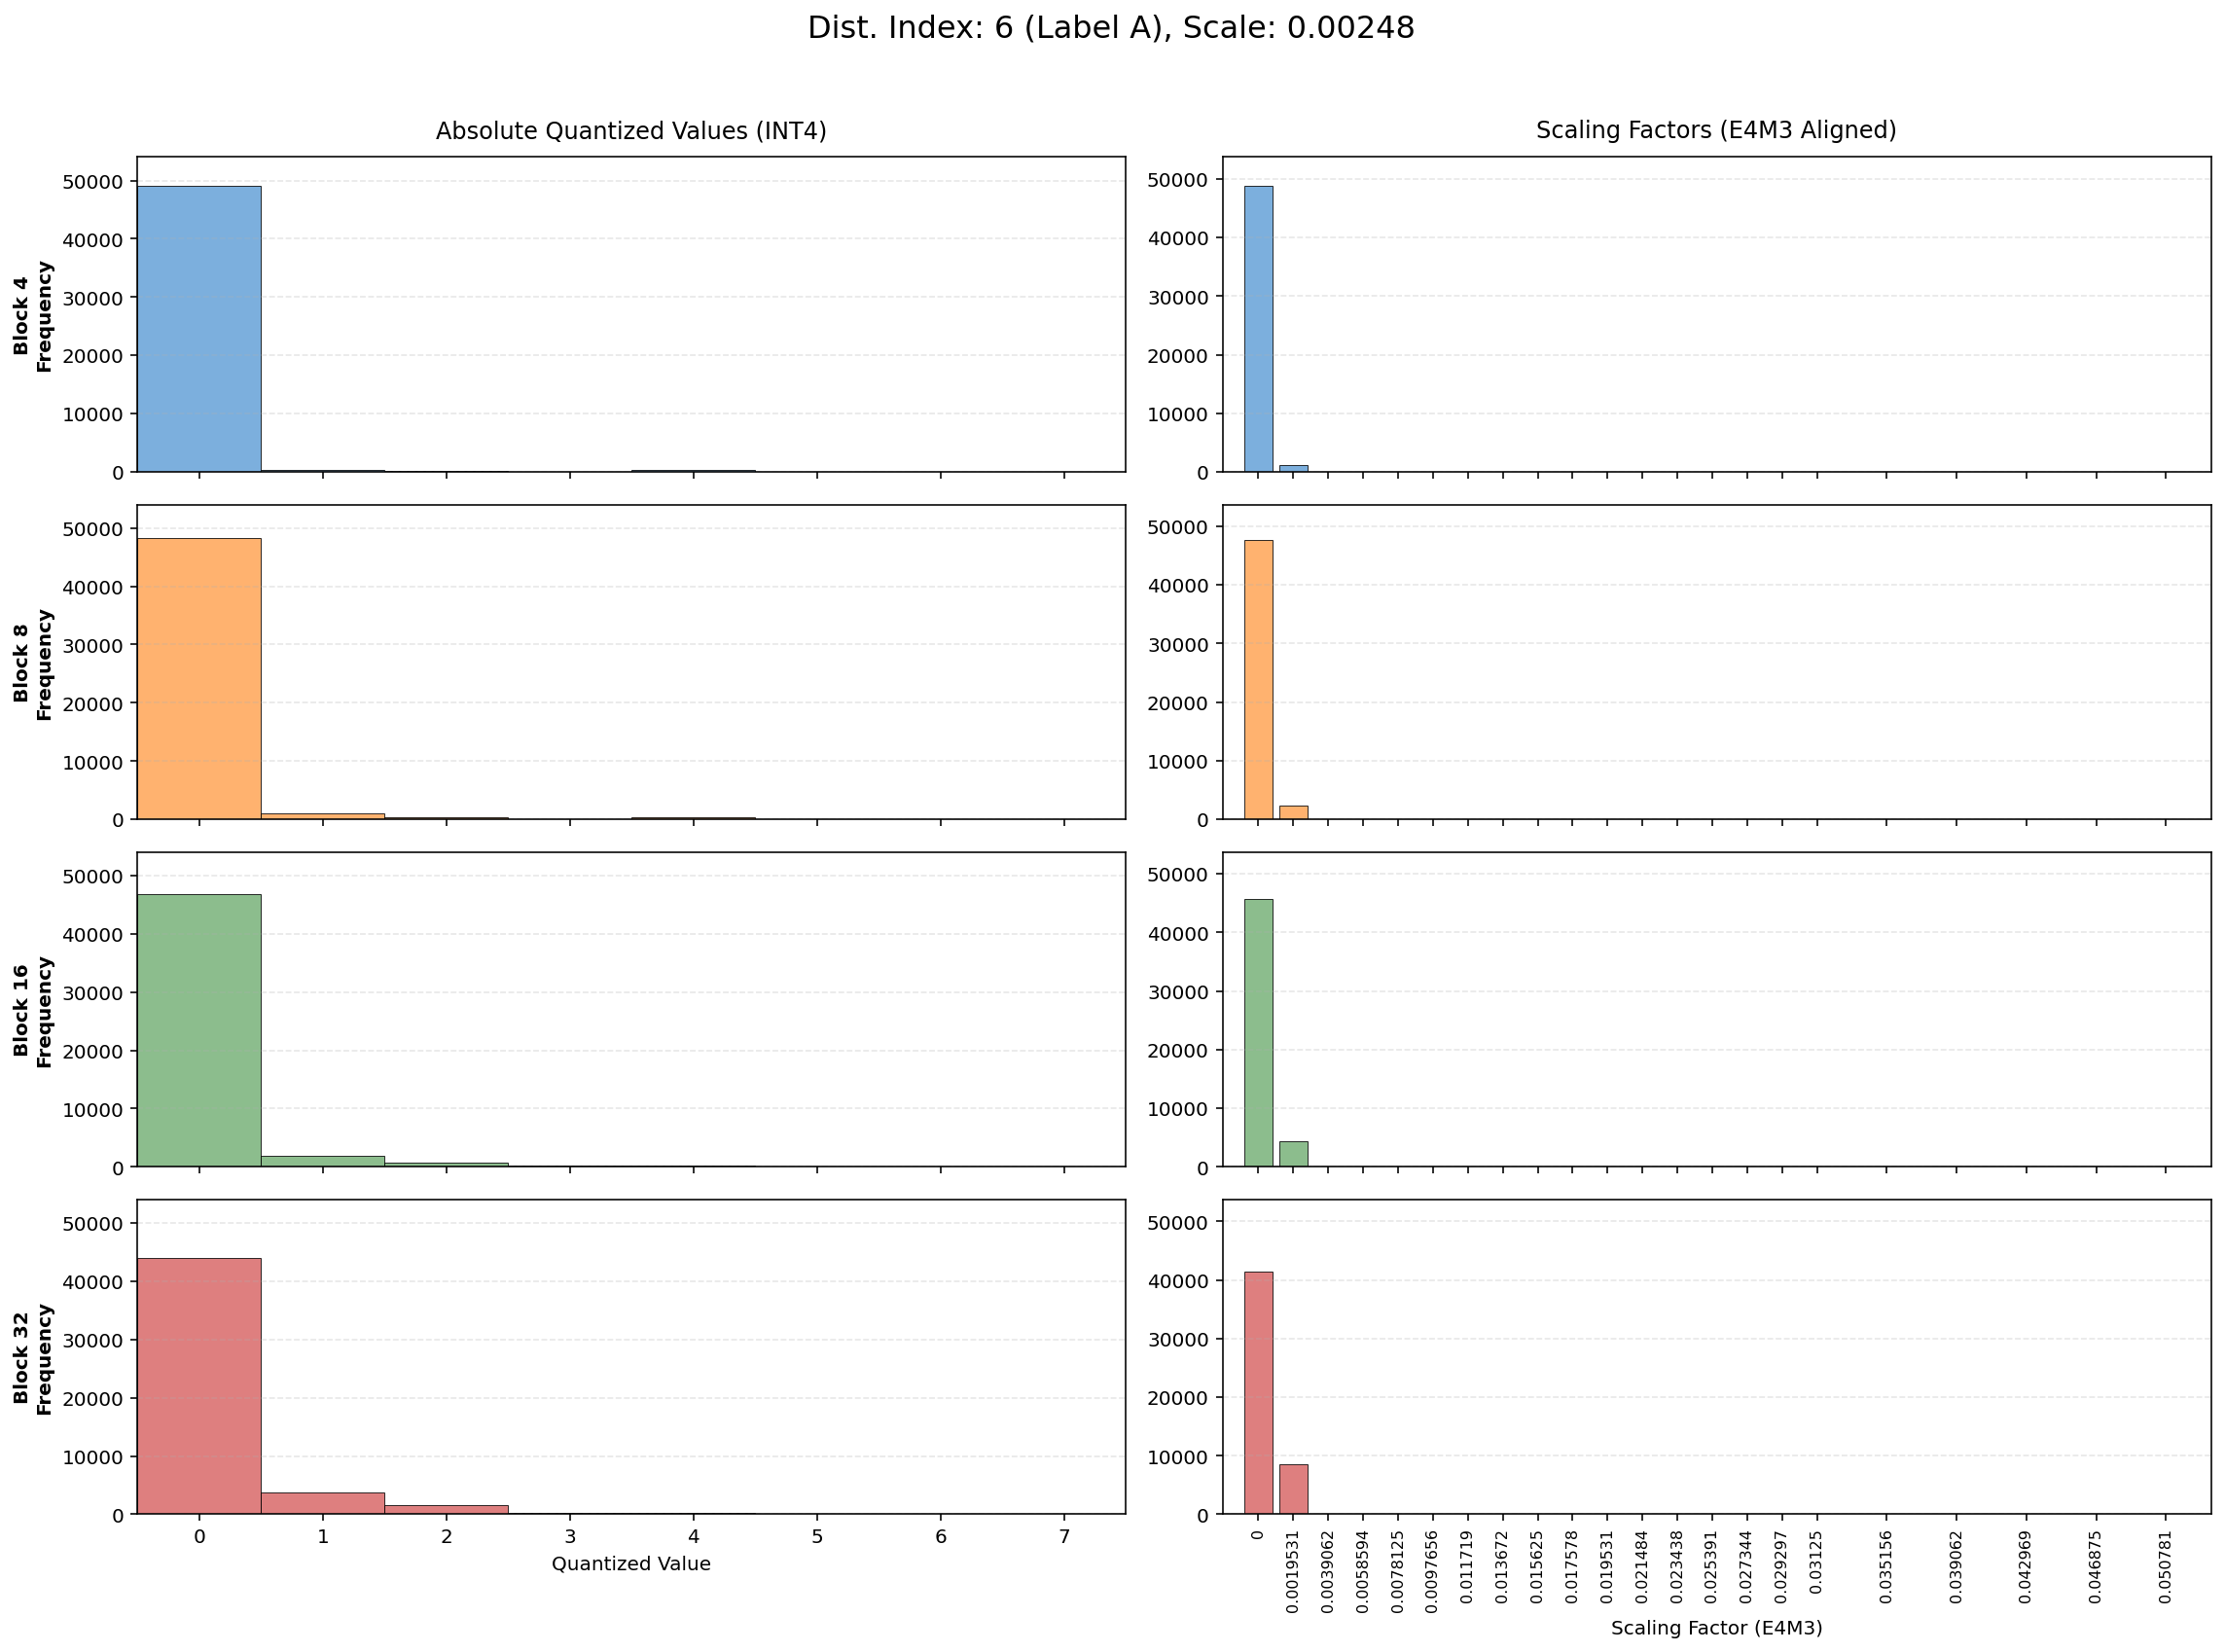

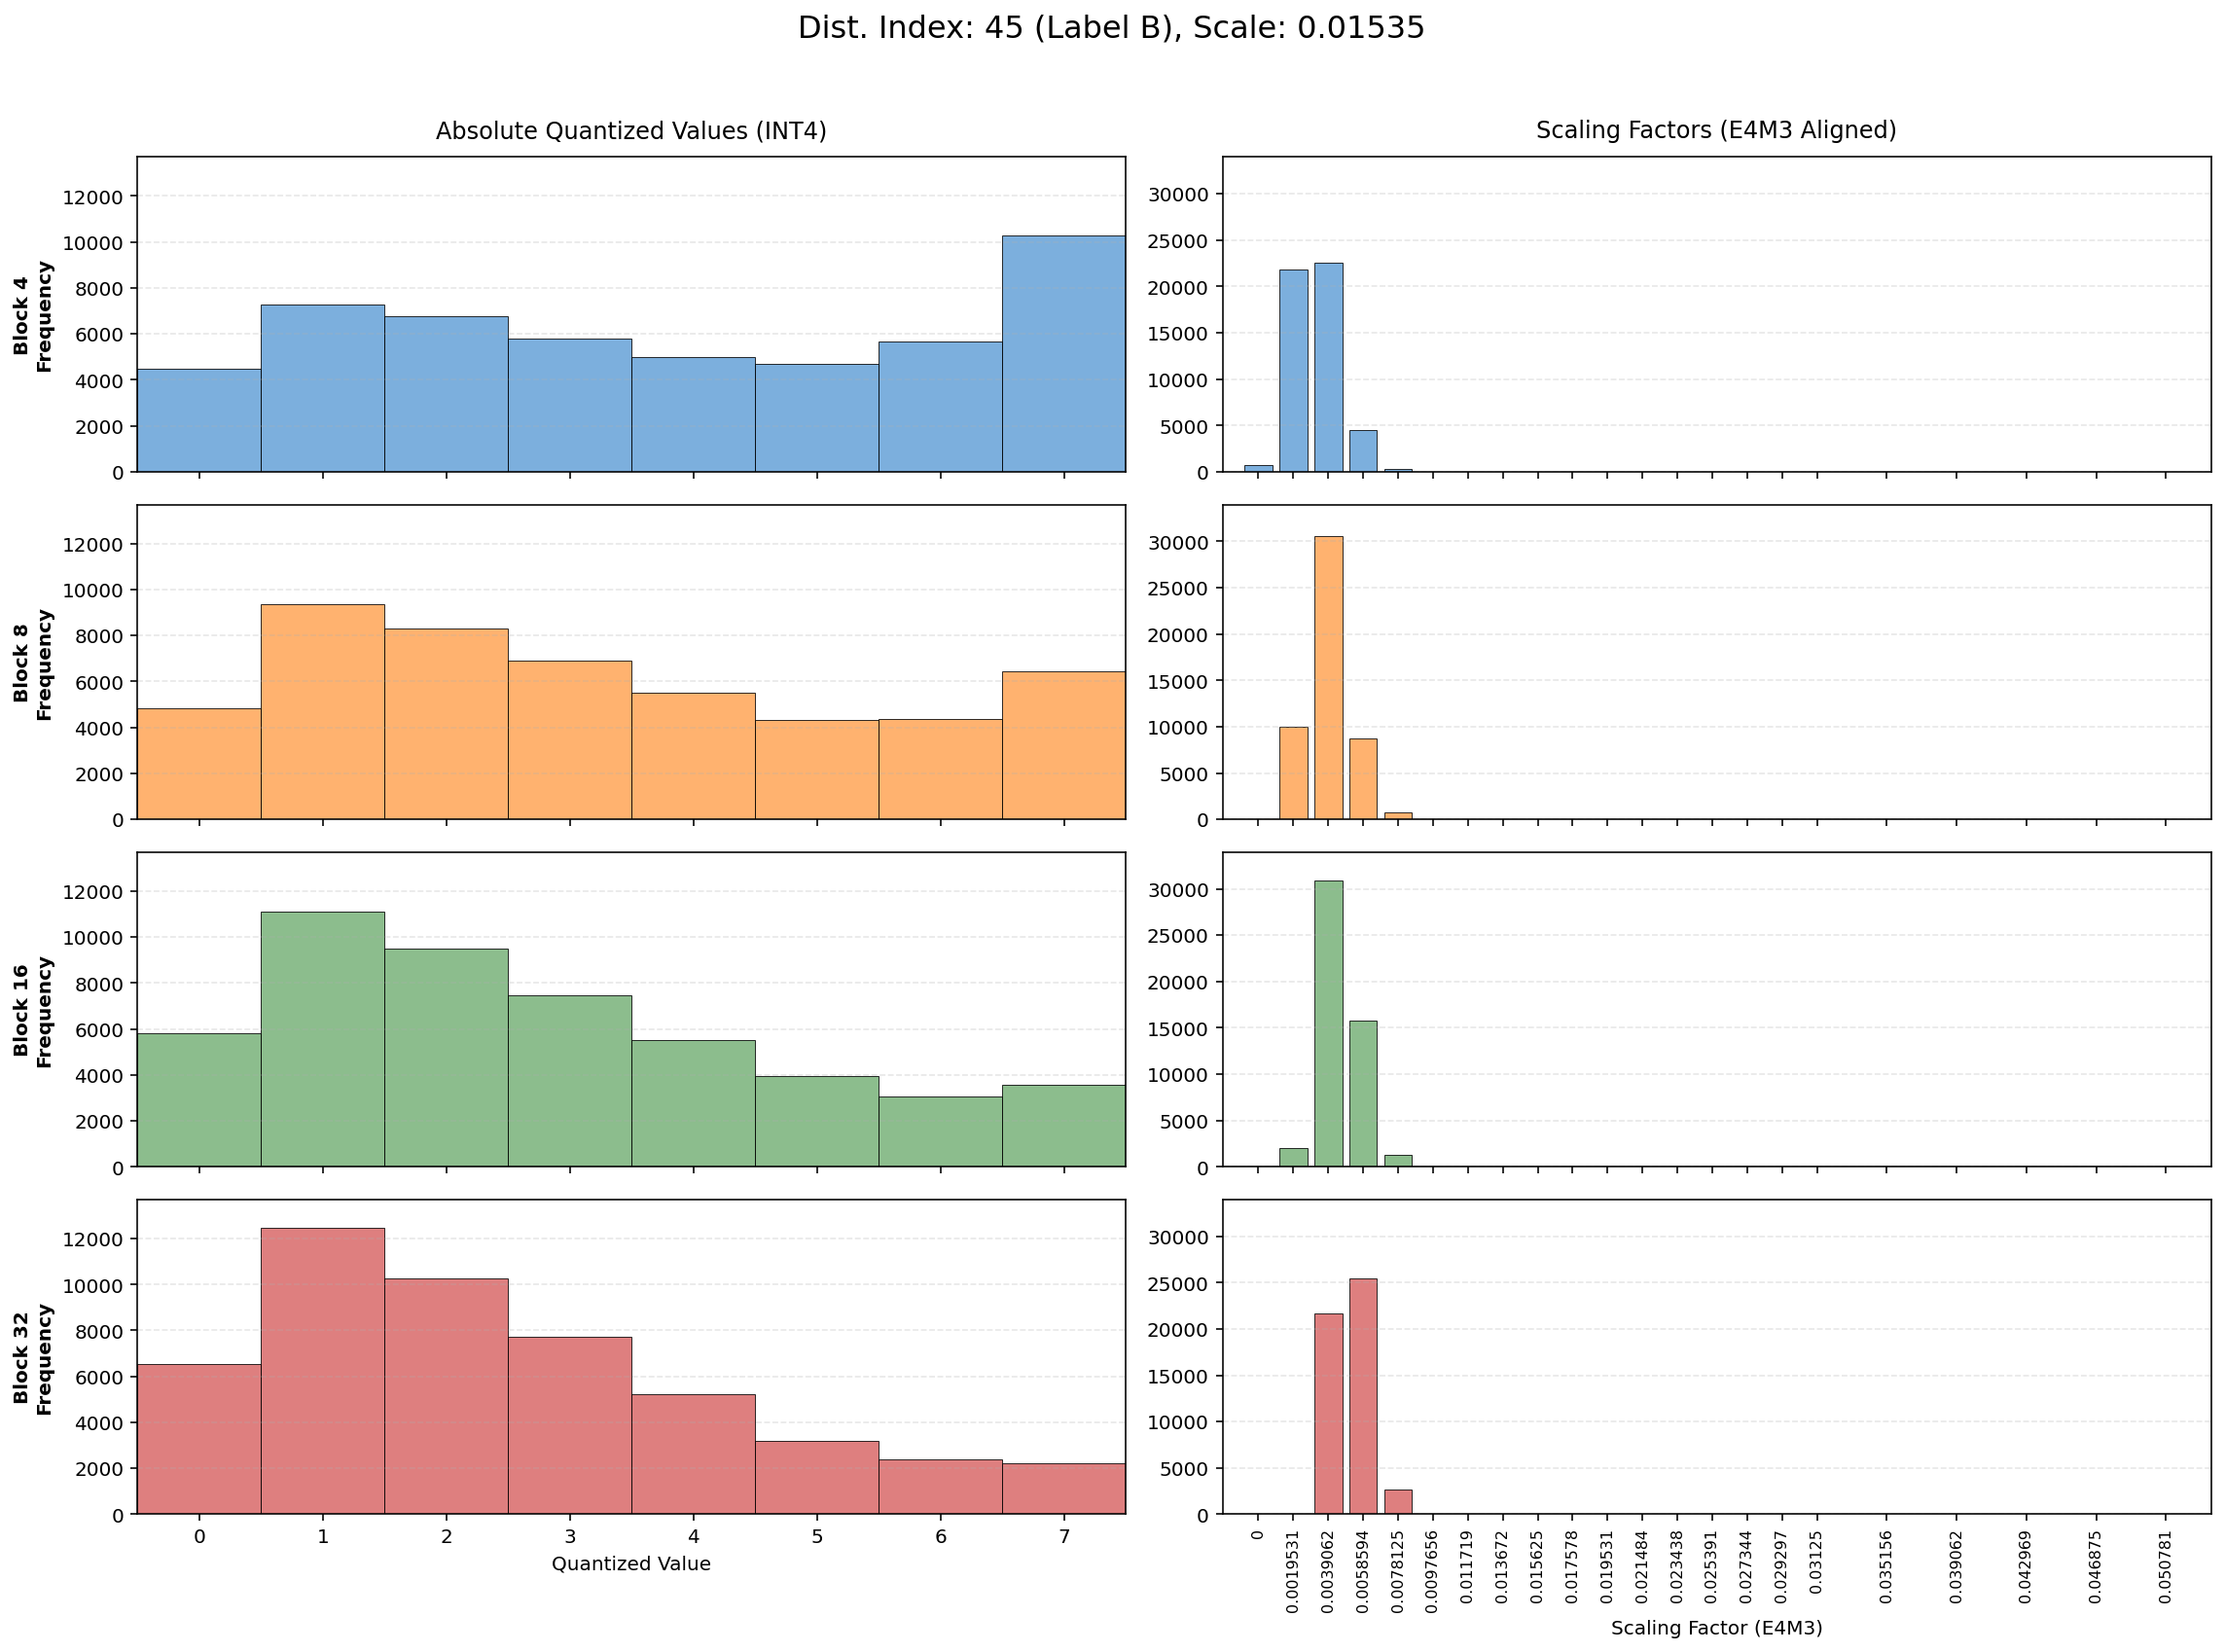

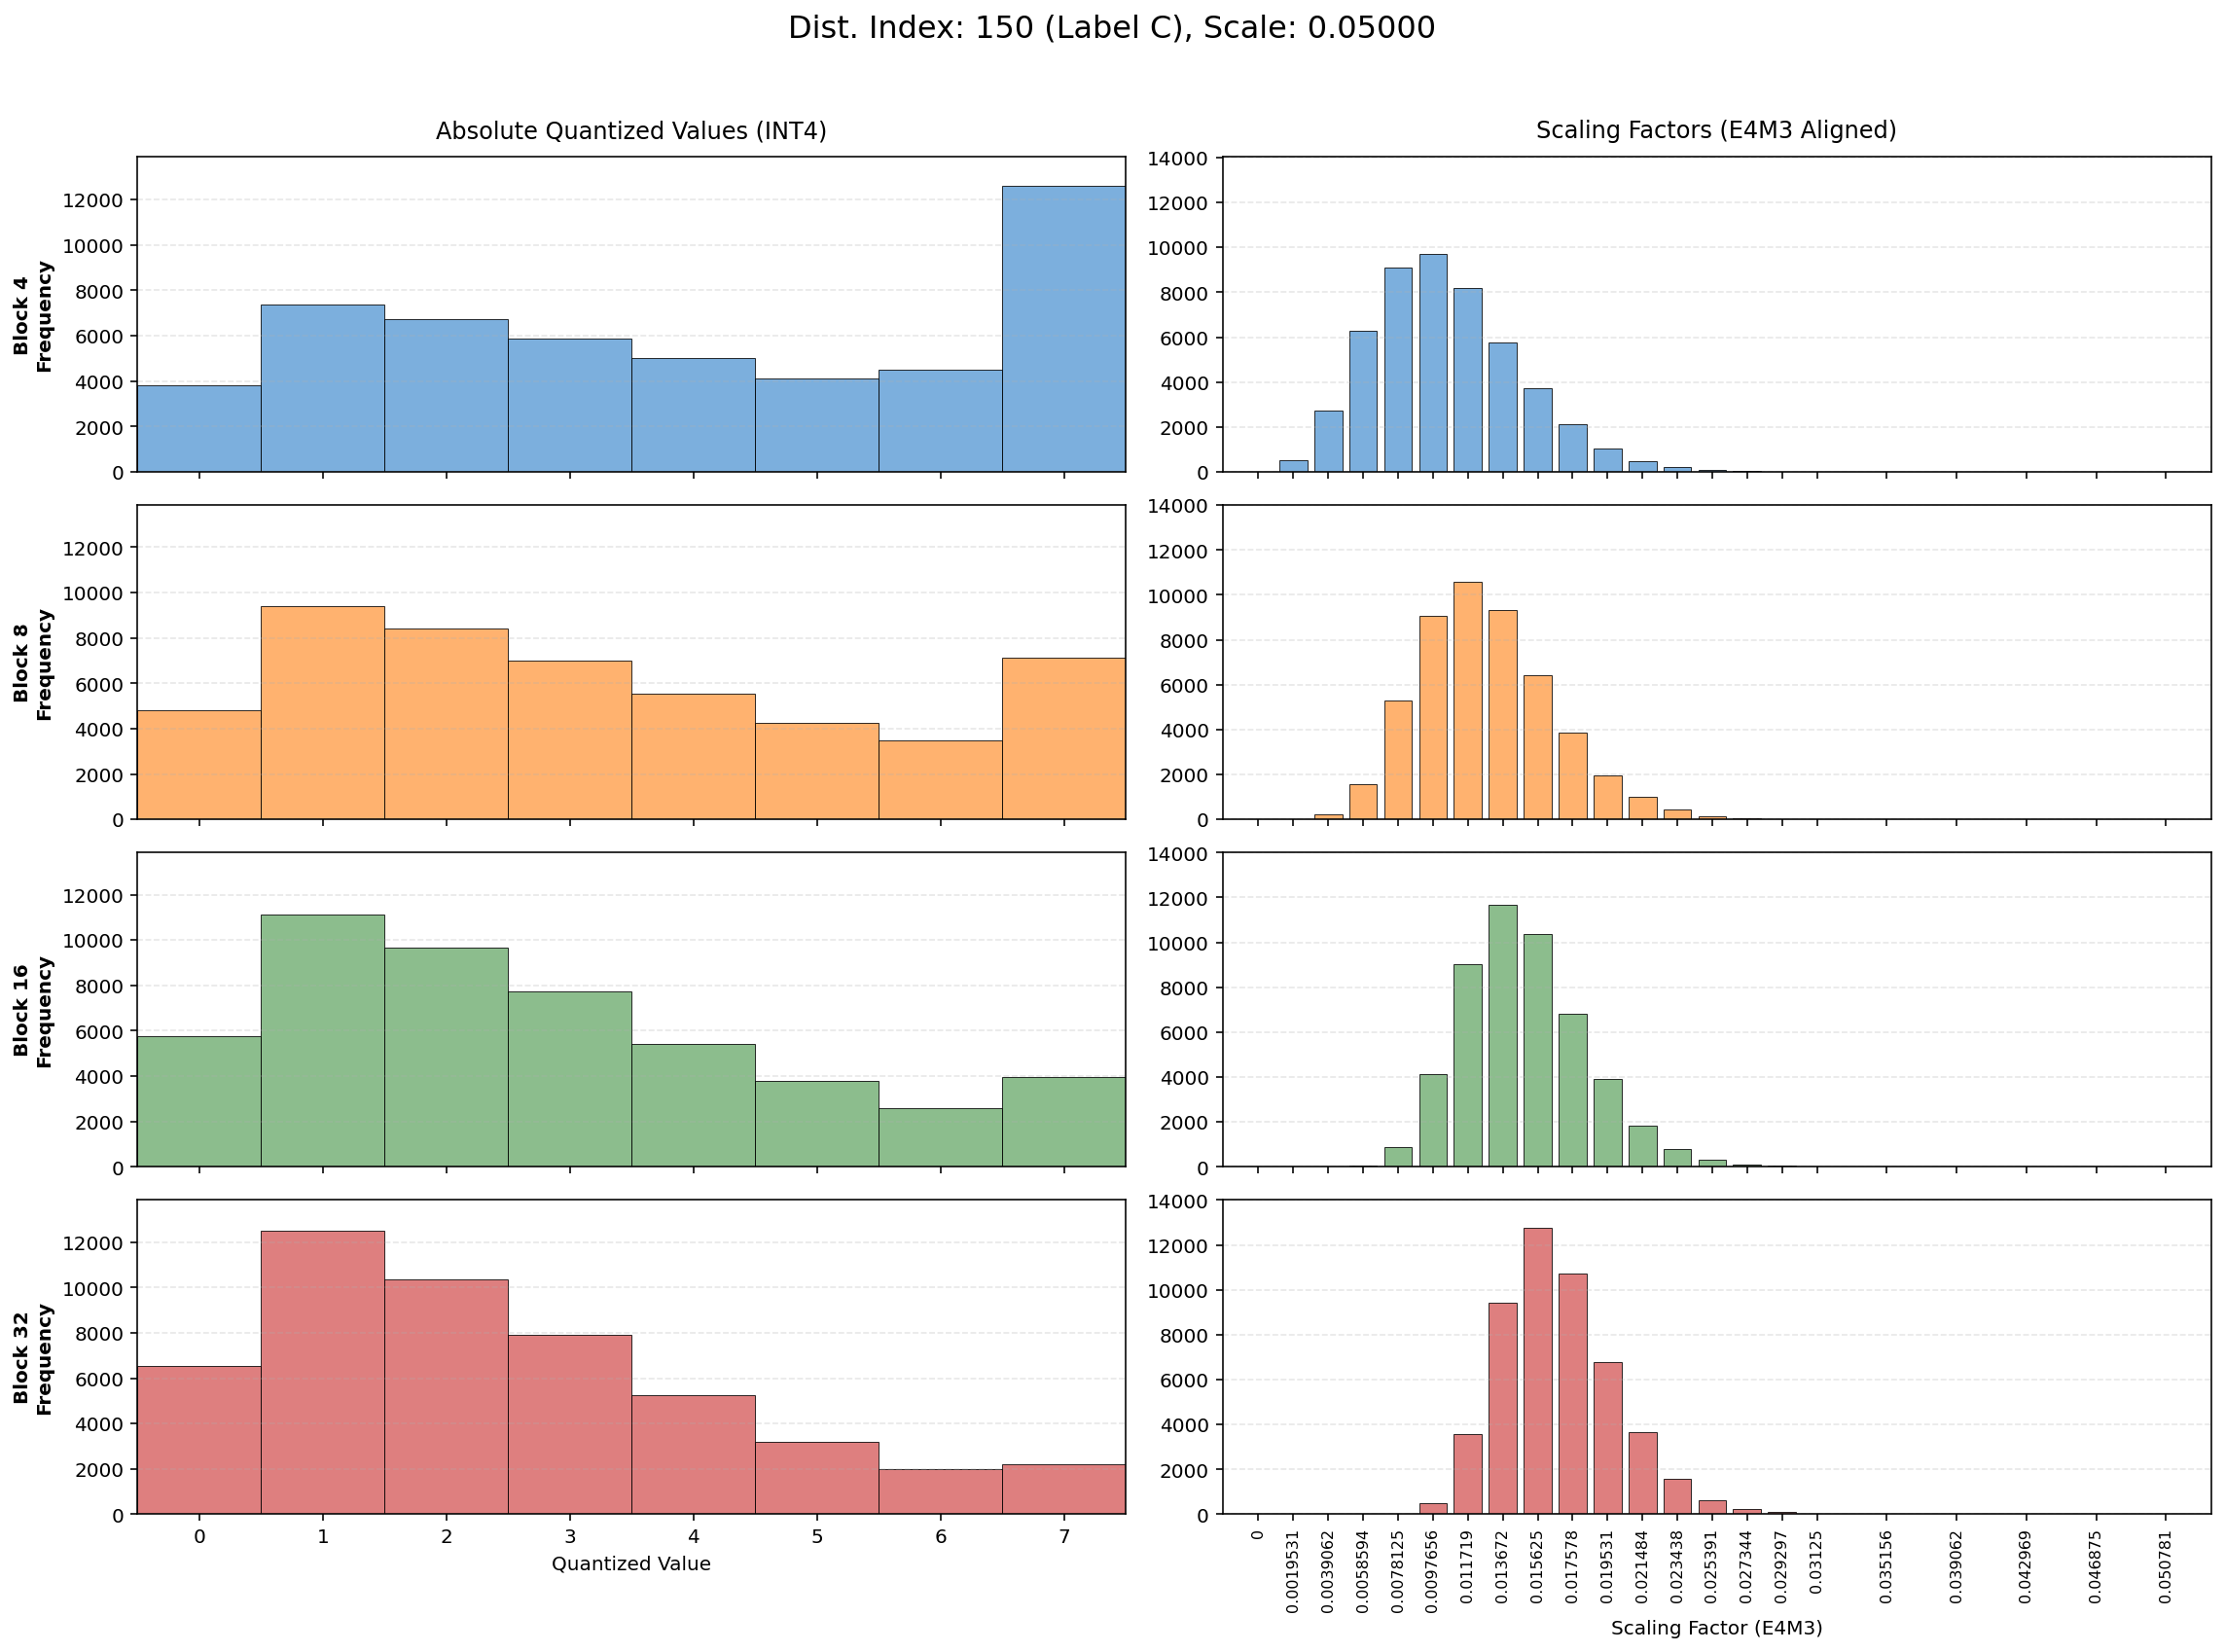

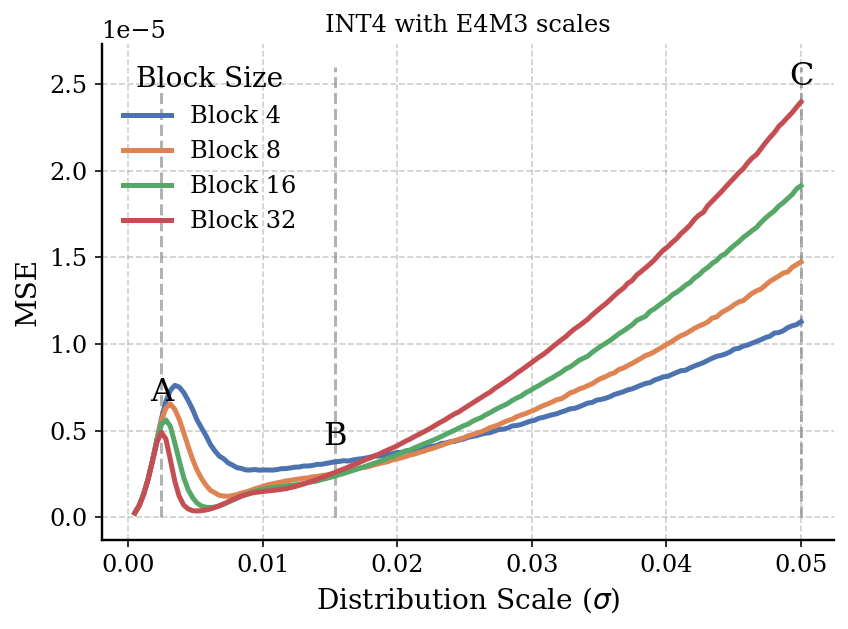

In [12]:
df_int4_absmax = run_error_experiment(int4_quant, quant_type='int4', title="INT4 with E4M3 scales")

## E4M3 nonzero abs max

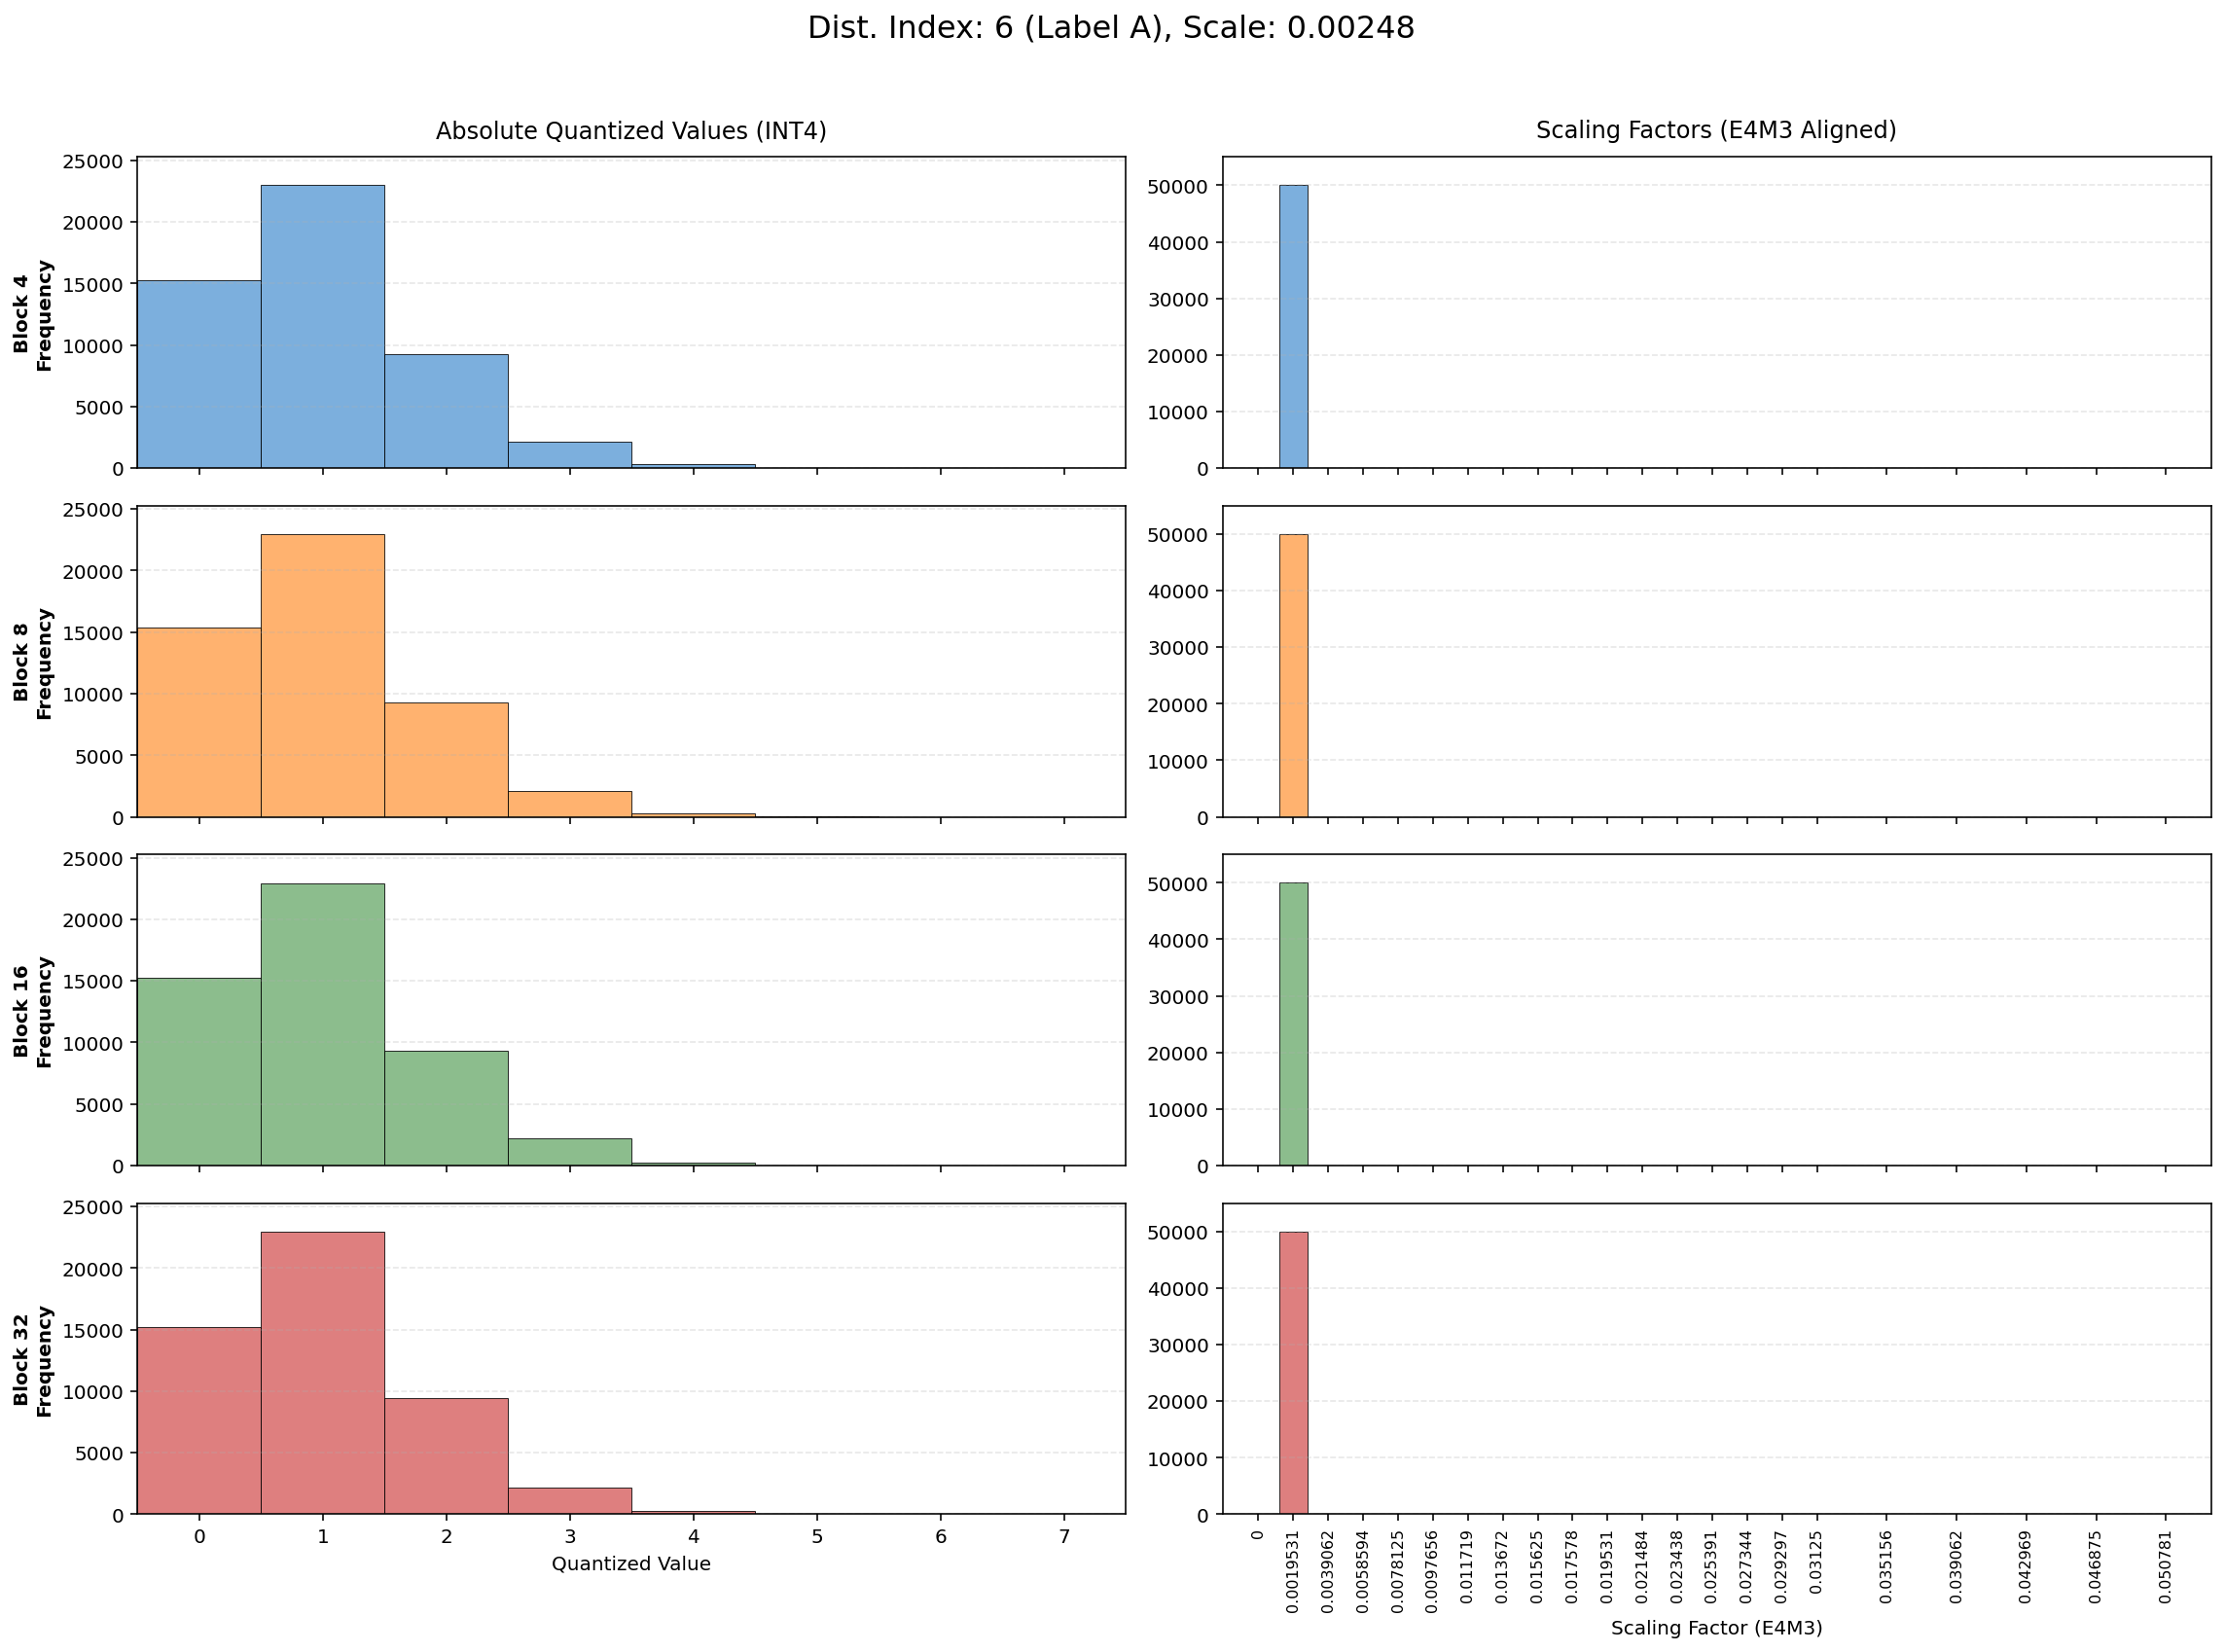

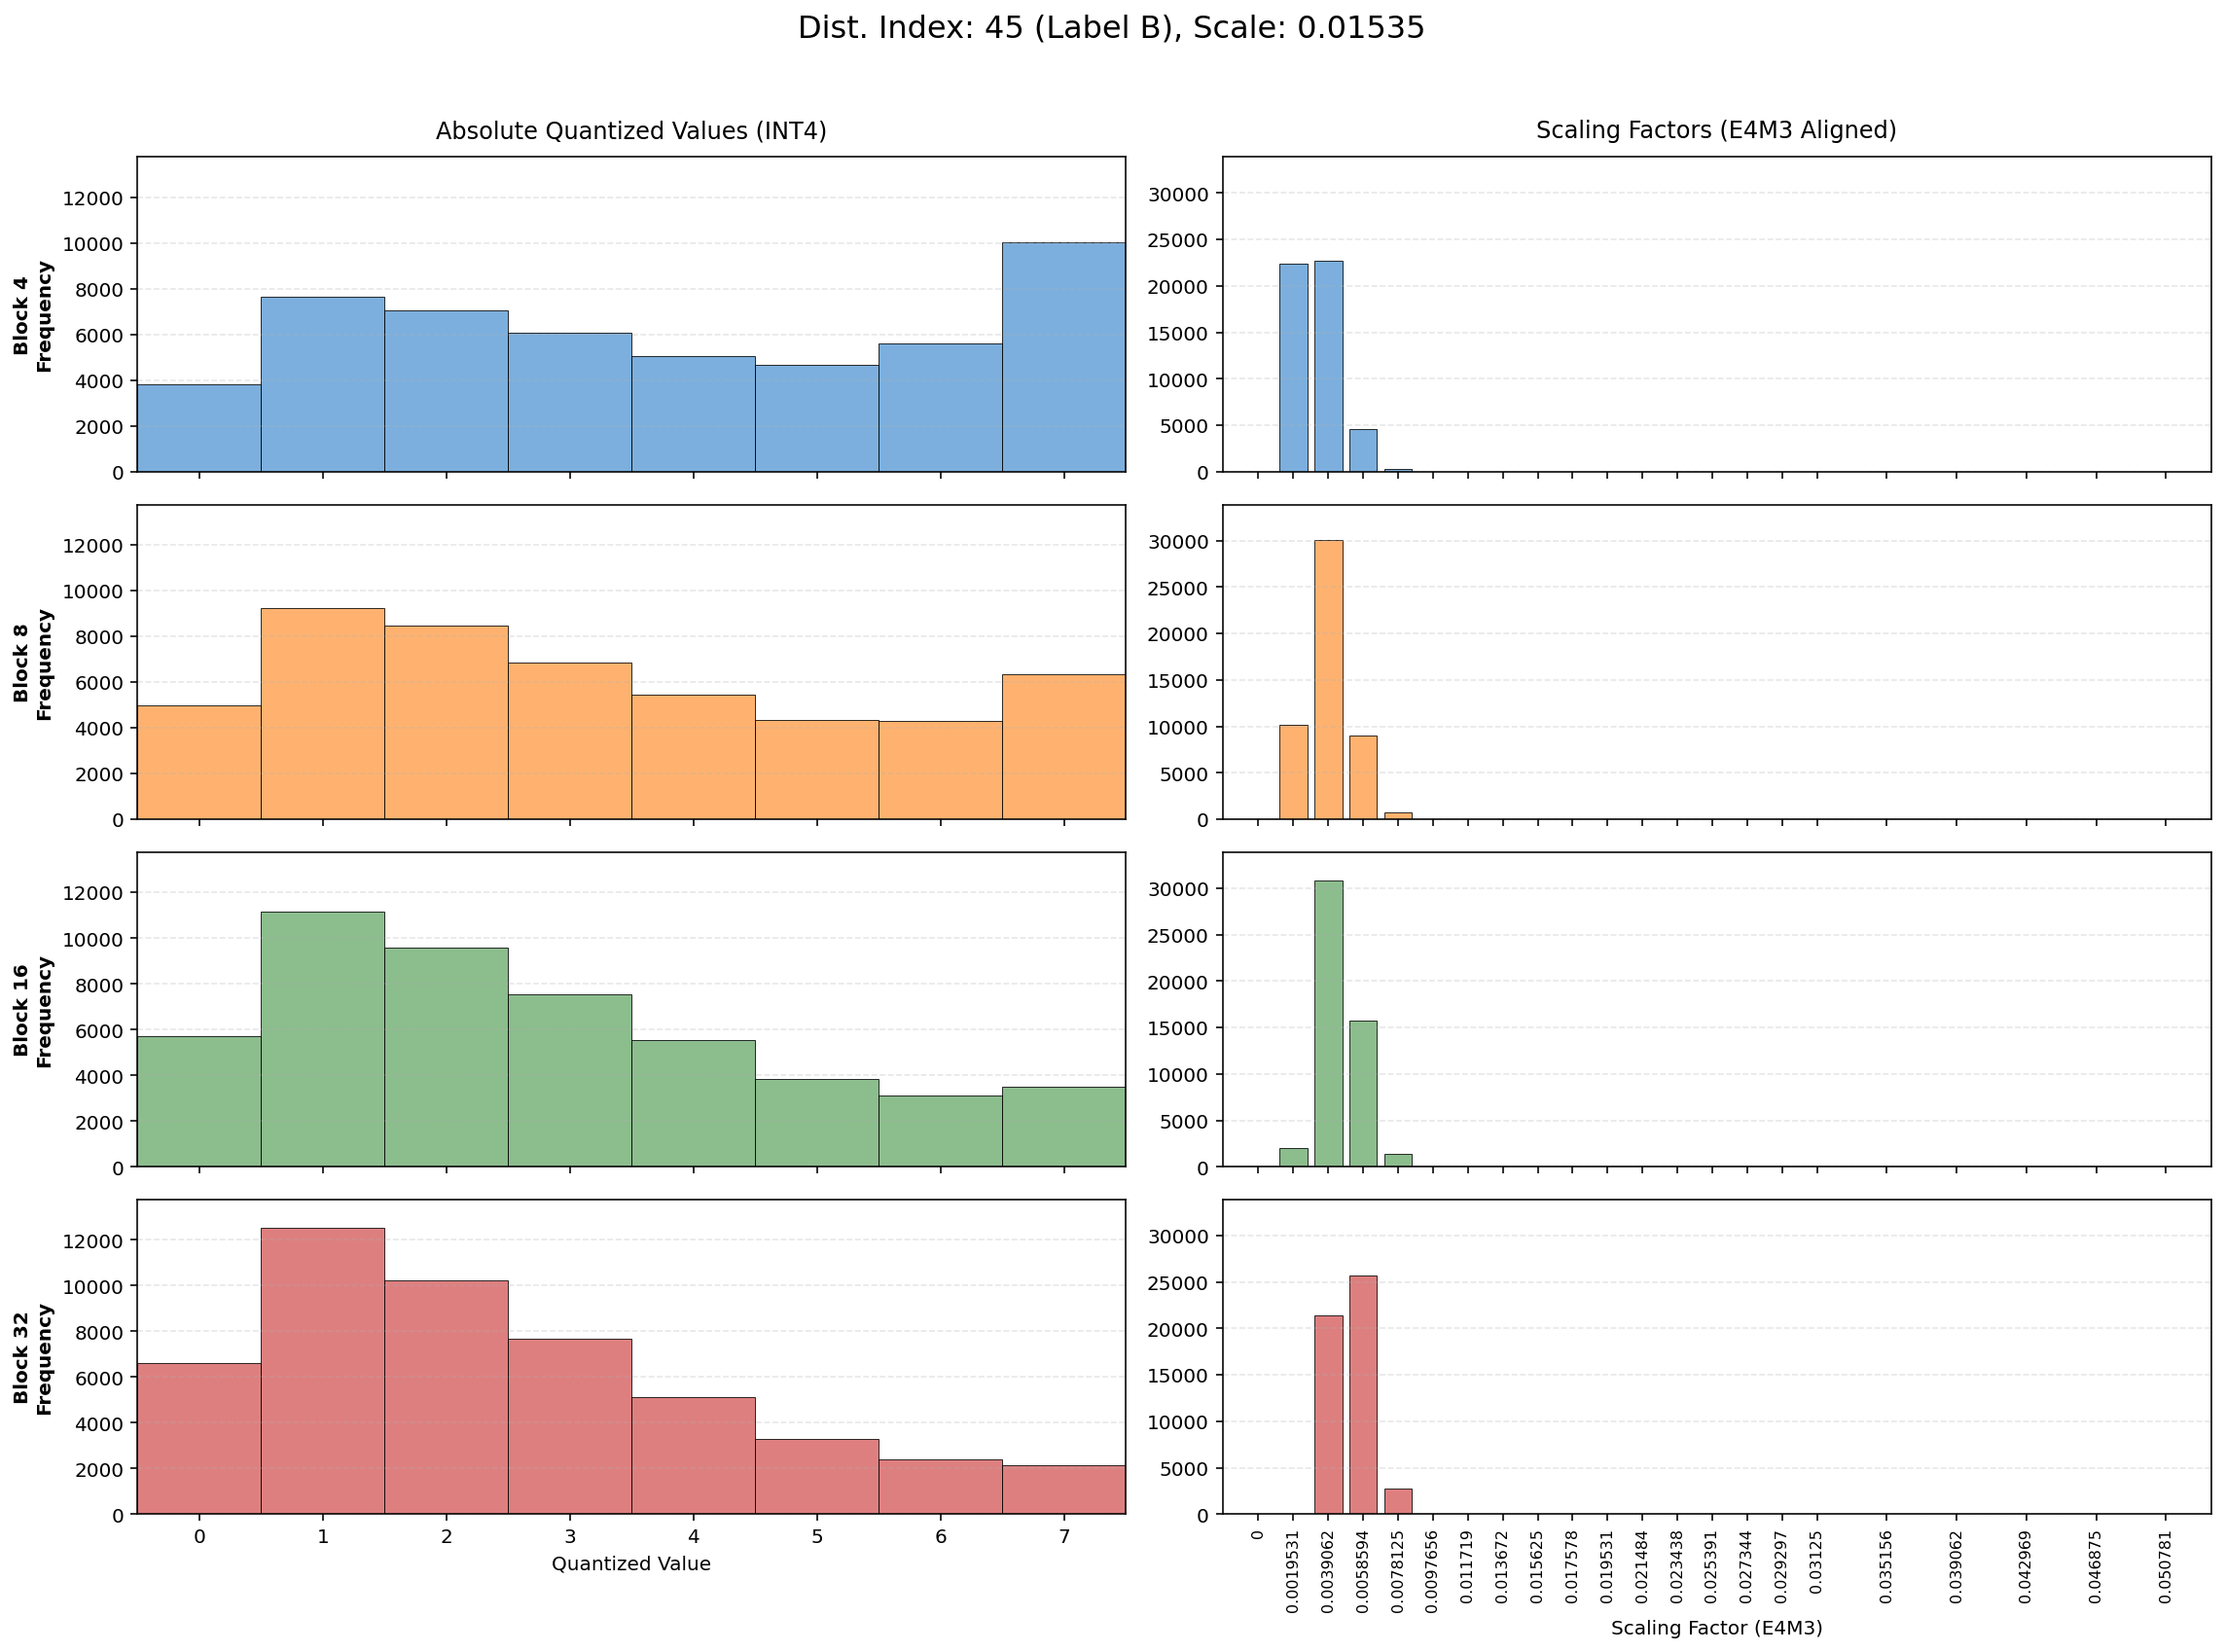

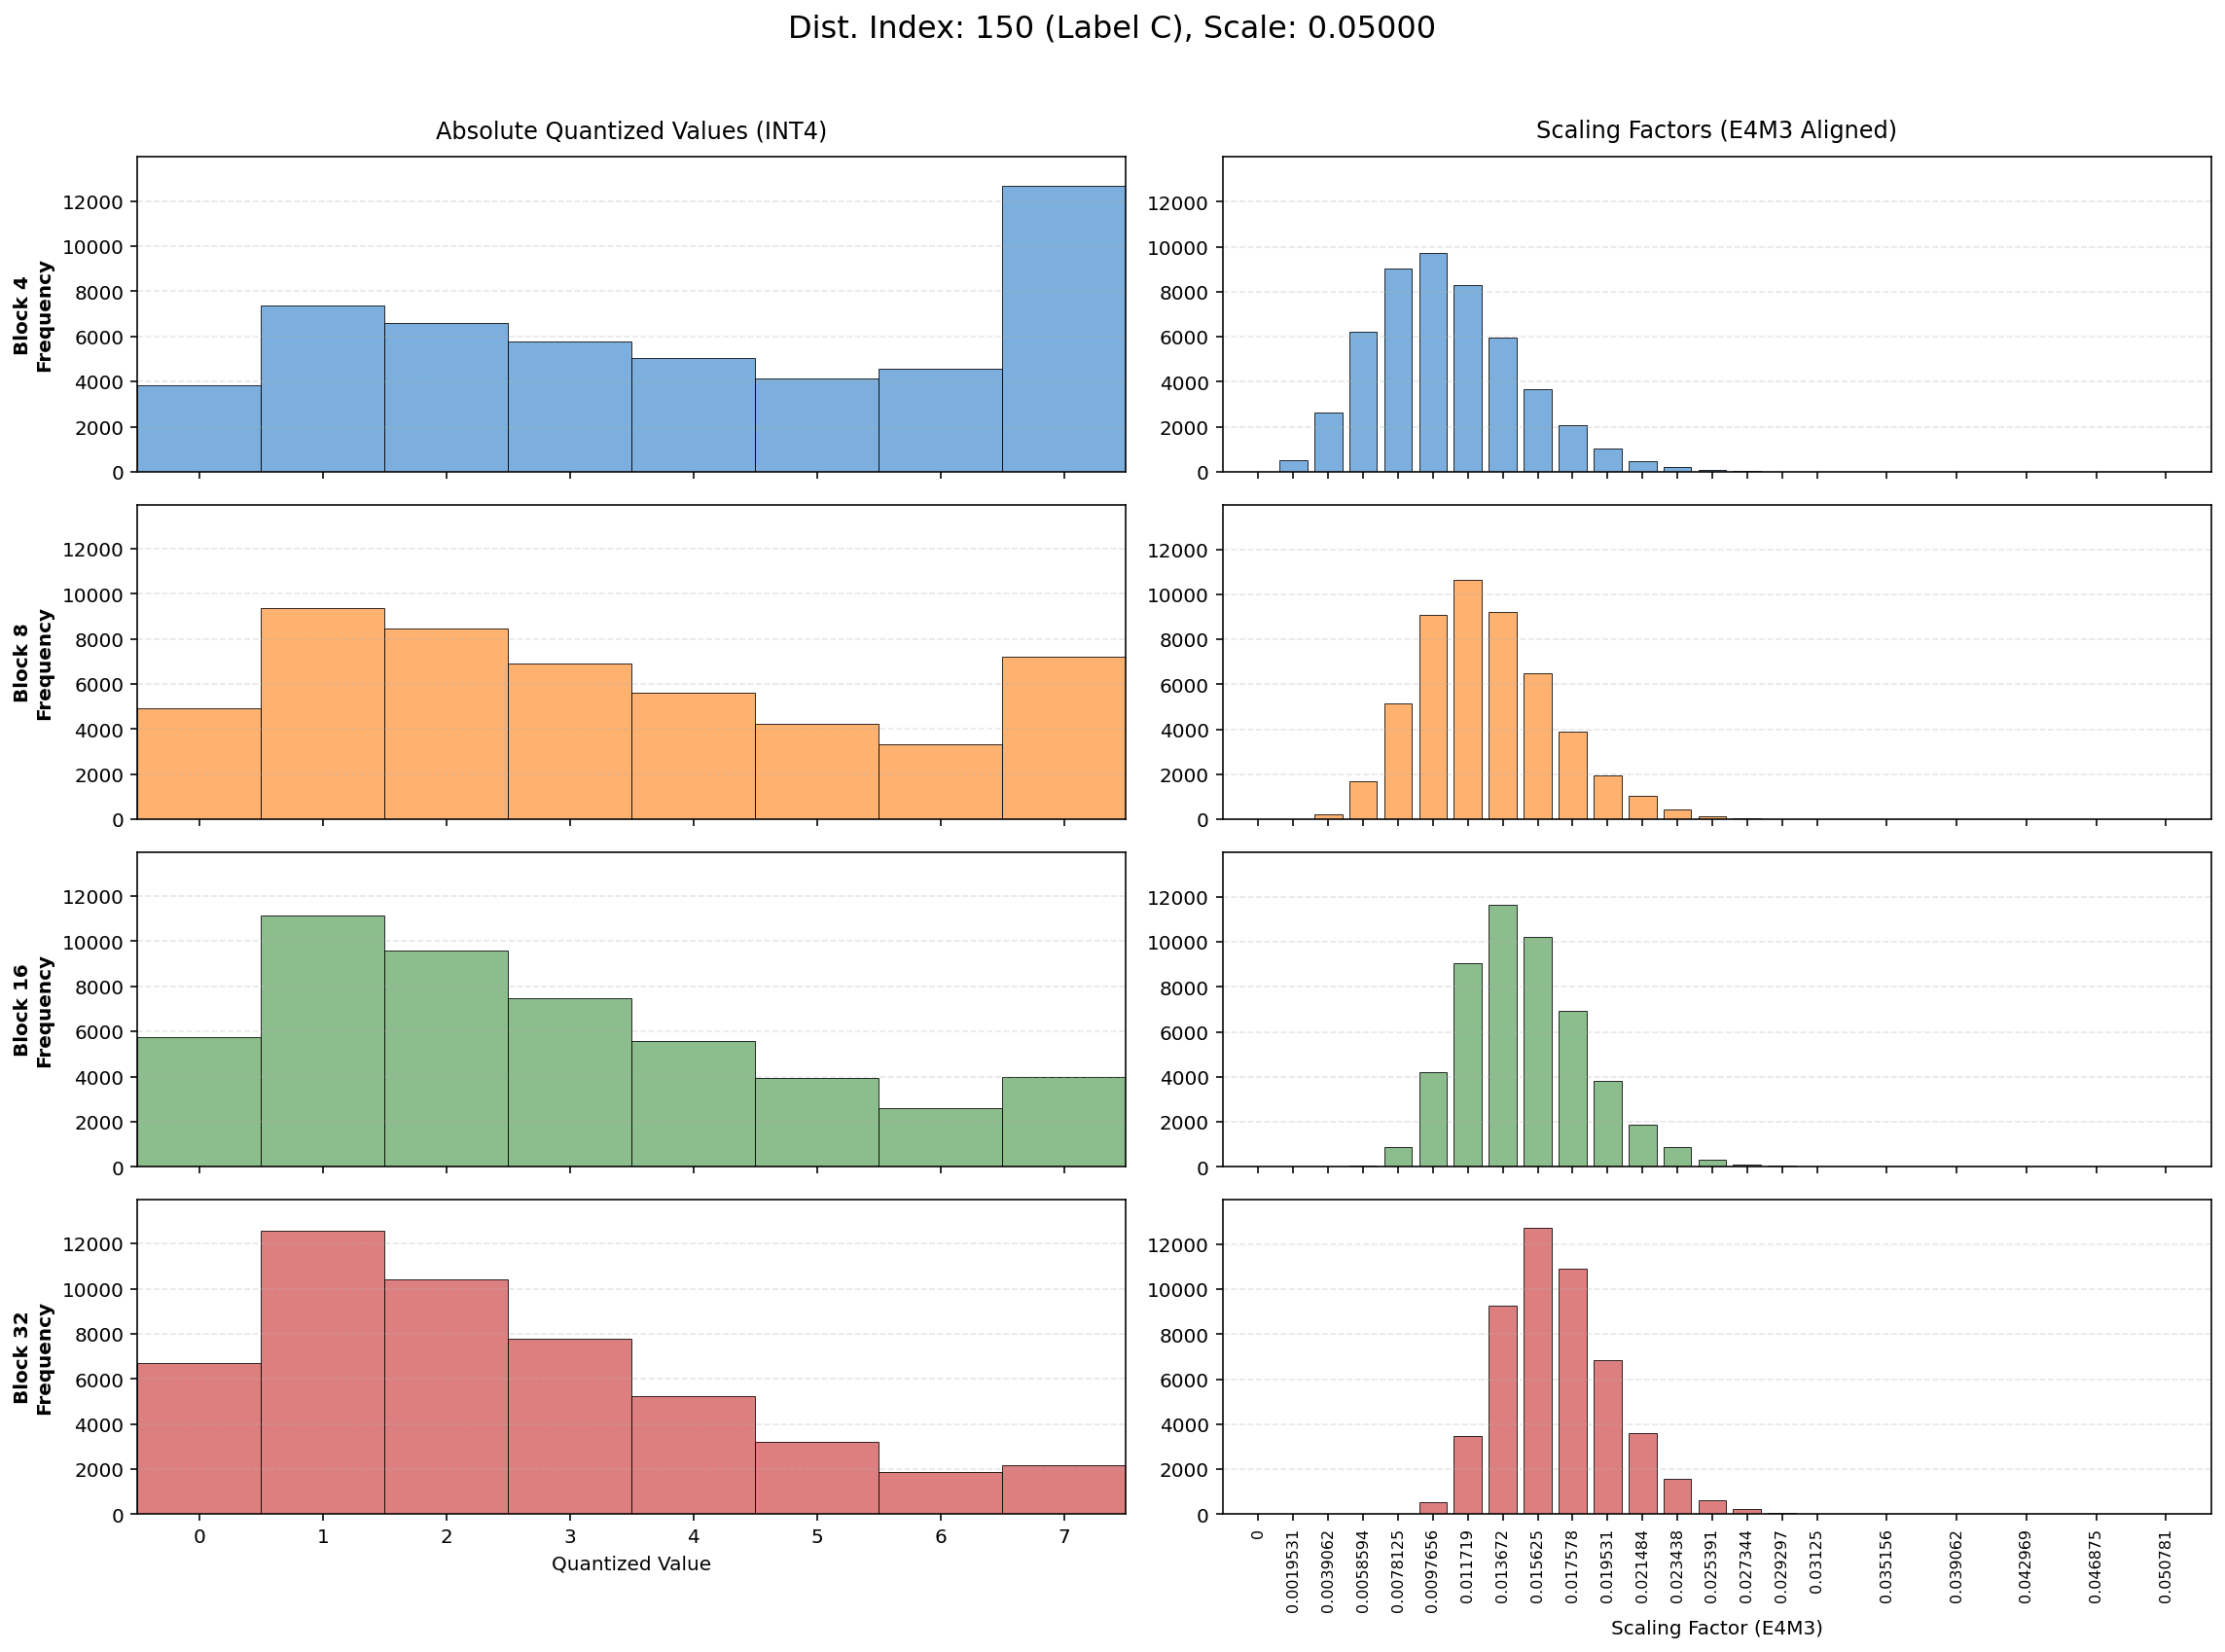

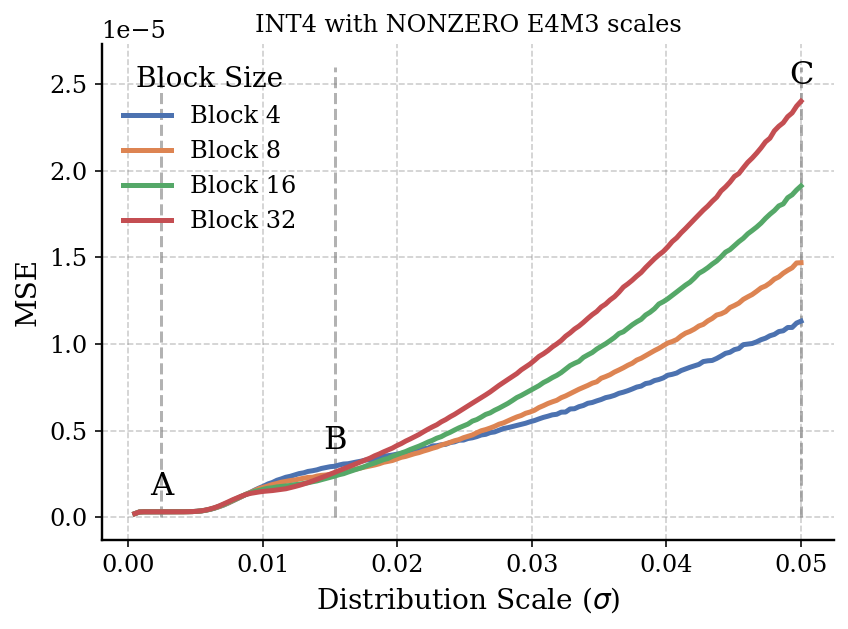

In [13]:
df_int4_nonzero_absmax = run_error_experiment(nonzero_int4_quant, quant_type='int4', title="INT4 with NONZERO E4M3 scales")

## E4M3 search

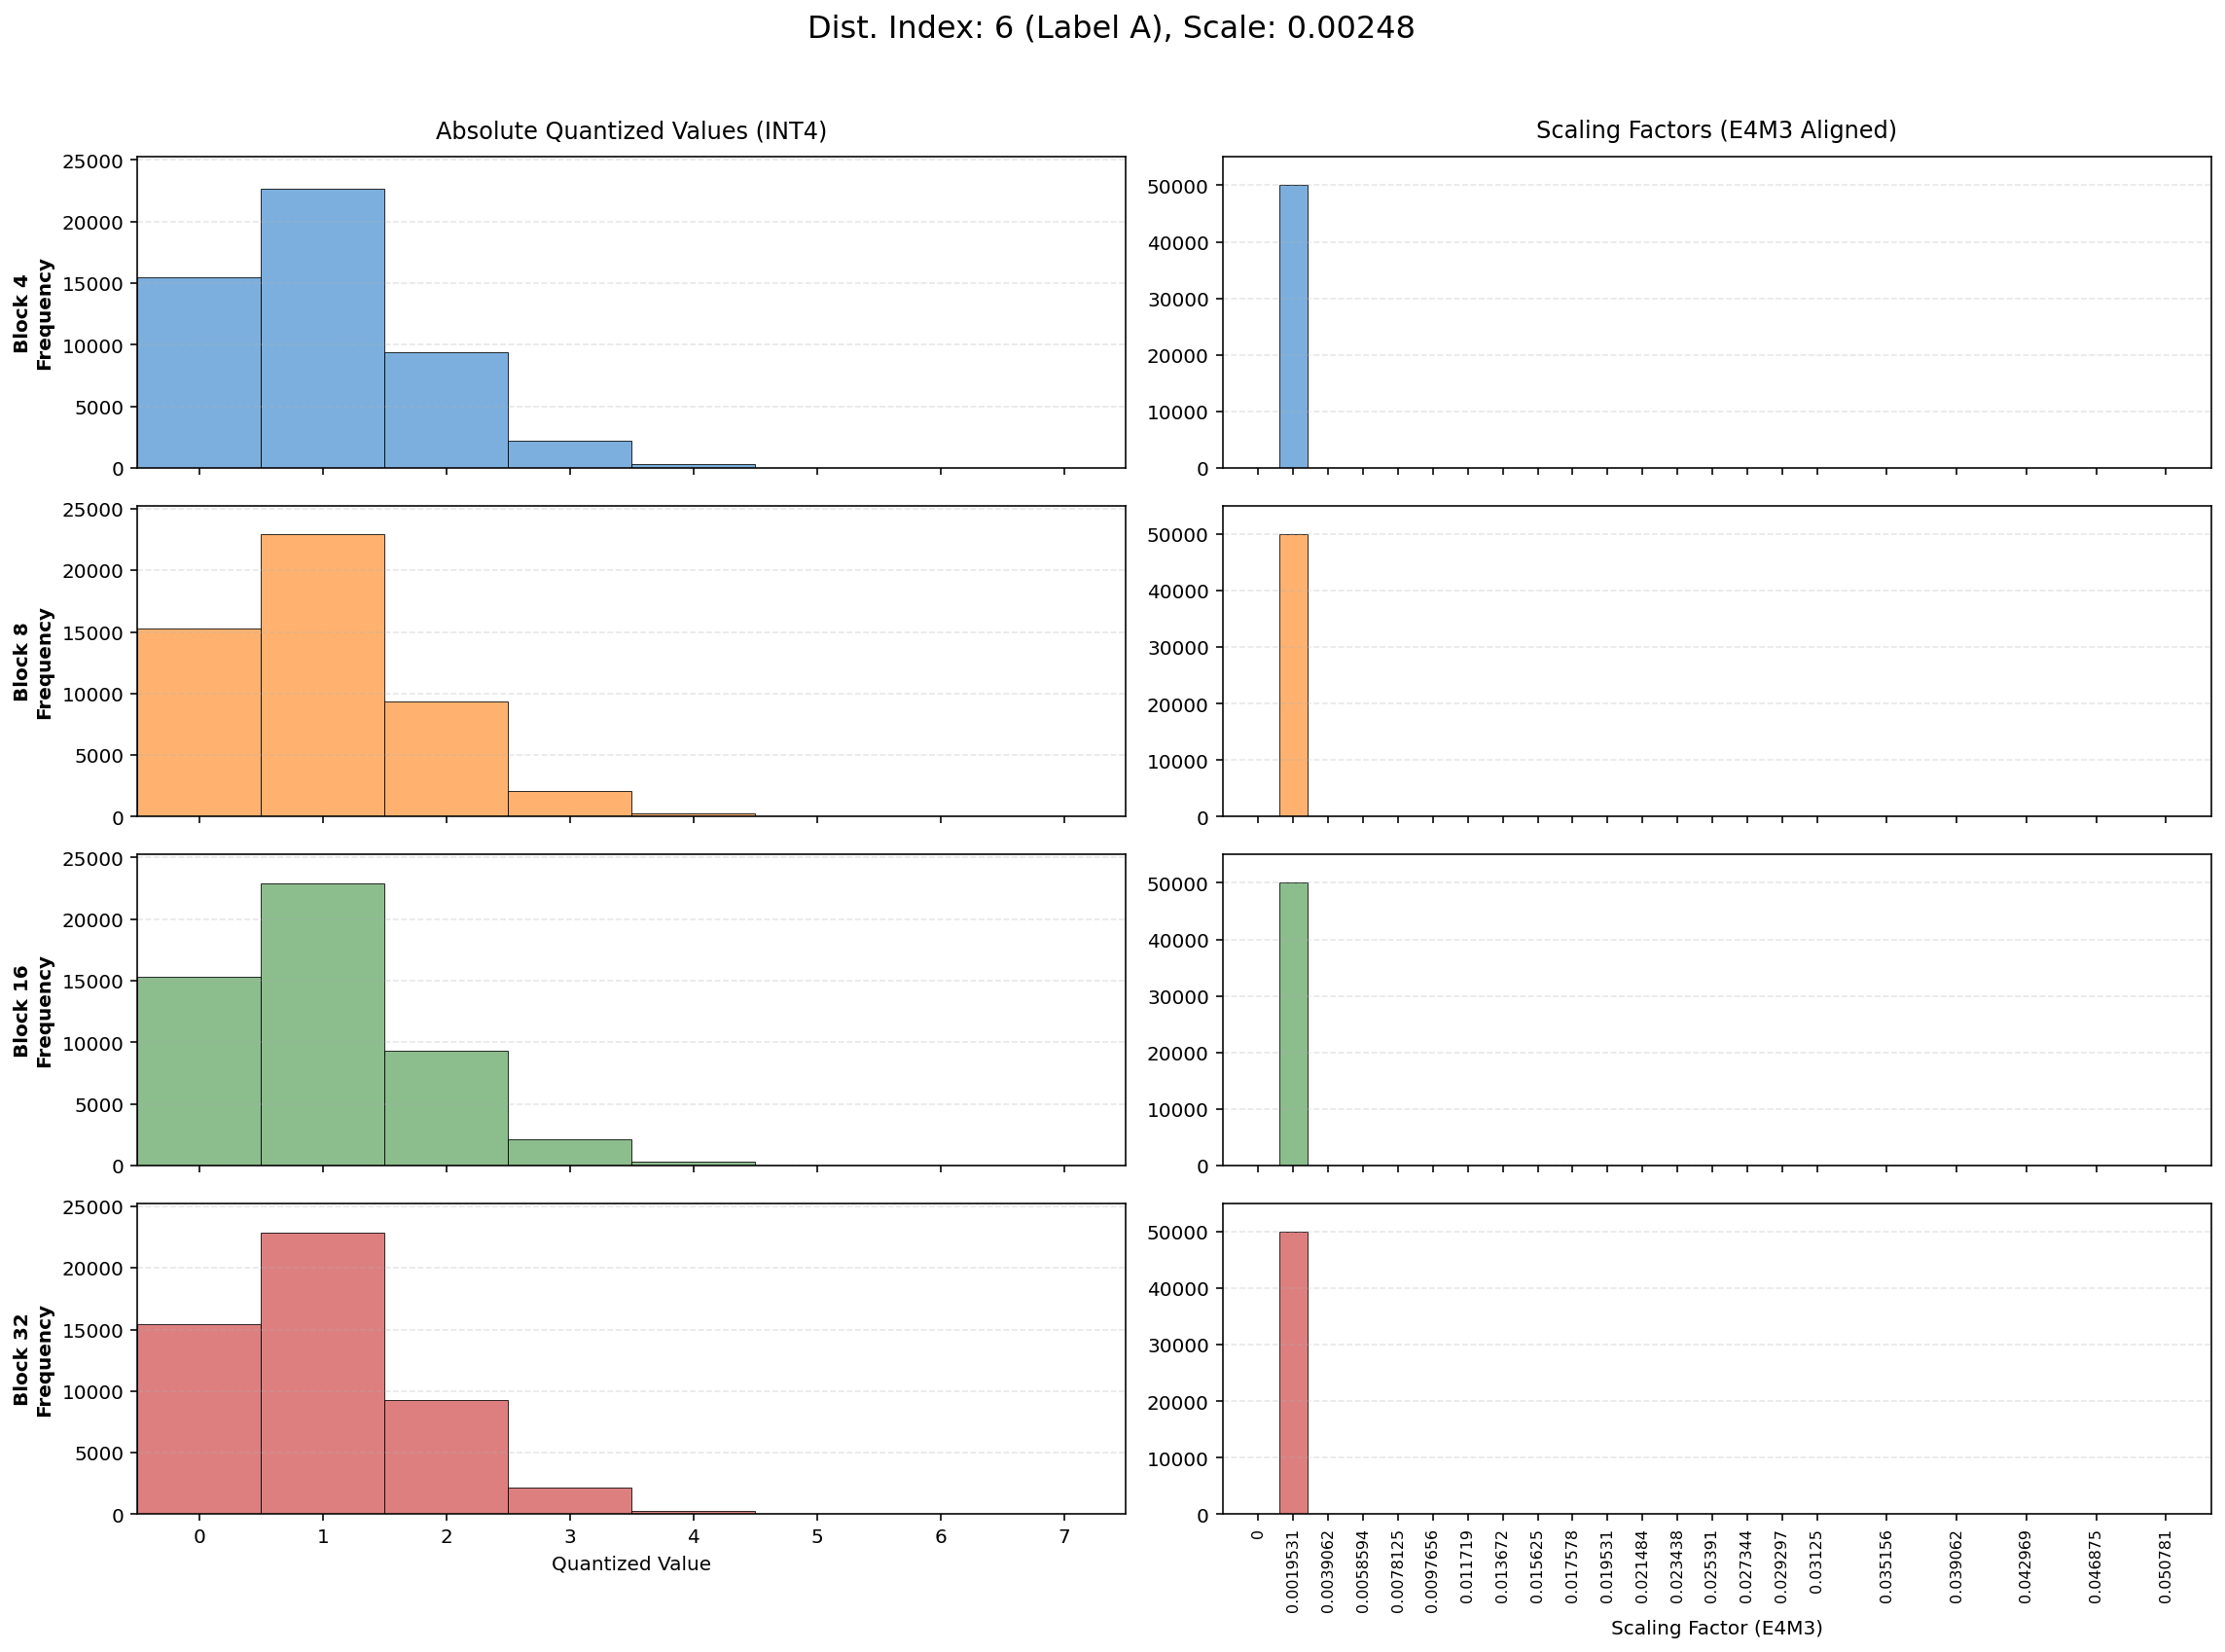

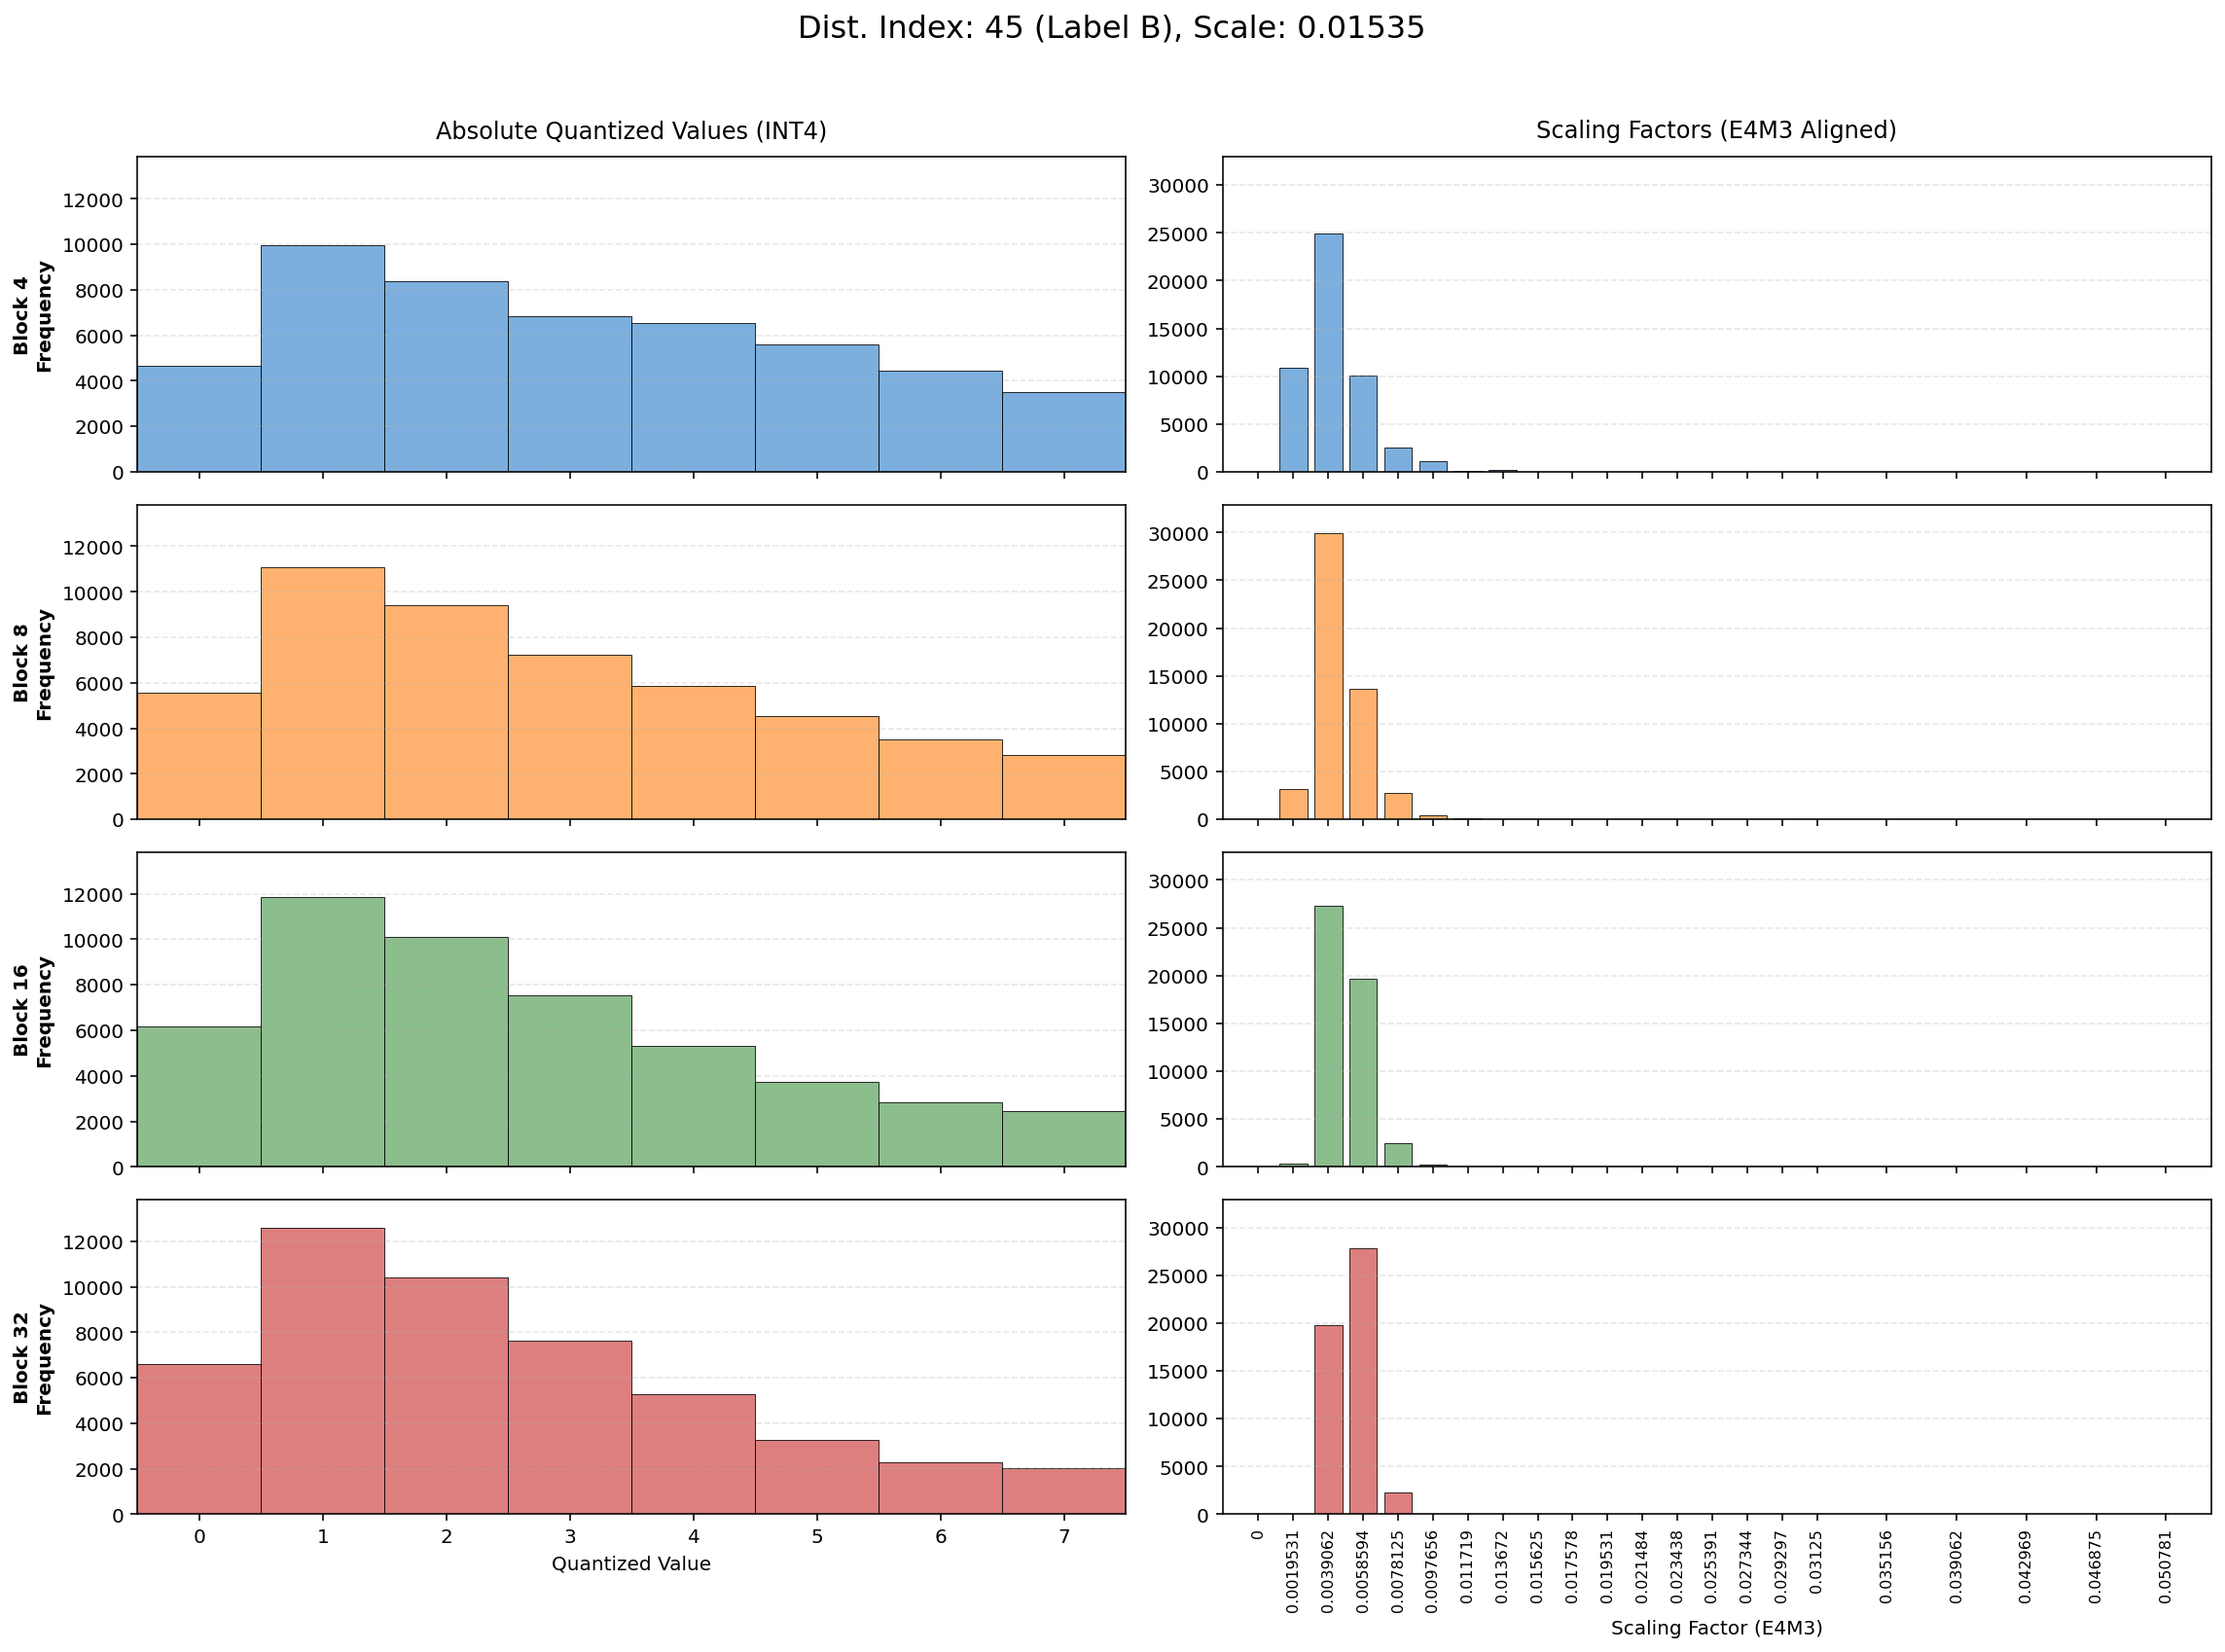

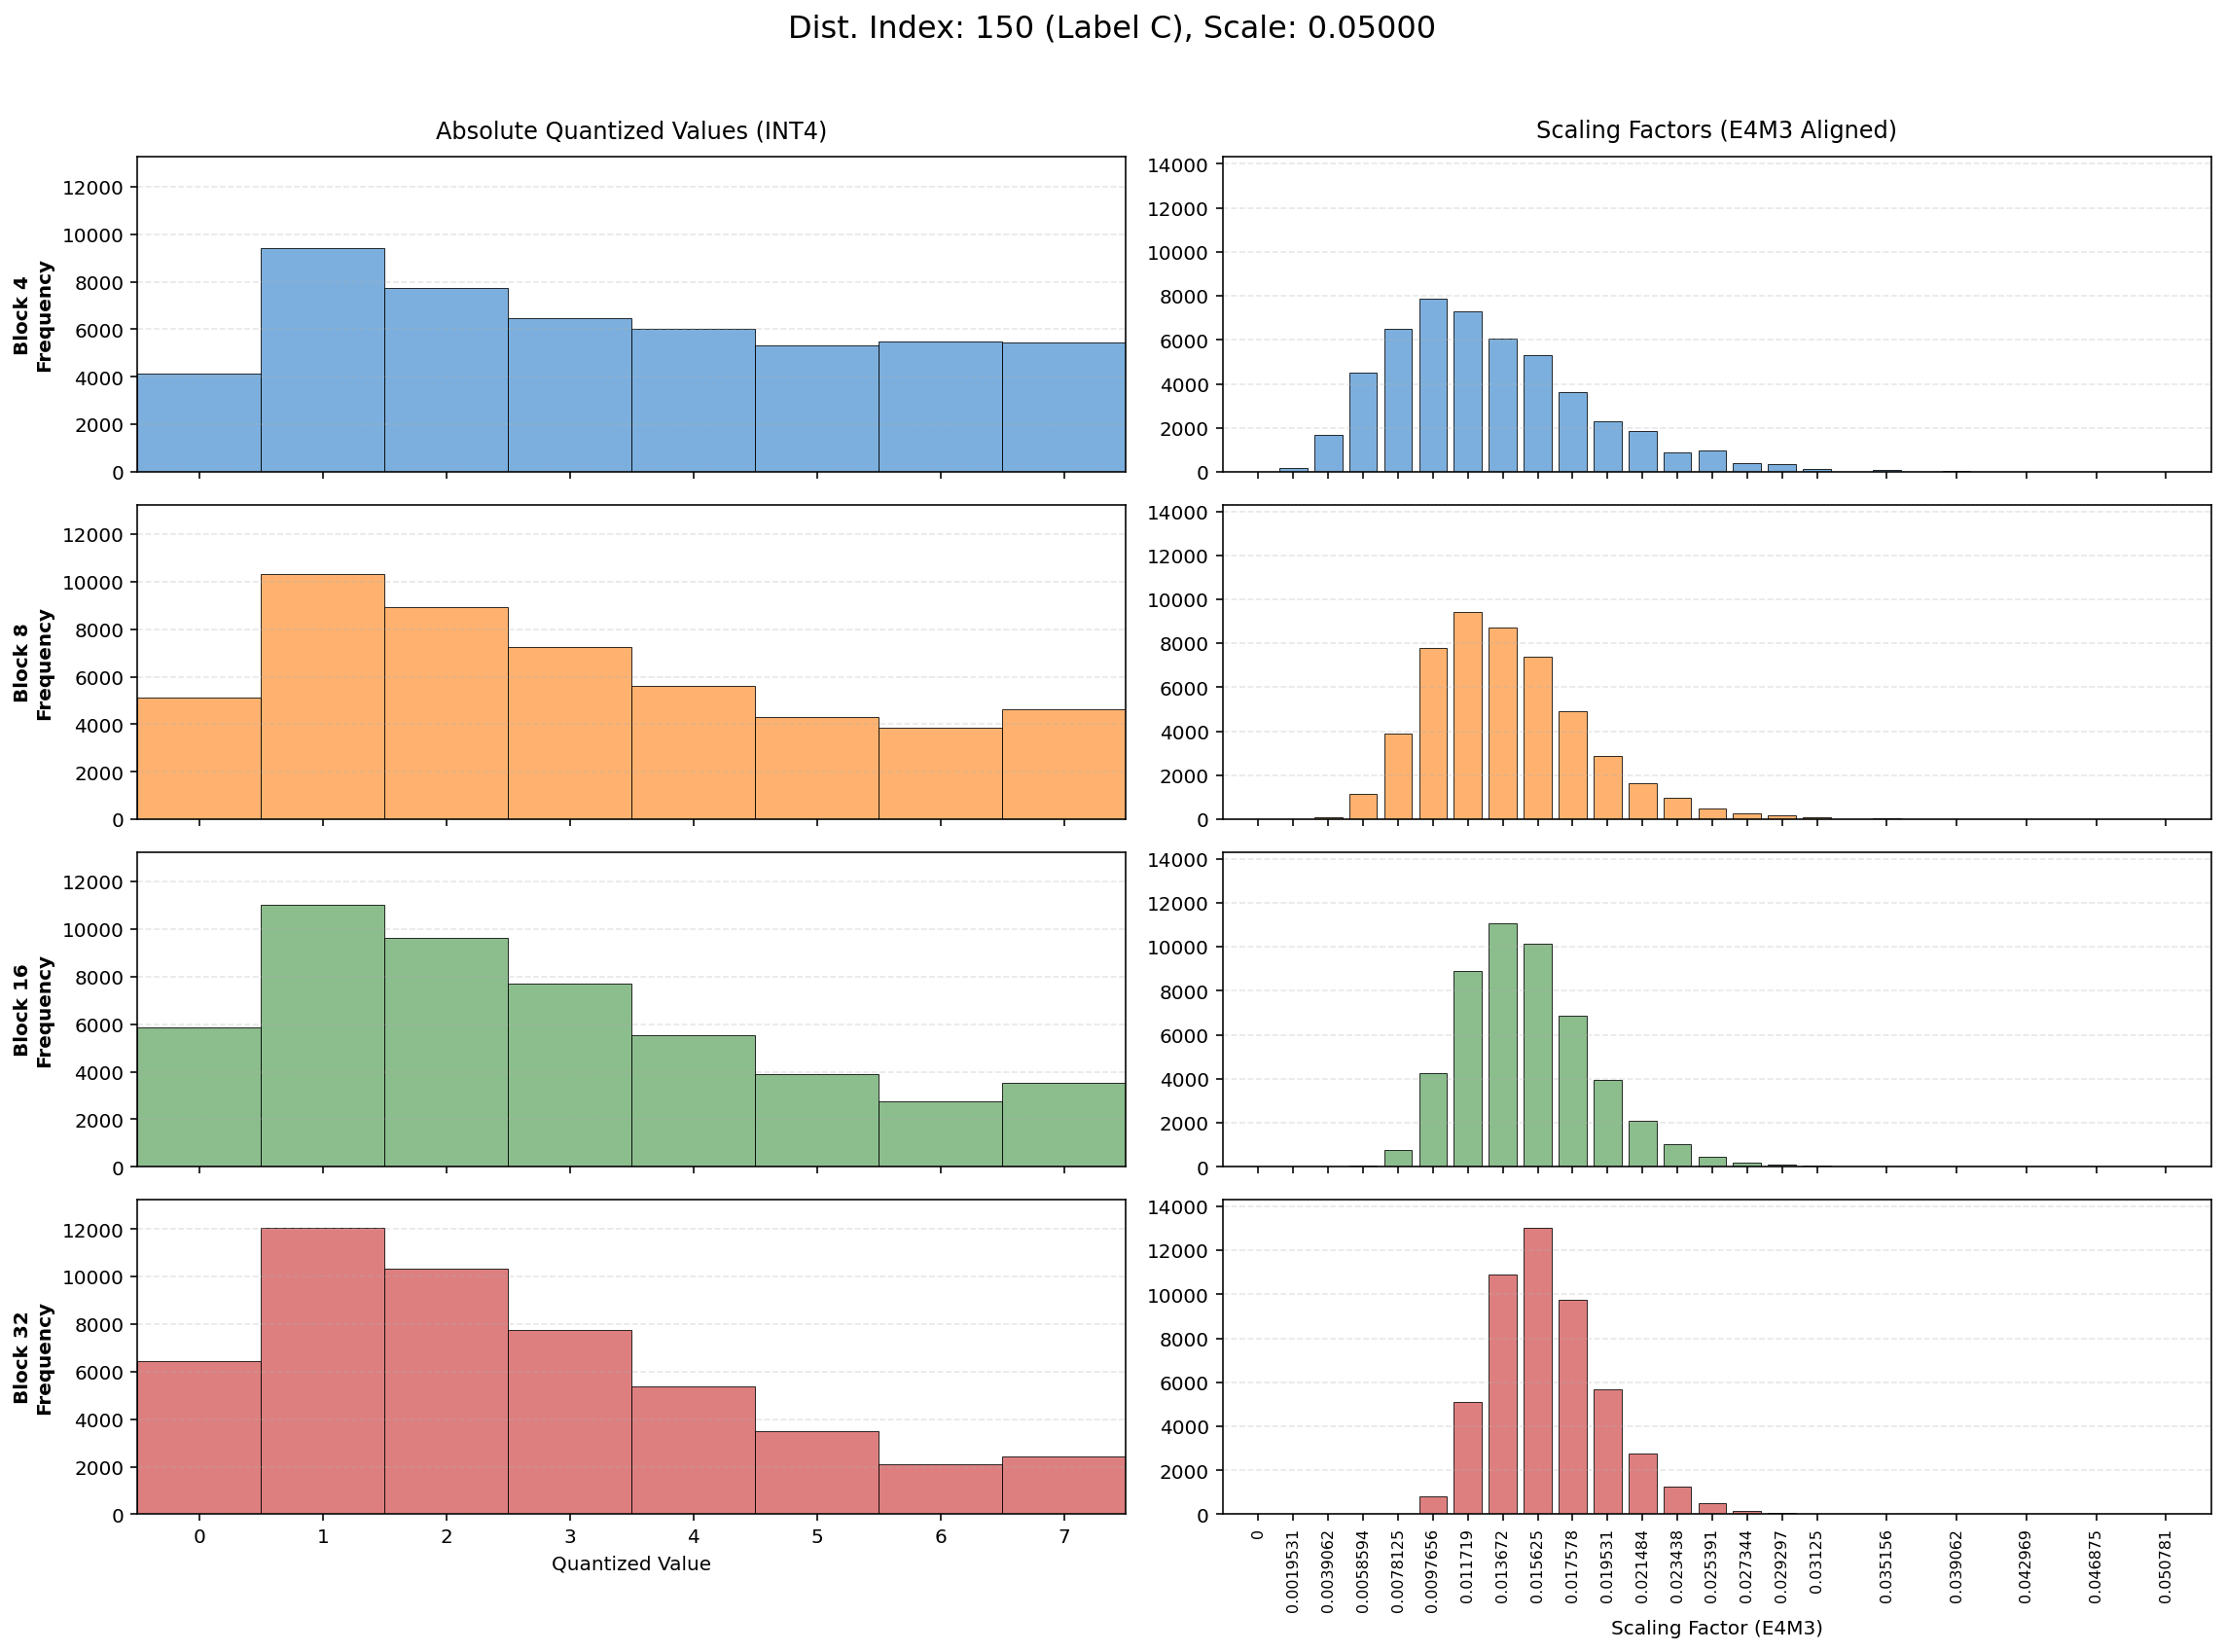

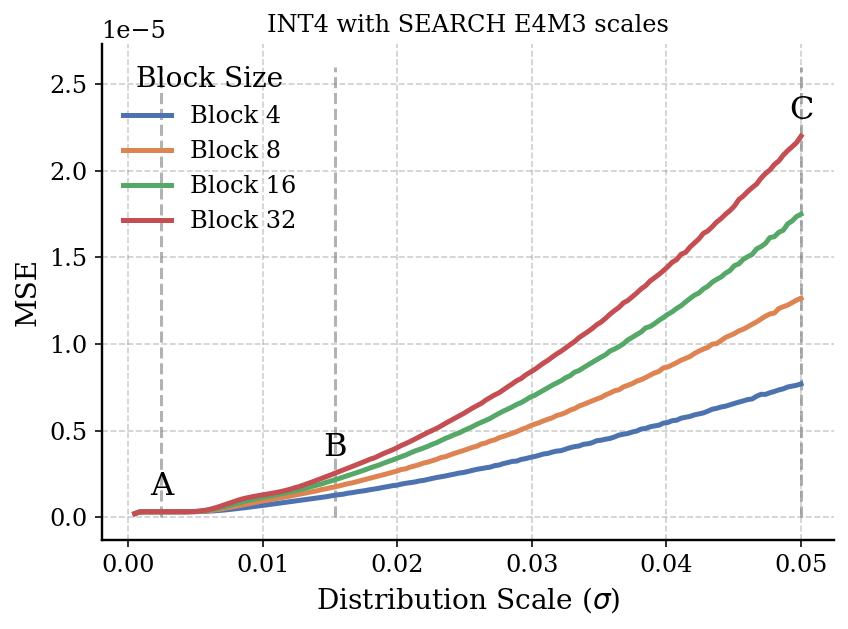

In [14]:
df_int4_search = run_error_experiment(lambda x: search_quant(x, quant_type='int4'), quant_type='int4', title="INT4 with SEARCH E4M3 scales")

# Outputs as tables

In [15]:
frames = {
    "Absmax": df_fp4_absmax.loc[plot_indices],
    "Nonzero Absmax": df_fp4_nonzero_absmax.loc[plot_indices],
    "Search": df_fp4_search.loc[plot_indices],
    "4/6": df_fp4_4_over_6.loc[plot_indices],
    "Nonzero 4/6": df_fp4_nonzero_4_over_6.loc[plot_indices],
}

index_map = {6: "A", 45: "B", 150: "C"}
frames_renamed = {
    name: df.rename(index=index_map) for name, df in frames.items()
}
baseline = frames_renamed["Search"]
normalized_frames = {name: df / baseline for name, df in frames_renamed.items()}
df_normalized = pd.concat(normalized_frames).swaplevel(0, 1).sort_index()
display(df_normalized.style.format("{:.2f}"))

In [16]:
frames = {
    "Absmax": df_int4_absmax.loc[plot_indices],
    "Nonzero Absmax": df_int4_nonzero_absmax.loc[plot_indices],
    "Search": df_int4_search.loc[plot_indices],
}

index_map = {6: "A", 45: "B", 150: "C"}
frames_renamed = {
    name: df.rename(index=index_map) for name, df in frames.items()
}
baseline = frames_renamed["Search"]
normalized_frames = {name: df / baseline for name, df in frames_renamed.items()}
df_normalized = pd.concat(normalized_frames).swaplevel(0, 1).sort_index()
display(df_normalized.style.format("{:.2f}"))